In [1]:
import pandas as pd
import numpy as np

import shap

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns
import os
import joblib
import math
from datetime import date
from tqdm import tqdm
from collections import Counter
import psutil
import shutilt
import gc
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import silhouette_score, davies_bouldin_score
from lightgbm import LGBMRanker, early_stopping, log_evaluation
from catboost import CatBoostRanker, Pool
from xgboost import XGBRanker
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
tqdm.pandas()

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)

<!--
<h1 style="color: #4682B4;">CONSTANTS</h1>
<h1 style="color: #8FBC8F;">CONSTANTS</h1>
-->
<!--
<h1 style="color: #2D5A27; font-size: 2.6em; font-weight: 800; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; letter-spacing: 1.5px; border-bottom: 3px solid #2D5A27; padding-bottom: 8px;">CONSTANTS AND FLAGS</h1>

<h1 style="color: #2D5A27; font-size: 2.3em; font-weight: 700; text-transform: uppercase; letter-spacing: 1px; border-left: 6px solid #2D5A27; padding-left: 15px;">CONSTANTS AND FLAGS</h1>

<h1 style="color: #2D5A27; font-size: 2.5em; font-weight: bold; background-color: #F0F7F4; padding: 15px 20px; border-left: 8px solid #2D5A27; border-radius: 0 6px 6px 0;">CONSTANTS AND FLAGS</h1>

<div style="background-color: #f8f9fa; border-left: 5px solid #2D5A27; padding: 15px; margin-bottom: 20px;">
    <h1 style="color: #2D5A27; font-size: 32px; margin: 0; font-family: sans-serif; letter-spacing: 1px; text-transform: uppercase;">
        Constants and Flags
    </h1>
    <p style="color: #999; font-size: 14px; margin: 5px 0 0 0;">Configuration & Global Parameters</p>
</div>
-->
<!--
<h1 style="color: #10B981;">CONSTANTS</h1>
<h1 style="color: #8A2BE2;">CONSTANTS</h1>
<h1 style="color: #212529;">CONSTANTS</h1>
<h1 style="color: #1C1A27;">CONSTANTS</h1>
<h1 style="color: #2A2421;">CONSTANTS</h1>
<h1 style="color: #0B192C;">CONSTANTS</h1>
<h1 style="color: #00D2C4;">CONSTANTS</h1>
<h1 style="color: #008080;">CONSTANTS</h1>
<h1 style="color: #FFDE21;">CONSTANTS</h1>
<h1 style="color: #F9CC5C;">CONSTANTS</h1>
<h1 style="color: #FDDA0D;">CONSTANTS</h1>
-->

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
    Constants and Flags
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Configuration & Global Parameters
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Opcija 1: Kratak i efektan opis (Idealan za LinkedIn, CV ili rezime projekta)
        Insurance Policy Recommender is an AI-powered assistant designed for insurance brokers to help them deliver highly personalized and meaningful policy recommendations to their clients. By analyzing client data and risk profiles, it streamlines the decision-making process, ensuring optimal coverage and enhanced client satisfaction.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Opcija 2: Profesionalni/Biznis opis (Idealan za prezentacije ili sajt)
        Insurance Policy Recommender is an intelligent AI assistant tailored for insurance brokers. It empowers brokers to provide data-driven, meaningful, and highly accurate policy recommendations to their clients. By leveraging advanced AI algorithms, the assistant evaluates client needs, compares complex policy options, and helps brokers deliver tailored insurance solutions that maximize value and trust.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Opcija 3: Tehnički/Funkcionalni opis (Idealan za GitHub ili tehničku dokumentaciju)
        Insurance Policy Recommender is an AI-driven decision-support tool built for insurance brokers. The system processes client profiles, historical data, and specific requirements to recommend the most suitable insurance policies. Its primary goal is to assist brokers in making meaningful, well-informed recommendations, reducing manual research time, and optimizing the coverage-to-risk ratio for clients.
    </p>
    <p>Ključni termini koji su korišćeni (za tvoju referencu):</p>
    <ul>
        <li> AI-powered / AI-driven assistant – AI asistent / vođen veštačkom inteligencijom</li>
        <li>Insurance brokers – Brokeri u oblasti osiguranja</li>
        <li>Meaningful recommendations – Smislene preporuke</li>
        <li>Tailored / Personalized solutions – Prilagođena / personalizovana rešenja</li>
        <li>Risk profiles / Client needs – Profili rizika / potrebe klijenata</li>
    </ul>
</div>

In [3]:
# ============================================================
# KONSTANTE — Apriori flagovi
# ============================================================
# ============================================================
# KONSTANTE — Apriori flagovi
# ============================================================
_TRAIN_MODEL = True
 
USE_APRIORI_AS_FEATURE      = True
BLEND_APRIORI               = False   # ← PROMIJENJENO: bio False
BLEND_MARKOV_PROBS          = False
INCLUDE_SEGMENT_MARKOV      = False
USE_MARKOV_PROBS_AS_FEATURE = True
INCLUDE_CLIENT_CLUSTERS     = False
INCLUDE_RENEWAL_FEATURES    = True
INCLUDE_SEASONAL_FEATURES   = True
INCLUDE_POPULARITY_FEATURES = True
INCLUDE_EMBEDDING_MAP = True
DO_NEGATIVE_SAMPLING        = False
USE_CATBOOST                = False
 
HR1_WEIGHT   = 0.0
HR3_WEIGHT   = 0.4
HR5_WEIGHT   = 0.0
MRR3_WEIGHT  = 0.0
MRR5_WEIGHT  = 0.0
NDCG3_WEIGHT = 0.6
NDCG5_WEIGHT = 0.0
 
OPTUNA_NTRIALS = 22
 
APRIORI_MIN_SUPP       = 0.01
APRIORI_MIN_CONFIDENCE = 0.1
 
NUM_KMEANS_CLUSTERS = 7
 
# Početne težine — Optuna će ih optimizovati
W_LGBM    = 0.5   # ← malo smanjeno da ostavi prostora za apriori
W_XGBM    = 0.5
W_CAT     = 0.0
W_MARKOV  = 0.0
W_APRIORI = 0.0   # ← PROMIJENJENO: bio 0.0
 
# RRF smoothing parametar — standardno 60, ali Optuna može tunirati
W_RRF_K   = 60

EMB_COMPONENTS = 8  # konstanta na vrhu notebooka
 
assert not (USE_APRIORI_AS_FEATURE and BLEND_APRIORI), \
    "Odaberi jedan mod: USE_APRIORI_AS_FEATURE ili BLEND_APRIORI, ne oba."
 
assert abs(HR3_WEIGHT + MRR5_WEIGHT + NDCG3_WEIGHT - 1.0) < 1e-9, \
    f"Weightovi moraju zbrajati na 1.0, trenutno: {HR3_WEIGHT + MRR5_WEIGHT + NDCG3_WEIGHT}"

assert not (USE_MARKOV_PROBS_AS_FEATURE and BLEND_MARKOV_PROBS), \
    "Markov ne može biti i feature i blend signal istovremeno."

assert not (INCLUDE_SEGMENT_MARKOV and BLEND_MARKOV_PROBS), \
    "Segment Markov kao feature i BLEND_MARKOV_PROBS su redundantni."
 

In [4]:
# Provjera konzistentnosti flagova
assert not (USE_APRIORI_AS_FEATURE and BLEND_APRIORI), \
    "Odaberi jedan mod: USE_APRIORI_AS_FEATURE ili BLEND_APRIORI, ne oba."

assert abs(HR3_WEIGHT + MRR5_WEIGHT + NDCG3_WEIGHT - 1.0) < 1e-9, \
    f"HR3_WEIGHT + MRR5_WEIGHT + NDCG3_WEIGHT mora biti 1.0, trenutno: {HR3_WEIGHT + MRR5_WEIGHT + NDCG3_WEIGHT}"

assert 0.0 <= HR3_WEIGHT <= 1.0 and 0.0 <= NDCG3_WEIGHT <= 1.0 and 0.0 <= MRR5_WEIGHT <= 1.0, \
    "Weightovi moraju biti između 0 i 1."

print("✅ Konstante validne:")
print(f"   USE_APRIORI_AS_FEATURE = {USE_APRIORI_AS_FEATURE}")
print(f"   BLEND_APRIORI          = {BLEND_APRIORI}")
print(f"   BLEND_MARKOV_PROBS     = {BLEND_MARKOV_PROBS}")
print(f"   INCLUDE_SEGMENT_MARKOV = {INCLUDE_SEGMENT_MARKOV}")
print(f"   USE_MARKOV_PROBS_AS_FEATURE   = {USE_MARKOV_PROBS_AS_FEATURE}")
print(f"   INCLUDE_CLIENT_CLUSTERS= {INCLUDE_CLIENT_CLUSTERS}")
print(f"   INCLUDE_RENEWAL_FEATURES= {INCLUDE_RENEWAL_FEATURES}")
print(f"   INCLUDE_SEASONAL_FEATURES= {INCLUDE_SEASONAL_FEATURES}")
print(f"   INCLUDE_POPULARITY_FEATURES= {INCLUDE_POPULARITY_FEATURES}")
print(f"   DO_NEGATIVE_SAMPLING= {DO_NEGATIVE_SAMPLING}")
print(f"   Optuna loss: {HR3_WEIGHT}×HR@3 + {MRR5_WEIGHT}×MRR@5")
print(f"   EMB_COMPONENTS= {EMB_COMPONENTS}")


print(f"   MODEL PARTICIPATION:\t W_LGBM: {W_LGBM}, W_XGBM {W_XGBM}, W_CAT {W_CAT}, W_MARKOV {W_MARKOV}, W_APRIORI {W_APRIORI}")

print("\n" + "=" * 80)
if _TRAIN_MODEL:
    print("MODUS: TRENIRANJE MODELA (od početka)")
else:
    print("MODUS: UČITAVANJE PRE-TRENIRANIH MODELA (preskakanje treniranja)")
print("=" * 80)

✅ Konstante validne:
   USE_APRIORI_AS_FEATURE = True
   BLEND_APRIORI          = False
   BLEND_MARKOV_PROBS     = False
   INCLUDE_SEGMENT_MARKOV = False
   USE_MARKOV_PROBS_AS_FEATURE   = True
   INCLUDE_CLIENT_CLUSTERS= False
   INCLUDE_RENEWAL_FEATURES= True
   INCLUDE_SEASONAL_FEATURES= True
   INCLUDE_POPULARITY_FEATURES= True
   DO_NEGATIVE_SAMPLING= False
   Optuna loss: 0.4×HR@3 + 0.0×MRR@5
   EMB_COMPONENTS= 8
   MODEL PARTICIPATION:	 W_LGBM: 0.5, W_XGBM 0.5, W_CAT 0.0, W_MARKOV 0.0, W_APRIORI 0.0

MODUS: TRENIRANJE MODELA (od početka)


<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Loading training data
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Insurance policy data
    </p>
</div>

In [5]:
# # ============================================================
# # UCITAVANJE PODATAKA
# # ============================================================

# policy_data = pd.read_csv('../../data/data_from_db_as_csv/new_polisa_202603141519.csv', dtype={
#     'ponuda_id': 'Int32', 'ugo_jmbg': str
# })
# ins_cli_data = pd.read_csv('../../data/data_from_db_as_csv/__ins_klijenti__202603141320.csv', dtype={
#     'mat_br': str, 'klijent_id': 'Int32'
# })
# np_cli_data = pd.read_csv('../../data/data_from_db_as_csv/new_polisa_klijent_202603141515.csv', dtype={
#     'osig_jmbg': str, 'klijent_id': 'Int32', 'ponuda_id': 'Int32'
# })
# cli_roles = pd.read_csv('../../data/data_from_db_as_csv/new_polisa_uloga_202603172039.csv')

In [6]:
# ============================================================
# UCITAVANJE PODATAKA
# ============================================================

policy_data = pd.read_csv('../../data/new_polisa_202606051446.csv', dtype={
    'ponuda_id': 'Int32', 'ugo_jmbg': str
})

ins_cli_data = pd.read_csv('../../data/__ins_klijenti__202606051502.csv', dtype={
    'mat_br': str, 'klijent_id': 'Int32'
})

np_cli_data = pd.read_csv('../../data/new_polisa_klijent_202606051445.csv', dtype={
    'osig_jmbg': str, 'klijent_id': 'Int32', 'ponuda_id': 'Int32'
})

cli_roles = pd.read_csv('../../data/new_polisa_uloga_202606051502.csv')

policy_types = pd.read_csv('../../data/tsif_vrsta_202606051502.csv')

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_24144\4263070138.py:5: DtypeWarning: Columns (61,65,80,82) have mixed types. Specify dtype option on import or set low_memory=False.
  policy_data = pd.read_csv('../../data/new_polisa_202606051446.csv', dtype={
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_24144\4263070138.py:9: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  ins_cli_data = pd.read_csv('../../data/__ins_klijenti__202606051502.csv', dtype={
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_24144\4263070138.py:13: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  np_cli_data = pd.read_csv('../../data/new_polisa_klijent_202606051445.csv', dtype={


<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Debugging Functions
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <ul>
        <li>Calculate RAM memory usage</li>
        <li>Print duplicate columns</li>
        <li>Showing policy client distribution (Does client have one policy or more)</li>
    </ul>
</div>

In [7]:
# ============================================================
# POMOCNE FUNKCIJE
# ============================================================
process = psutil.Process(os.getpid())

def get_ram_mb():
    return process.memory_info().rss / 1024 / 1024

def print_duplicates(df, subset):
    print(f"\n### DUPLICATES: {subset} ###")

    # Po defaultu je keep='first'
    print(f"Dupliranih redova: {df.duplicated(subset=subset, keep='first').sum()}")
    print(f"Jedinstvenih duplikata: {df.groupby(subset).size().gt(1).sum()}")
    print(f"Ukupno redova u dupliranim grupama: {df.duplicated(subset=subset, keep=False).sum()}")

def show_cli_policy_distribution(df):
    
    sns.set_style("darkgrid")
    
    policy_counts = df.groupby('klijent_id').size()
    
    data = {"Only 1 policy": (policy_counts == 1).sum(),
            "More than 1 policy": (policy_counts > 1).sum()}
    
    plot_df = pd.DataFrame({"category": list(data.keys()), "value": list(data.values())})
    
    plt.figure(figsize=(8, 6))
    
    ax = sns.barplot(data=plot_df, x="category", y="value", hue="category",
                     palette=["#4C78A8", "#F58518"], legend=False)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11)
        
    plt.title("Distribution of Clients by Number of Policies", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Cleaning Data
</h2>

<h2 style="color: #008080;">Realise date manipulation</h2>

In [8]:
# ============================================================
# CISCENJE POLICY DATA
# ============================================================
policy_data = policy_data[(policy_data['polisa_id'].notna() & policy_data['polisa_id'] != 0)]
policy_data = policy_data.drop_duplicates('polisa_id', keep='first')
policy_data['dat_izdavanja'] = pd.to_datetime(policy_data['dat_izdavanja'])
policy_data['godina']    = policy_data['dat_izdavanja'].dt.year
policy_data['days_old']  = (pd.Timestamp.today() - policy_data['dat_izdavanja']).dt.days
policy_data['years_old'] = policy_data['days_old'] / 365.25

<h2 style="color: #008080;">Collecting as much information as possible for each client</h2>

In [9]:
# ============================================================
# KLIJENTI
# ============================================================
def gather_cli_info_fastest(df):
    df = df.sort_values('klijent_id')
    df_filled = df.groupby('klijent_id').transform('bfill')
    df_filled['klijent_id'] = df['klijent_id'].values
    return df_filled.drop_duplicates('klijent_id', keep='first')

<h2 style="color: #008080;">Extracting serial number, clearing data and feature engineering</h2>

In [10]:
def extract_serial_num_data(serial_number):
    
    if pd.isna(serial_number) or serial_number == '' or len(serial_number) != 13:
        return np.nan, np.nan, np.nan
        
    sn = str(serial_number).zfill(13)
    year = int(sn[4:7])
    year = year + 2000 if year < 800 else 1000 + year
    age = date.today().year - year
    birth_place = sn[7:9]
    gender = 1 if int(sn[9:12]) < 500 else 0
    return age, birth_place, gender

def clear_data(df):
    
    df = df.copy()

    # stranac
    df['is_foreign'] = df['br_pasosa_y'].apply(lambda x: 1 if pd.notna(x) and x != '' else 0)
    df['ind_rezident'] = df['ind_rezident'].apply(lambda x: 1 if x == 'D' else 0)
    df['ind_stranac']  = df['ind_stranac'].apply(lambda x: 1 if x == 'D' else 0)
    df['is_foreign'] = df['is_foreign'].fillna(df['ind_rezident']).fillna(df['ind_stranac'])
    
    df.drop(['ind_rezident', 'ind_stranac', 'drzava_id_x', 'drzava_id_y',
             'br_pasosa_x', 'br_pasosa_y'], axis=1, inplace=True)

    # svojina
    df['ownerType'] = df['sif_svojina'].fillna(df['osig_svojina'])
    df.loc[df['ownerType'] == 2, 'ownerType'] = 0
    
    df.drop(['sif_svojina', 'osig_svojina'], axis=1, inplace=True)
    df[['age', 'birth_place', 'gender']] = (
        df.loc[(df['ownerType'] == 1) & (df['is_foreign'] == 0), 'mat_br']
        .apply(extract_serial_num_data).apply(pd.Series)
    )

    # godine
    df['datum_rodjenja'] = pd.to_datetime(
        df['datum_rodjenja_x'].fillna(df['datum_rodjenja_y']), errors='coerce'
    )
    df['years'] = date.today().year - df['datum_rodjenja'].dt.year
    df['age']   = df['age'].fillna(df['years'])
    
    df.drop(['datum_rodjenja_x', 'datum_rodjenja_y', 'datum_rodjenja', 'years'], axis=1, inplace=True)

    # pol
    df.loc[df['pol_id_x'] == 2, 'pol_id_x'] = 0
    df.loc[df['pol_id_y'] == 2, 'pol_id_y'] = 0
    df['gender'] = df['gender'].fillna(df['pol_id_x']).fillna(df['pol_id_y'])
    
    df.drop(['pol_id_x', 'pol_id_y'], axis=1, inplace=True)

    # bracni status
    df['merrige_status'] = df['sif_bracni_status_x'].fillna(df['sif_bracni_status_y'])
    df.loc[df['merrige_status'] == 2, 'merrige_status'] = 0
    
    df.drop(['sif_bracni_status_x', 'sif_bracni_status_y'], axis=1, inplace=True)

    # posao
    df['unknown_job'] = df['nedef_delatnost_y'].fillna(df['nedef_delatnost_x'])
    
    df.drop(['nedef_delatnost_y', 'nedef_delatnost_x'], axis=1, inplace=True)
    
    df['job_type'] = df['sif_delatnost_y'].fillna(df['sif_delatnost_x'])
    
    df.drop(['sif_delatnost_y', 'sif_delatnost_x'], axis=1, inplace=True)

    # Vozacka dozvola
    df['driving_licence_date'] = df['dat_vozacke_y'].fillna(df['dat_vozacke_x'])
    df.drop(['dat_vozacke_y', 'dat_vozacke_x'], axis=1, inplace=True)
    
    text_cols = [
        'mat_br', 'naziv', 'naziv1', 'king_id_x', 'mesto_rodj_x', 'osig_jmbg', 'osig_naziv',
        'osig_naziv1', 'osig_ulica', 'osig_mesto', 'osig_telefon2', 'ind_info_ponuda',
        'king_id_y', 'osig_telefon1', 'osig_mail', 'mesto_rodj_y', 'procenat', 'sif_mj'
    ]
    
    df.drop([c for c in text_cols if c in df.columns], axis=1, inplace=True)
    return df

def feature_engineering(df):
    
    df = df.copy()

    # Grupe po godinama
    df['age_bucket'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 65, 100], labels=[0, 1, 2, 3, 4])

    # Koliko dugo vozi + popunjavanje praznih redova
    df['driving_licence_date'] = pd.to_datetime(df['driving_licence_date'], errors='coerce')
    today_year = pd.Timestamp.today().year
    
    df['driving_experience'] = (today_year - df['driving_licence_date'].dt.year).astype(float)
    
    df['driving_experience'] = (
        df['driving_experience']
        .fillna(df.groupby('age_bucket', observed=True)['driving_experience'].transform('median'))
        .fillna(df['driving_experience'].median())
    )

    # Bracni status popunjavanje praznih redova
    df['merrige_status'] = df['merrige_status'].astype(float)
    df['merrige_status'] = (
        df['merrige_status']
        .fillna(df.groupby('age_bucket', observed=True)['merrige_status'].transform('median'))
        .fillna(df['merrige_status'].median())
    )
    
    df = df.drop('driving_licence_date', axis=1)
    return df

<h2 style="color: #008080;">Function for ploting column fill rate</h2>

In [11]:
# Procentualna popunjenost izabranih kolona
def plot_column_fill_rate(df, cols):

    # notna vraca masku True/False sto je u pythonu 1 i 0
    # Pa u sustini kod radi zbir 1 / zbir koliko ima redova odnosno redova ukupno
    fill_rate = df[cols].notna().mean() * 100

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        x=fill_rate.values,
        y=fill_rate.index
    )

    ax.set_xlabel('Popunjenost (%)')
    ax.set_ylabel('Kolona')
    ax.set_title('Procenat popunjenosti kolona')

    plt.tight_layout()
    plt.show()

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Applying all of theabove
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Merging client-related datasets.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Gathering and consolidating available client information.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Cleaning and validating client data.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Removing duplicate records.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Visualizing column fill rates to assess data completeness.
    </p>
</div>

Ukupno kolona:  16


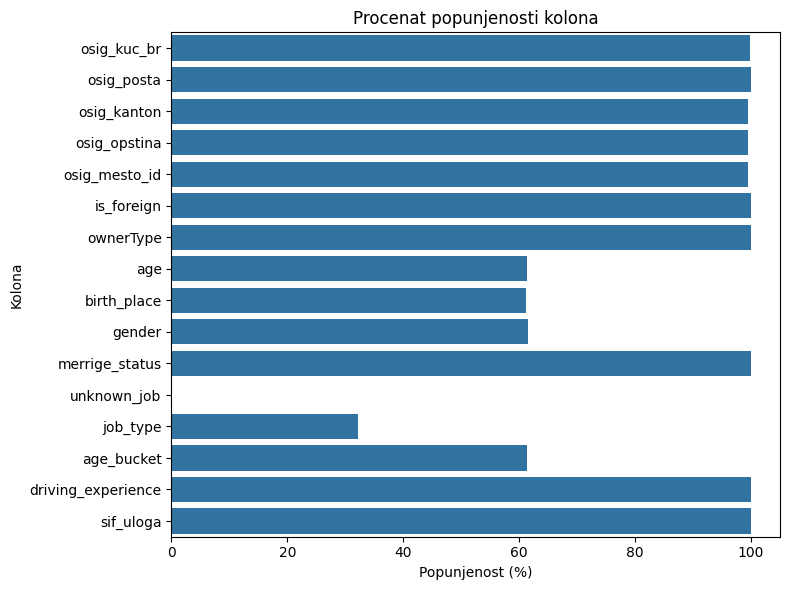

In [12]:
# ============================================================
# KLIJENTI PROCESUIRANJE
# ============================================================
cli_data = ins_cli_data.merge(np_cli_data, on="klijent_id", how="inner")
cli_data = gather_cli_info_fastest(cli_data)
cli_data = clear_data(cli_data)

corrupted_ids = cli_data[(cli_data['age'] < 18) | (cli_data['age'] > 90)]['klijent_id'].values

cli_data.loc[cli_data['klijent_id'].isin(corrupted_ids), 'age'] = \
    cli_data.groupby(['merrige_status', 'osig_opstina'])['age'].transform('median')

cli_data = feature_engineering(cli_data)

cli_data = cli_data.merge(
    np_cli_data[['klijent_id', 'ponuda_id', 'sif_uloga']], on='klijent_id', how='inner'
)

cli_data['ponuda_id'] = cli_data['ponuda_id_y']
cli_data['sif_uloga'] = cli_data['sif_uloga_y']
cli_data = cli_data.drop(['ponuda_id_y', 'ponuda_id_x', 'sif_uloga_y', 'sif_uloga_x'], axis=1)

cli_duplicates = cli_data[cli_data.duplicated(['klijent_id', 'ponuda_id', 'sif_uloga'])].shape[0]

if cli_duplicates > 0:
    cli_data = cli_data.drop_duplicates(['klijent_id', 'ponuda_id', 'sif_uloga'], keep='first')

columns_to_check = [
    c for c in cli_data.columns
    if c not in ['ponuda_id', 'redni_br', 'klijent_id']
]
print("Ukupno kolona: ", len(columns_to_check))
plot_column_fill_rate(cli_data, columns_to_check)

<h2 style="color: #008080; margin: 1em;">Based on the fill-rate analysis, some features contain too many missing values to be useful and will be removed.</h2>

In [13]:
cli_data = cli_data.drop(['unknown_job', 'job_type'], axis=1)

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Merging policy and client datasets.
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Filtering client roles to retain only policyholders (Ugovarač).
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Creating a policyholder-level dataset for further analysis.
    </p>
</div>

In [14]:
policy_client_data = policy_data.merge(cli_data, on='ponuda_id', how='inner')

cli_roles = cli_roles[cli_roles['opis'].str.contains('Ugovarač', na=False)]

policy_client_data = policy_client_data[
    policy_client_data['sif_uloga'].isin(cli_roles['sif_uloga'].values)
]

<h2 style="color: #008080;">Removing duplicate information stored across multiple columns</h2>

In [15]:
def clean_policy_client_data(df):
    
    cols_to_delete = [
        'sif_preuzmi', 'preuzmi_no', 'preuzmi_id', 'ugo_jmbg', 'ugo_svojina', 'ugo_naziv',
        'ugo_naziv1', 'ugo_ulica', 'ugo_kuc_br', 'ugo_mesto', 'ugo_posta', 'ugo_kanton',
        'ugo_opstina', 'ugo_mesto_id', 'ugo_telefon1', 'ugo_telefon2', 'ugo_mail',
        'osig_jmbg', 'osig_svojina', 'osig_naziv', 'osig_naziv1', 'osig_ulica',
        'osig_kuc_br_x', 'osig_mesto', 'osig_posta_x', 'osig_kanton_x', 'osig_opstina_x',
        'osig_mesto_id_x', 'osig_telefon1', 'osig_telefon2', 'osig_mail', 'mesto_izdavanja',
        'miro_polisa_no', 'sif_ikanton', 'sif_iopstina', 'ugo_del', 'king_id',
        'ugo_br_pasosa', 'osig_br_pasosa', 'registarski_broj_polise', 'akcija_id'
    ]
    return df.drop([c for c in cols_to_delete if c in df.columns], axis=1)

In [16]:
policy_client_data = clean_policy_client_data(policy_client_data)

print(policy_client_data.columns)

Index(['ponuda_id', 'polisa_id', 'sif_vrsta', 'polisa_no', 'broker_id',
       'sif_org_jed', 'zamena_polise_no', 'ind_zamena', 'sif_trajanja',
       'dat_od_ug', 'dat_do_ug', 'dat_od', 'dat_do', 'time_od', 'time_do',
       'br_dana', 'dat_izdavanja', 'mjesto_izdavanja', 'napomena',
       'napomena_auto', 'napomena1', 'p_oper', 'p_date', 'p_session_id',
       'sif_nac_plac', 'br_rata', 'dat_prve_rate', 'sif_napomena',
       'premija_ukupno', 'opis_osiguravac', 'ind_user_skadenca', 'ind_obracun',
       'suma_osiguranja', 'polisa_tarifa', 'veza_polise_no',
       'ind_lock_skadenca', 'uw_indikator', 'ind_uw_kontrola', 'ugo_isprava',
       'osig_isprava', 'sif_datum_dospeca', 'sif_bankovni_racun',
       'konacna_premija', 'ind_nepravilni_otp_plan', 'ind_dug', 'ind_steta',
       'godina', 'days_old', 'years_old', 'redni_br', 'osig_kuc_br_y',
       'osig_posta_y', 'osig_kanton_y', 'osig_opstina_y', 'osig_mesto_id_y',
       'klijent_id', 'is_foreign', 'ownerType', 'age', 'birth_pl

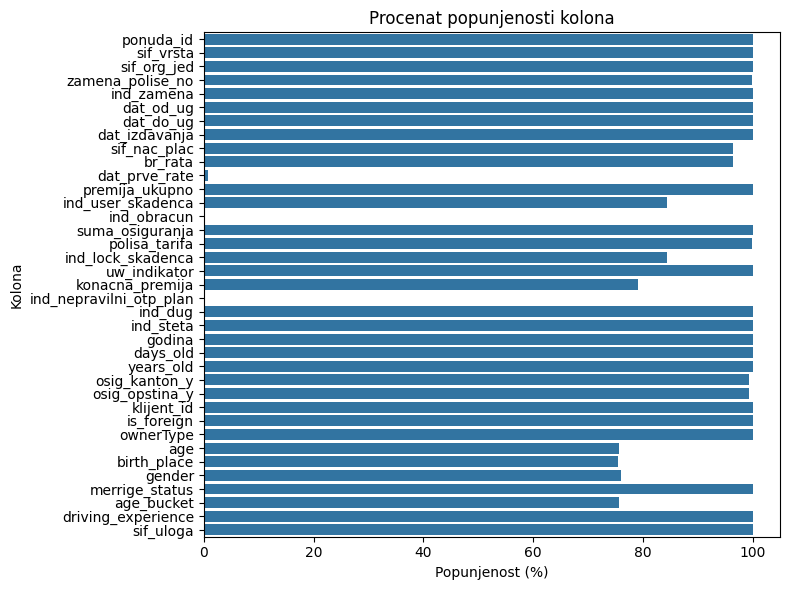

In [17]:
def clean_policy_client_data_2(df):
    cols_to_delete = [
        'polisa_id', 'polisa_no', 'broker_id', 'sif_trajanja',
        # 'dat_od_ug', 'dat_do_ug', 
       'dat_od', 'dat_do', 'time_od', 'time_do',
       'br_dana', 'mjesto_izdavanja', 'napomena',
       'napomena_auto', 'napomena1', 'p_oper', 'p_date', 'p_session_id',  'sif_napomena', 'opis_osiguravac', 
        'veza_polise_no', 'ind_uw_kontrola', 'ugo_isprava',
       'osig_isprava', 'sif_datum_dospeca', 'sif_bankovni_racun', 'redni_br', 'osig_kuc_br_y',
       'osig_posta_y', 
        #'osig_kanton_y', 'osig_opstina_y', 
        'osig_mesto_id_y',
    ]
    
    return df.drop([c for c in cols_to_delete if c in df.columns], axis=1)

policy_client_data = clean_policy_client_data_2(policy_client_data)

cols_to_check = [c for c in policy_client_data.columns if c not in ['ponuda_id', 'klijent_id']]
plot_column_fill_rate(policy_client_data, policy_client_data.columns)

In [18]:
policy_client_data = policy_client_data.drop(['dat_prve_rate', 'ind_obracun', 'ind_nepravilni_otp_plan'], axis = 1)

<h2 style="color: #008080;">Additional feature engineering to get some extra potentionaly usefull features</h2>

In [19]:
def process_ussable_data(df):
    df = df.copy()

    zpn = (
        df['zamena_polise_no']
        .notna()
        & (df['zamena_polise_no'] != 0)
    ).astype(int)
    
    binary_mapper = {
        'D': 1,
        'N': 0
    }
    
    df['has_prev_policy'] = (
        df['ind_zamena']
        .map(binary_mapper)
        .fillna(zpn)
        .astype(int)
        )
    
    df = df.drop(['ind_zamena', 'zamena_polise_no'], axis = 1)
    
    df['ind_user_skadenca'] = (
        df['ind_user_skadenca']
        .map(binary_mapper)
        .fillna(0)
        .astype(int)
        )
    
    df = df.drop(['polisa_tarifa', 'ind_lock_skadenca'], axis = 1)
    
    df['uw_indikator'] = (
        df['uw_indikator']
        .map(binary_mapper)
        .fillna(0)
        .astype(int)
        )
    
    df['ind_dug'] = (
        df['ind_dug']
        .map(binary_mapper)
        .fillna(0)
        .astype(int)
        )
    
    df['ind_steta'] = (
        df['ind_steta']
        .map(binary_mapper)
        .fillna(0)
        .astype(int)
        )
    
    return df

policy_client_data = process_ussable_data(policy_client_data)

<h3 style="color: #212529;">Manual garbige collection, maybe unnecessery</h3>

In [20]:
# ============================================================
# Ciscenje RAM-a
# ============================================================

ins_cli_data = None
np_cli_data  = None
cli_roles    = None
cli_data     = None
gc.collect()

314

<h2 style="color: #2D5A27; font-size: 28px; font-weight: 800; font-family: sans-serif; letter-spacing: 0.6px; margin-bottom: 1em;">
    Data to Signal: Advanced Features
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #1F4E3A; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        moving into advanced feature engineering.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        This stage includes Markov-based features, a priori probabilities, and other statistically derived signals.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        These features will be introduced and explained step by step in the following sections.
    </p>
</div>

<h3 style="color: #008080;">Apriori Association Rules — Pipeline Overview</h3>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        This pipeline implements a two-step recommendation approach based on association rules (Apriori).
        It estimates the likelihood of a client adopting a product type based on their existing portfolio.
    </p>
</div>

<p><b>1. Building Apriori rules (training phase)</b></p>

<p>
Each client is treated as a single transaction, where all policy types are aggregated into a basket.
</p>

<pre>
baskets = train_df.groupby(CLIENT_COL)['sif_vrsta']
                  .apply(lambda x: list(x.unique()))
</pre>

<hr>

<p><b>2. Transaction encoding</b></p>

<p>
Association rule mining requires a one-hot encoded representation of transactions.
</p>

<ul>
  <li>Rows represent clients</li>
  <li>Columns represent policy types</li>
  <li>Values indicate presence or absence</li>
</ul>

<pre>
te = TransactionEncoder()
te_array = te.fit_transform(baskets)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
</pre>

<hr>

<p><b>3. Frequent itemsets</b></p>

<p>
Apriori identifies frequently co-occurring combinations of policy types.
</p>

<pre>
frequent = apriori(basket_df, min_support=min_support)
</pre>

<hr>

<p><b>4. Rule generation</b></p>

<p>
Association rules are derived from frequent itemsets using confidence as the primary metric.
</p>

<pre>
rules = association_rules(frequent, metric="confidence")
</pre>

<p>
Rules take the form: IF antecedent → THEN consequent.
</p>

<ul>
  <li>antecedent: existing client portfolio</li>
  <li>consequent: predicted policy type</li>
  <li>confidence: probability estimate</li>
  <li>lift: strength over random chance</li>
</ul>

<hr>

<p><b>5. Scoring phase</b></p>

<p>
For each client-candidate pair, rules are matched against the client’s current portfolio.
The final score is computed from confidence and lift of the strongest matching rule.
</p>

<pre>
score = confidence * log(1 + lift)
</pre>

<hr>

<p><b>Key intuition</b></p>

<p>
The model does not learn parameters in the classical ML sense.
Instead, it extracts deterministic IF-THEN relationships from historical data and applies them as a scoring mechanism.
</p>

In [21]:
# ============================================================
# IZMJENA 1 — build_apriori_rules()
# Dodaj high_support_types filter da izbacimo AO i sl. dominant tipove
# ============================================================

def build_apriori_rules(train_df, min_support=APRIORI_MIN_SUPP, min_confidence=APRIORI_MIN_CONFIDENCE):
    
    baskets = (
        train_df.groupby(CLIENT_COL)['sif_vrsta']
        .apply(lambda x: list(x.unique()))
        .tolist()
    )

    te = TransactionEncoder()
    te_array = te.fit_transform(baskets)
    basket_df = pd.DataFrame(te_array, columns=te.columns_)

    # NOVO — izbaci tipove koji su predomnantni (>50% klijenata)
    # AO se pojavljuje kod gotovo svakog klijenta → pravila s njim su trivijalna
    # Ostavljamo ga u portfoliu klijenta (za matching), ali ne kao dio basket-a
    col_support = basket_df.mean()
    dominant_types = col_support[col_support > 0.50].index.tolist()
    basket_df_filtered = basket_df.drop(columns=dominant_types, errors='ignore')

    if basket_df_filtered.shape[1] < 2:
        # Nema dovoljno ne-dominantnih tipova
        return pd.DataFrame()

    frequent = apriori(basket_df_filtered, min_support=min_support, use_colnames=True)

    if len(frequent) == 0:
        return pd.DataFrame()

    rules = association_rules(frequent, metric="confidence", min_threshold=min_confidence)
    rules = rules.sort_values('lift', ascending=False)

    return rules


# ============================================================
# IZMJENA 2 — build_rule_lookup()
# Bolji score: lift^2 nagrađuje jake asocijacije, support u log
# kaznava rijetka pravila
# ============================================================

def build_rule_lookup(rules):
    rule_lookup = {}

    for _, row in rules.iterrows():
        for consequent in row['consequents']:
            # NOVO — lift^2 umjesto log1p(lift), support penalizuje rijetka pravila
            score = 10 * row['confidence'] * (row['lift'] ** 2) * np.log1p(row['support'] * 1000)
            rule_lookup.setdefault(consequent, []).append(
                (row['antecedents'], score)
            )

    return rule_lookup


# ============================================================
# IZMJENA 3 — _apply_apriori_score_fast()
# Saberi sve glasove umjesto max — konsenzus više pravila je signal
# ============================================================

def _apply_apriori_score_fast(chunk_dataset, rule_lookup, client_portfolio):
    """
    rule_lookup: dict {candidate_type → [(antecedent_frozenset, score), ...]}
    client_portfolio: dict {klijent_id → frozenset tipova koje je imao}
    """
    if not rule_lookup:
        chunk_dataset['candidate_apriori_score'] = 0.0
        return chunk_dataset

    def score_row(row):
        portfolio  = client_portfolio.get(row[CLIENT_COL], frozenset())
        candidate  = row['candidate_type']
        total = 0.0
        for antecedent, sc in rule_lookup.get(candidate, []):
            if antecedent.issubset(portfolio):
                total += sc   # NOVO — saberi sve koji glasaju, ne samo max
        return total

    chunk_dataset['candidate_apriori_score'] = chunk_dataset.apply(score_row, axis=1)
    return chunk_dataset

def _apply_apriori_score_from_history(chunk_dataset, rule_lookup):
    """
    As-of Apriori score.

    Portfolio kandidata se cita iz type_* history kolona, koje su vec
    shiftane za jedan red po klijentu. Zato score vidi samo tipove polisa
    koje je klijent imao prije trenutne ponude.
    """
    chunk_dataset = chunk_dataset.copy()

    if not rule_lookup:
        chunk_dataset['candidate_apriori_score'] = 0.0
        return chunk_dataset

    type_cols = {
        int(c.split('_')[1]): c
        for c in chunk_dataset.columns
        if c.startswith('type_') and c.split('_')[1].isdigit()
    }

    def score_row(row):
        portfolio = frozenset(
            ctype
            for ctype, col in type_cols.items()
            if row.get(col, 0) > 0
        )

        candidate = row['candidate_type']
        total = 0.0

        for antecedent, sc in rule_lookup.get(candidate, []):
            if antecedent.issubset(portfolio):
                total += sc

        return total

    chunk_dataset['candidate_apriori_score'] = chunk_dataset.apply(score_row, axis=1)
    return chunk_dataset

<h3 style="color: #008080;">KMeans Clustering Pipeline — Fit, Predict & Feature Extraction</h3>

<ul>
  <li><b>fit(X_train)</b> → learns cluster centers using training data only</li>
  <li><b>labels_</b> → assigned cluster IDs for the training set after fitting</li>
  <li><b>predict(X)</b> → assigns the nearest cluster to new observations (validation / test / production)</li>
  <li><b>transform(X)</b> → computes distances to all cluster centers (feature representation)</li>
</ul>

<hr>

<h4>Pipeline Overview</h4>

<p>
Before applying KMeans, each client is transformed into a combination of multiple feature groups:
</p>

<ul>
  <li><b>Portfolio features</b> → normalized distribution of policy types</li>
  <li><b>Demographic features</b> → age, gender, marital status, region</li>
  <li><b>Activity features</b> → policy count, premiums, claims, portfolio diversity</li>
  <li><b>PCA reduction</b> → compression of the portfolio feature space into stable components</li>
</ul>

<hr>

<h4>Training Workflow</h4>

<pre>
cluster_df = _build_cluster_input_data(train_df)

X_scaled = StandardScaler().fit_transform(cluster_df)

kmeans.fit(X_scaled)

train_clusters = kmeans.labels_
</pre>

<p>
KMeans is fitted exclusively on the training set after scaling and PCA transformation of the feature space.
</p>

<hr>

<h4>Inference Workflow (Validation / Test / Production)</h4>

<pre>
cluster_df = _build_cluster_input_data(df, fit_pca=pca)

X_scaled = scaler.transform(cluster_df)

val_clusters = kmeans.predict(X_scaled)
</pre>

<p>
The same feature space is reused during inference without refitting either PCA or the scaler.
</p>

<hr>

<h4>Distance-Based Features (Feature Engineering Layer)</h4>

<p>
In addition to cluster labels, the model generates extra information through distances to all cluster centers:
</p>

<pre>
distances = kmeans.transform(X_scaled)
</pre>

<ul>
  <li>cluster_dist_0</li>
  <li>cluster_dist_1</li>
  <li>...</li>
</ul>

<p>
These distances provide a soft-clustering signal and are often more informative than the cluster label itself.
</p>

<hr>

<h4>Key Insight</h4>

<p>
In this pipeline, KMeans is used not only for customer segmentation but also as a feature generation technique:
</p>

<ul>
  <li>Cluster ID → hard segmentation signal</li>
  <li>Distances → continuous representation (stronger predictive signal)</li>
</ul>

In [22]:
from sklearn.decomposition import PCA

# 🔥 GLOBALNI FEATURE SPACE (OBAVEZNO IZVAN FUNKCIJA)
ALL_PORTFOLIO_TYPES = None


def _build_cluster_input_data(df, fit_pca=None):
    """
    Returns:
        cluster_df, pca_object
    """
    df = df.copy()

    # =========================================================
    # 1. PORTFOLIO (STABILNE KOLONE)
    # =========================================================
    portfolio = (
        df.groupby(['klijent_id', 'sif_vrsta'])
        .size()
        .unstack(fill_value=0)
    )

    global ALL_PORTFOLIO_TYPES
    if ALL_PORTFOLIO_TYPES is None:
        ALL_PORTFOLIO_TYPES = sorted(df['sif_vrsta'].unique())

    portfolio = portfolio.reindex(columns=ALL_PORTFOLIO_TYPES, fill_value=0)

    row_sum = portfolio.sum(axis=1).replace(0, 1)
    portfolio = portfolio.div(row_sum, axis=0)

    portfolio.columns = [f'portfolio_type_{c}' for c in portfolio.columns]

    # =========================================================
    # 2. DEMOGRAFIJA
    # =========================================================
    demo_cols = [
        'klijent_id', 'age', 'gender', 'is_foreign',
        'osig_kanton_y', 'ownerType', 'merrige_status'
    ]

    demo = (
        df[demo_cols]
        .drop_duplicates('klijent_id', keep='last')
        .set_index('klijent_id')
        .fillna(0)
    )

    # =========================================================
    # 3. AKTIVNOST
    # =========================================================
    activity = df.groupby('klijent_id').agg(
        total_policies      = ('ponuda_id', 'count'),
        avg_premium         = ('premija_ukupno', 'mean'),
        avg_ins_sum         = ('suma_osiguranja', 'mean'),
        total_detriments    = ('ind_steta', 'sum'),
        has_debt            = ('ind_dug', 'any'),
        portfolio_diversity = ('sif_vrsta', 'nunique'),
        years_active        = ('dat_izdavanja', lambda x: (x.max() - x.min()).days / 365 if len(x) > 1 else 0)
    )

    activity['has_debt'] = activity['has_debt'].astype(int)

    for col in ['avg_premium', 'avg_ins_sum']:
        cap = activity[col].quantile(0.99)
        activity[col] = activity[col].clip(upper=cap)

    # =========================================================
    # 4. PCA (STABILAN TRAIN/VAL)
    # =========================================================
    portfolio_arr = portfolio.values

    if fit_pca is None:
        n_components = min(5, portfolio_arr.shape[1])
        pca = PCA(n_components=n_components, random_state=42)
        portfolio_reduced = pca.fit_transform(portfolio_arr)

        explained = pca.explained_variance_ratio_.sum()
        print(
            f"   Portfolio PCA: {portfolio_arr.shape[1]} → {n_components} komponenti "
            f"({explained:.1%} varijanse)"
        )
    else:
        pca = fit_pca
        portfolio_reduced = pca.transform(portfolio_arr)

    portfolio_pca = pd.DataFrame(
        portfolio_reduced,
        index=portfolio.index,
        columns=[f'portfolio_pc{i+1}' for i in range(portfolio_reduced.shape[1])]
    )

    # =========================================================
    # 5. FINAL FEATURE MATRIX
    # =========================================================
    cluster_df = (
        portfolio_pca
        .join(demo, how='left')
        .join(activity, how='left')
        .fillna(0)
    )

    return cluster_df, pca


# =========================================================
# TRAIN CLUSTERS
# =========================================================
def build_client_train_clusters(df, n_clusters=14, random_state=42):
    print(f"   Gradim {n_clusters} klijentskih klastera...")

    cluster_df, pca_model = _build_cluster_input_data(df)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(cluster_df)

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(X_scaled)

    cluster_map = dict(zip(cluster_df.index, kmeans.labels_))

    # NOVO: udaljenosti do svih centara
    distances = kmeans.transform(X_scaled)  # shape: (n_clients, n_clusters)
    dist_df   = pd.DataFrame(
        distances,
        index=cluster_df.index,
        columns=[f'cluster_dist_{k}' for k in range(n_clusters)]
    )
    dist_map = dist_df.to_dict('index')  # {klijent_id: {cluster_dist_0: ..., ...}}

    print(f"   Klasteri velicina: {pd.Series(kmeans.labels_).value_counts().sort_index().to_dict()}")

    return cluster_map, dist_map, kmeans, scaler, cluster_df.columns, pca_model


# =========================================================
# APPLY TO VALIDATION / HOLDOUT
# =========================================================
def apply_cluster_map_to_val(df, kmeans, scaler, cluster_columns, pca):
    cluster_df, _ = _build_cluster_input_data(df, fit_pca=pca)
    cluster_df    = cluster_df.reindex(columns=cluster_columns, fill_value=0)
    X_scaled      = scaler.transform(cluster_df)
    labels        = kmeans.predict(X_scaled)

    distances = kmeans.transform(X_scaled)
    dist_df   = pd.DataFrame(
        distances,
        index=cluster_df.index,
        columns=[f'cluster_dist_{k}' for k in range(kmeans.n_clusters)]
    )
    dist_map = dist_df.to_dict('index')

    return dict(zip(cluster_df.index, labels)), dist_map

def find_optimal_cluster_number(cv_folds):
    print("\nTražim optimalni broj KMeans klastera...")

    ref_fold_spec = sorted(cv_folds, key=lambda f: len(f['train_idx']), reverse=True)[0]
    ref_train     = df_sorted.loc[ref_fold_spec['train_idx']].copy()
    ref_trimmed   = ref_train[
        ref_train.groupby(CLIENT_COL).cumcount(ascending=False) != 0
    ].copy()
    print(f"\nReferentni fold: fold {ref_fold_spec['fold']} ({len(ref_trimmed):,} redova nakon trim)")

    cluster_input, pca_model = _build_cluster_input_data(ref_trimmed)
    
    scaler_tmp = StandardScaler()
    X_scaled = scaler_tmp.fit_transform(cluster_input)

    silhouette_scores     = []
    davies_bouldin_scores = []
    inertias              = []
    K_range               = range(4, 35)

    for k in K_range:
        km     = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        silhouette_scores.append(
            silhouette_score(X_scaled, labels, sample_size=min(2000, len(X_scaled)))
        )
        davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
        inertias.append(km.inertia_)
        print(
            f"  k={k:2d}: silhouette={silhouette_scores[-1]:.4f}"
            f"  DB={davies_bouldin_scores[-1]:.4f}"
            f"  inertia={inertias[-1]:.0f}"
        )

    # Vizualizacija
    # Vizualizacija + oznake u jednom prolasku
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    best_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
    best_k_db         = list(K_range)[np.argmin(davies_bouldin_scores)]

    inertia_arr  = np.array(inertias)
    second_deriv = np.diff(np.diff(inertia_arr))
    best_k_elbow = list(K_range)[np.argmax(second_deriv) + 2]

    # Silhouette
    axes[0].plot(list(K_range), silhouette_scores, 'bo-', linewidth=2, markersize=5)
    axes[0].axvline(best_k_silhouette, color='red', linestyle='--', label=f'best k={best_k_silhouette}')
    axes[0].set_title('Silhouette (veći = bolji)')
    axes[0].set_xlabel('k')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    # Davies-Bouldin
    axes[1].plot(list(K_range), davies_bouldin_scores, 'ro-', linewidth=2, markersize=5)
    axes[1].axvline(best_k_db, color='red', linestyle='--', label=f'best k={best_k_db}')
    axes[1].set_title('Davies-Bouldin (manji = bolji)')
    axes[1].set_xlabel('k')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    # Elbow
    axes[2].plot(list(K_range), inertias, 'go-', linewidth=2, markersize=5)
    axes[2].axvline(best_k_elbow, color='red', linestyle='--', label=f'elbow k={best_k_elbow}')
    axes[2].set_title('Inertia / Elbow')
    axes[2].set_xlabel('k')
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3)

    print(f"\nPrijedlozi:")
    print(f"  Silhouette     → k={best_k_silhouette}")
    print(f"  Davies-Bouldin → k={best_k_db}")
    print(f"  Elbow          → k={best_k_elbow}")

    # Kada se metrike previše razlikuju (raspon > 10), osloni se na elbow
    # Elbow je najkonzervativniji i ne overfittuje broj klastera
    spread = max(best_k_silhouette, best_k_db, best_k_elbow) - \
             min(best_k_silhouette, best_k_db, best_k_elbow)

    if spread <= 5:
        best_k = int(np.median([best_k_silhouette, best_k_db, best_k_elbow]))
        print(f"  → Metrike konzistentne (raspon={spread}), medijana: k={best_k}")
    elif spread <= 10:
        best_k = int(np.median([best_k_silhouette, best_k_db, best_k_elbow]))
        print(f"  → Metrike umjereno konzistentne (raspon={spread}), medijana: k={best_k}")
        print(f"     ⚠️  Razmotri ručni odabir na osnovu grafova.")
    else:
        best_k = best_k_elbow
        print(f"  → Metrike jako divergiraju (raspon={spread}), koristim elbow: k={best_k}")
        print(f"     ⚠️  Podaci vjerovatno nemaju jasnu klaster strukturu.")
        print(f"     ⚠️  Razmotri INCLUDE_CLIENT_CLUSTERS=False i testiraj holdout bez klastera.")

    fig.suptitle(
        f'KMeans analiza — Silhouette k={best_k_silhouette}, '
        f'DB k={best_k_db}, Elbow k={best_k_elbow} → odabrano k={best_k}',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    num_of_kmeans_clusters = best_k
    print(...)
    # ✅ postaje:
    print(f"\nOptimalni broj klastera: {best_k}")
    del ref_train, ref_trimmed, cluster_input, X_scaled
    gc.collect()
    return best_k   # ← ovo jedino nedostaje

<h3 style="color: #008080;">Markov Transition Model — Time Decay Approach</h3>

<p>
This component builds a Markov-style transition model over policy types,
incorporating time decay to give more importance to recent transitions.
</p>

<hr>

<h4>1. Sequential transition extraction</h4>

<p>
For each client, policy types are sorted chronologically and consecutive transitions are extracted:
</p>

<pre>
types = [t1, t2, t3, ...]
→ (t1 → t2), (t2 → t3), ...
</pre>

<p>
Each transition represents a historical movement between two policy types.
</p>

<hr>

<h4>2. Time decay weighting</h4>

<p>
Each transition is weighted using exponential decay based on how old the event is:
</p>

<pre>
weight = 2 ** (-days_ago / half_life_days)
</pre>

<p>
More recent transitions contribute significantly more to the final model than older ones.
</p>

<hr>

<h4>3. Renewal signal</h4>

<p>
Each transition is labeled as a renewal signal:
</p>

<pre>
target_is_renewal = 1 if type_t == type_t+1 else 0
</pre>

<ul>
  <li>1 → renewal of the same policy type</li>
  <li>0 → switch to a different policy type</li>
</ul>

<hr>

<h4>4. Aggregation into transition matrix</h4>

<p>
All client-level transitions are aggregated at the (from_type → to_type) level:
</p>

<pre>
groupby(from_type, to_type).sum(weight)
</pre>

<p>
This produces a weighted transition graph between policy types.
</p>

<hr>

<h4>5. Transition probability estimation</h4>

<p>
For each originating policy type, transition probabilities are normalized:
</p>

<pre>
prob = weight / sum(weight per from_type)
</pre>

<p>
This converts weighted counts into a conditional probability distribution.
</p>

<hr>

<h4>6. Final output</h4>

<p>
The final model returns a transition table containing:
</p>

<ul>
  <li>from_type → source policy type</li>
  <li>to_type → next policy type</li>
  <li>prob → transition probability</li>
  <li>target_is_renewal → renewal signal indicator</li>
</ul>

<hr>

<h4>Key intuition</h4>

<p>
This model captures sequential behavior in insurance portfolios, while prioritizing recent customer behavior through exponential time decay.
</p>

In [23]:
# ============================================================
# MARKOV SA VREMENSKIM DECAY-OM (ukljucuje obnove)
# ============================================================
def _build_markov_with_decay(df, half_life_days=365):
    today = df['dat_izdavanja'].max()
    rows  = []
    for _, g in df.groupby('klijent_id'):
        g     = g.sort_values('dat_izdavanja')
        types = g['sif_vrsta'].tolist()
        dates = g['dat_izdavanja'].tolist()
        for i in range(len(types) - 1):
            days_ago   = (today - dates[i + 1]).days
            weight     = 2 ** (-days_ago / half_life_days)
            target_is_renewal = 1 if types[i] == types[i + 1] else 0
            rows.append((types[i], types[i + 1], weight, target_is_renewal))

    out = pd.DataFrame(rows, columns=['from_type', 'to_type', 'weight', 'target_is_renewal'])
    grouped = out.groupby(['from_type', 'to_type']).agg(
        weight=('weight', 'sum'),
        target_is_renewal=('target_is_renewal', 'first')
    ).reset_index()
    grouped['prob'] = grouped.groupby('from_type')['weight'].transform(lambda x: x / x.sum())
    return grouped.drop('weight', axis=1)

<h3 style="color: #008080;">Segment Markov</h3>

<p>Customer segmentation using demographic and financial characteristics and current policy type, followed by analysis of the probability of transition to other policy types.</p>

In [24]:
# ============================================================
# SEGMENT MARKOV (gradi se samo na train foldu)
# ============================================================
def build_segment_markov(train_df):
    train_df = train_df.copy()
    
    train_df['segment'] = (
        train_df['age_bucket'].astype(str) + '_' +
        train_df['ownerType'].astype(str) + '_' +
        train_df['osig_opstina_y'].astype(str)
    )
    
    rows = []

    # df = train_df.sort_values(['klijent_id', 'dat_izdavanja']).copy()
    # df['next_type'] = df.groupby('klijent_id')['sif_vrsta'].shift(-1)
    
    for _, g in train_df.groupby('klijent_id'):
        
        g        = g.sort_values('dat_izdavanja')
        types    = g['sif_vrsta'].tolist()
        segments = g['segment'].tolist()
        
        for i in range(len(types) - 1):
            rows.append((segments[i], types[i], types[i + 1]))

    out = pd.DataFrame(rows, columns=['segment', 'from_type', 'to_type'])
    out = out.groupby(['segment', 'from_type', 'to_type']).size().reset_index(name='cnt')
    out['segment_markov_prob'] = out.groupby(['segment', 'from_type'])['cnt'].transform(
        lambda x: x / x.sum()
    )
    return out.set_index(['segment', 'from_type', 'to_type'])['segment_markov_prob'].to_dict()

def apply_segment_markov(df, segment_markov_dict):
    
    df = df.copy()
    
    df['segment'] = (
        df['age_bucket'].astype(str) + '_' +
        df['ownerType'].astype(str) + '_' +
        df['osig_opstina_y'].astype(str)
    )
    
    df['segment_markov_prob'] = (
        df.set_index(['segment', 'sif_vrsta', 'candidate_type']).index.map(segment_markov_dict)
    )
    
    df['segment_markov_prob'] = df['segment_markov_prob'].fillna(0)
    
    return df.drop('segment', axis=1)

<h2 style="color: #008080;">TO DO</h2>
<p></p>

<h3 style="color: #008080;">COLLABORATIVE FILTERING VALJDA</h3>
<p></p>

In [25]:
from collections import defaultdict

def build_cf_feature(df_sorted, candidate_types):
    """
    Za svaki tip polise — koliko % klijenata sa sličnim portfoliom
    je kupilo taj tip sljedeće.
    """
    # Portfolio fingerprint po klijentu (prije trenutne polise)
    client_portfolios = (
        df_sorted.groupby('klijent_id')['sif_vrsta']
        .apply(lambda x: frozenset(x.iloc[:-1]))  # bez zadnje polise
        .to_dict()
    )
    
    # Za svaki par (portfolio, candidate_type) — empirijska vjerovatnoća
    transition_counts = defaultdict(lambda: defaultdict(int))
    
    for klijent_id, group in df_sorted.groupby('klijent_id'):
        types = group.sort_values('dat_izdavanja')['sif_vrsta'].tolist()
        
        if len(types) < 2:
            continue
            
        portfolio_before = frozenset(types[:-1])
        next_type        = types[-1]
        transition_counts[portfolio_before][next_type] += 1
    
    # Normalizacija
    cf_probs = {}
    for portfolio, counts in transition_counts.items():
        total = sum(counts.values())
        cf_probs[portfolio] = {t: c/total for t, c in counts.items()}
    
    return cf_probs

<h3 style="color: #008080;">CLUSTER TYPE POPULARITY</h3>
<p></p>

In [26]:
# Već imaš cluster_dist_0 ... cluster_dist_6
# To je zapravo CF signal — klijenti u istom clusteru imaju sličan portfolio
# 
# Dodaj: za svaki candidate_type, kolika je popularnost tog tipa
# unutar klijentovog clustera (ne globalna popularnost)

# cluster_type_pop = (
#     df_sorted.groupby(['client_cluster', 'sif_vrsta'])
#     .size()
#     .groupby(level=0)
#     .transform(lambda x: x / x.sum())
#     .reset_index(name='cluster_type_pop')
# )

<h3 style="color: #008080;">build_cluster_type_pop</h3>
<p></p>

In [27]:
# U build_fold_dataset, prije poziva _build_training_chunks:
# Gradi cluster_type_pop iz TRAIN dijela folda
def build_cluster_type_pop(train_df, cluster_map):
    """
    Za svaki (cluster, candidate_type) par — 
    koliki % klijenata u tom clusteru je kupio taj tip.
    """
    train_df = train_df.copy()
    train_df['client_cluster'] = train_df['klijent_id'].map(cluster_map).fillna(-1).astype(int)
    
    cluster_type_counts = (
        train_df.groupby(['client_cluster', 'sif_vrsta'])
        .size()
        .reset_index(name='count')
    )
    
    cluster_totals = (
        train_df.groupby('client_cluster')
        .size()
        .reset_index(name='total')
    )
    
    cluster_type_pop = cluster_type_counts.merge(cluster_totals, on='client_cluster')
    cluster_type_pop['cluster_type_pop'] = (
        cluster_type_pop['count'] / cluster_type_pop['total']
    )
    
    # Dict: (cluster, type) -> popularnost
    pop_dict = cluster_type_pop.set_index(
        ['client_cluster', 'sif_vrsta']
    )['cluster_type_pop'].to_dict()
    
    return pop_dict

<h3 style="color: #008080;">Test</h3>

In [28]:
# ============================================================
# ITEM-ITEM CO-OCCURRENCE
# ============================================================
def build_cooccurrence_cf(train_df):
    cooc         = defaultdict(lambda: defaultdict(int))
    total_owners = defaultdict(int)

    for klijent_id, group in train_df.groupby('klijent_id'):
        types = group.sort_values('dat_izdavanja')['sif_vrsta'].tolist()
        if len(types) < 2:
            continue
        owned_types = set(types[:-1])
        next_type   = types[-1]
        for owned in owned_types:
            cooc[owned][next_type] += 1
            total_owners[owned]    += 1

    cooc_probs = {}
    for owned_type, next_counts in cooc.items():
        total = total_owners[owned_type]
        cooc_probs[owned_type] = {t: c/total for t, c in next_counts.items()}

    return cooc_probs


# ============================================================
# BUSINESS VALUE SCORE
# ============================================================
def build_business_value_score(train_df):
    avg_premium = (
        train_df.groupby('sif_vrsta')['premija_ukupno']
        .median()
        .to_dict()
    )
    if avg_premium:
        min_p = min(avg_premium.values())
        max_p = max(avg_premium.values())
        rng   = max_p - min_p if max_p > min_p else 1.0
        avg_premium = {t: (v - min_p) / rng for t, v in avg_premium.items()}
    return avg_premium

<h3 style="color: #008080;">Client History Features</h3>
<p>Creating a separate feature for each policy type and calculating how many policies of each type a client has held in the past.</p>

In [29]:
# ============================================================
# CLIENT HISTORY MATRIX (odvojeno za svaki fold - nema leakage-a)
# ============================================================
def _build_client_history_matrix(df):
    
    df        = df.sort_values(['klijent_id', 'dat_izdavanja']).copy()
    dummies   = pd.get_dummies(df['sif_vrsta'], prefix='type')
    
    hist      = pd.concat(
        [df[['klijent_id', 'dat_izdavanja', 'ponuda_id']].reset_index(drop=True),
         dummies.reset_index(drop=True)], axis=1
    )
    
    feat_cols = dummies.columns
    
    hist[feat_cols] = (
        hist.groupby(hist['klijent_id'])[feat_cols]
        .cumsum()
        .groupby(hist['klijent_id'])
        .shift(1)
        .fillna(0)
    )
    
    return hist.drop(columns=['klijent_id', 'dat_izdavanja'])

# Nakon što si buildao client_hist_train_all (shift(1) verzija),
# napravi i "current state" verziju za val bridge:

def _build_client_history_matrix_current(df):
    """Kao _build_client_history_matrix ali BEZ shift — vraća stanje UKLJUČUJUĆI trenutnu polisu."""
    df = df.sort_values(['klijent_id', 'dat_izdavanja']).copy()
    dummies = pd.get_dummies(df['sif_vrsta'], prefix='type')
    hist = pd.concat(
        [df[['klijent_id', 'dat_izdavanja', 'ponuda_id']].reset_index(drop=True),
         dummies.reset_index(drop=True)], axis=1
    )
    feat_cols = dummies.columns
    hist[feat_cols] = (
        hist.groupby(hist['klijent_id'])[feat_cols]
        .cumsum()  # ← nema shift
    )
    return hist.drop(columns=['klijent_id', 'dat_izdavanja'])

<h3 style="color: #008080;">Renewal Features</h3>
<p>Features derived from clients' renewal history, including renewal occurrence and segmentation by renewal timing.</p>

In [30]:
# ============================================================
# RENEWAL FEATURES
# ============================================================
def add_renewal_features(df):
    df = df.copy().sort_values(['klijent_id', 'sif_vrsta', 'dat_izdavanja'])
    
    df['days_since_same_type'] = (
        df.groupby(['klijent_id', 'sif_vrsta'])['dat_izdavanja'].diff().dt.days
    )
    
    df['likely_annual_renewal'] = (
        (df['days_since_same_type'] >= 330) & (df['days_since_same_type'] <= 400)
    ).astype(int)
    
    df['likely_semi_renewal'] = (
        (df['days_since_same_type'] >= 150) & (df['days_since_same_type'] <= 200)
    ).astype(int)
    

    df['days_since_same_type_missing'] = df['days_since_same_type'].isna().astype(int)
    df['days_since_same_type'] = df['days_since_same_type'].fillna(9999)
    
    return df

<h3 style="color: #008080;">Adding seasonal features</h3>

In [31]:
# ============================================================
# SEASONAL FEATURES
# ============================================================
def add_seasonal_features(df):
    df            = df.copy()
    df['month']   = df['dat_izdavanja'].dt.month
    df['quarter'] = df['dat_izdavanja'].dt.quarter
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

<h3 style="color: #008080;">Last occurrence of candidate type per client</h3>

In [32]:
def build_days_since_candidate_type(train_df):
    """
    Gradi per-client, per-type: datum zadnje polise tog tipa.
    Temporalno siguran: gradi se samo na train_df.
    Returns dict: {(klijent_id, sif_vrsta): last_date}
    """
    last_seen = (
        train_df.groupby(['klijent_id', 'sif_vrsta'])['dat_izdavanja']
        .max()
        .to_dict()
    )
    return last_seen

def apply_days_since_candidate_type(df, last_seen_dict, reference_date):
    """
    Za svaki red: koliko je dana prošlo od zadnjeg puta kada je
    klijent imao candidate_type.
    """
    df = df.copy()

    def compute(row):
        key = (row['klijent_id'], row['candidate_type'])
        last = last_seen_dict.get(key)
        if last is None:
            return -1  # klijent nikad nije imao ovaj tip
        return (reference_date - last).days

    df['days_since_candidate_type'] = df.apply(compute, axis=1)
    df['candidate_never_had']       = (df['days_since_candidate_type'] == -1).astype(int)
    df['days_since_candidate_type'] = df['days_since_candidate_type'].clip(lower=0)

    return df

<h3 style="color: #008080;">Popularity Features</h3>
<p>Global and regional popularity features of candidate types derived from training data. Global popularity reflects overall frequency, while regional popularity captures location-specific distributions.</p>

In [33]:
# ============================================================
# POPULARITY FEATURES (gradi se samo na train foldu)
# ============================================================
def build_popularity_features(train_df):
    global_pop = train_df['sif_vrsta'].value_counts(normalize=True).to_dict()
    
    regional_counts = (
        train_df.groupby(['osig_opstina_y', 'sif_vrsta']).size().reset_index(name='cnt')
    )
    regional_counts['regional_pop'] = regional_counts.groupby('osig_opstina_y')['cnt'].transform(
        lambda x: x / x.sum()
    )
    regional_pop = (
        regional_counts.set_index(['osig_opstina_y', 'sif_vrsta'])['regional_pop'].to_dict()
    )
    return global_pop, regional_pop

def apply_popularity_features(df, global_pop, regional_pop):
    df = df.copy()
    df['candidate_global_pop']   = df['candidate_type'].map(global_pop).fillna(0)
    df['candidate_regional_pop'] = (
        df.set_index(['osig_opstina_y', 'candidate_type']).index.map(regional_pop)
    )
    df['candidate_regional_pop'] = df['candidate_regional_pop'].fillna(df['candidate_global_pop'])
    return df

<h3 style="color: #008080;">SVD TRYOUT</h3>
<p>Policy type embeddings — candidate_type trenutno ulazi kao kategorijska varijabla. Co-occurrence matrix → SVD → embedding bi dao model bogatiju reprezentaciju sličnosti između tipova polisa.</p>

In [34]:
from sklearn.decomposition import TruncatedSVD

# ============================================================
# POLICY TYPE EMBEDDINGS (gradi se samo na train foldu)
# ============================================================
def build_policy_type_embeddings(train_df, n_components=8, random_state=42):
    """
    Co-occurrence matrix → TruncatedSVD → dense embeddings po tipu polise.
    
    Logika: ako klijent ima tipove [A, B, C], parovi su:
    (A,B), (A,C), (B,C) — simetrično, dijagonala = 0.
    
    SVD na toj matrici daje latentne vektore koji kodiraju
    "kontekstualne sličnosti" između tipova polisa.
    """
    all_types = sorted(train_df['sif_vrsta'].unique())
    type_to_idx = {t: i for i, t in enumerate(all_types)}
    n_types = len(all_types)

    cooc = np.zeros((n_types, n_types), dtype=np.float32)

    for _, g in train_df.groupby('klijent_id'):
        types = g['sif_vrsta'].unique().tolist()
        for i in range(len(types)):
            for j in range(i + 1, len(types)):
                a, b = type_to_idx[types[i]], type_to_idx[types[j]]
                cooc[a, b] += 1
                cooc[b, a] += 1

    # Log-smoothing — sprečava dominaciju super-čestih parova (AO + sve)
    cooc = np.log1p(cooc)

    n_components = min(n_components, n_types - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=random_state)
    embeddings = svd.fit_transform(cooc)  # shape: (n_types, n_components)

    explained = svd.explained_variance_ratio_.sum()
    print(f"   Policy embeddings: {n_types} tipova → {n_components} dimenzija "
          f"({explained:.1%} varijanse co-occurrence matrice)")

    embedding_map = {
        t: embeddings[type_to_idx[t]]
        for t in all_types
    }

    return embedding_map, svd, type_to_idx


def apply_policy_type_embeddings(df, embedding_map, col='candidate_type', prefix='cand_emb'):
    """
    Dodaje embedding kolone za candidate_type u dataset.
    Ako tip nije u embedding_map (unseen u trainu), koristi zero vector.
    """
    df = df.copy()

    n_components = len(next(iter(embedding_map.values())))
    emb_cols = [f'{prefix}_{i}' for i in range(n_components)]

    zero_vec = np.zeros(n_components)

    emb_matrix = np.vstack([
        embedding_map.get(t, zero_vec)
        for t in df[col]
    ])

    for i, c in enumerate(emb_cols):
        df[c] = emb_matrix[:, i]

    return df, emb_cols

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Hard Negative Sampling
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        This step performs negative sampling exclusively on the training dataset in order to improve model learning efficiency and class separation. 
        The goal is to construct a more informative training set by combining true positive examples with both hard negatives and randomly selected negatives.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Hard negatives are selected for each client and issuance date group by ranking negative samples using the model-derived <b>Markov probability</b> and selecting the top N candidates. 
        These represent challenging negative examples that are likely to be confused with positive cases, making them particularly valuable for training.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        In addition, a subset of random negatives is sampled within each client-date group to preserve general distributional diversity and prevent overfitting to only difficult cases. 
        Both hard and random negatives are combined with all positive samples to form the final training set.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Finally, duplicates are removed at the level of (client, date, candidate type) to ensure dataset consistency, and the final dataset statistics (size and label distribution) are printed to monitor the effect of sampling on class balance.
    </p>
</div>

In [35]:
# ============================================================
# HARD NEGATIVE SAMPLING (samo na train foldu)
# ============================================================
def sample_negatives(df, n_hard=3, n_random=2, random_state=42):
    pos = df[df['label'] == 1]
    neg = df[df['label'] == 0]

    hard_neg = (
        neg.groupby(['klijent_id', 'dat_izdavanja'], group_keys=False)
        .apply(lambda x: x.nlargest(n_hard, 'markov_prob'))
    )
    
    random_neg = (
        neg.groupby(['klijent_id', 'dat_izdavanja'], group_keys=False)
        .apply(lambda x: x.sample(min(n_random, len(x)), random_state=random_state))
    )
    
    sampled = (
        pd.concat([pos, hard_neg, random_neg])
        .drop_duplicates(subset=['klijent_id', 'dat_izdavanja', 'candidate_type'])
        .sort_values(['klijent_id', 'dat_izdavanja'])
        .reset_index(drop=True)
    )
    
    print(f"   Sampling: {len(df):,} -> {len(sampled):,} "
          f"(-{(1-len(sampled)/len(df))*100:.1f}%) | "
          f"label rate: {df['label'].mean():.4f} -> {sampled['label'].mean():.4f}")
    return sampled

def filter_single_candidate_groups(dataset: pd.DataFrame, key="ponuda_id") -> pd.DataFrame:
    """Ukloni ponude koje nakon sampleovanja imaju samo 1 kandidata — LGBMRanker ne može rangirati."""
    counts = dataset.groupby(key)[key].transform("count")
    before = len(dataset)
    dataset = dataset[counts > 1].copy()
    removed_groups = (counts == 1).sum()
    if removed_groups > 0:
        print(f"  [filter_single] Uklonjeno {removed_groups} ponuda sa 1 kandidatom "
              f"({before} -> {len(dataset)} redova)")
    return dataset

def filter_no_positive_groups(dataset: pd.DataFrame, key="ponuda_id") -> pd.DataFrame:
    """
    Ukloni query grupe koje nemaju nijedan label=1.

    Ranker treba barem jednog pozitivnog kandidata po query grupi.
    Grupe bez pozitivnog labela nisu ranking problem nego 'nema poznate sljedece kupovine'.
    """
    pos_per_group = dataset.groupby(key)['label'].transform('sum')
    before_rows = len(dataset)
    before_groups = dataset[key].nunique()

    dataset = dataset[pos_per_group > 0].copy()

    after_rows = len(dataset)
    after_groups = dataset[key].nunique()

    removed_groups = before_groups - after_groups

    if removed_groups > 0:
        print(
            f"  [filter_no_positive] Uklonjeno {removed_groups} grupa bez label=1 "
            f"({before_rows:,} -> {after_rows:,} redova)"
        )

    return dataset

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Making Labels for dataset
</h2>
**Future Pair Generation Strategies**

Assume a client has the following policy history:

| Policy | Issue Date | Policy Type |
|----------|------------|-------------|
| P1 | 2024-01-10 | A |
| P2 | 2024-01-10 | B |
| P3 | 2024-01-10 | C |
| P4 | 2024-05-15 | D |
| P5 | 2024-05-15 | E |
| P6 | 2024-11-20 | F |

---

**_build_future_pairs_only_next()**

Uses only the immediately following policy.

Generated labels:

| Source Policy | Label |
|---------------|--------|
| P1 (A) | B |
| P2 (B) | C |
| P3 (C) | D |
| P4 (D) | E |
| P5 (E) | F |

---

**_build_future_pairs_next_data()**

Skips policies purchased on the same date and links to all policies from the first future date.

Generated labels:

| Source Policy | Label |
|---------------|--------|
| P1 (A) | D |
| P1 (A) | E |
| P2 (B) | D |
| P2 (B) | E |
| P3 (C) | D |
| P3 (C) | E |
| P4 (D) | F |
| P5 (E) | F |

---

**_build_future_pairs_plus_future_next()**

Uses all later policies purchased on the same date. If none exist, uses the first policy from the next available date.

Generated labels:

| Source Policy | Label |
|---------------|--------|
| P1 (A) | B |
| P1 (A) | C |
| P2 (B) | C |
| P3 (C) | D |
| P4 (D) | E |
| P5 (E) | F |

---

**_build_future_pairs()**

Uses all policies that belong to the date of the immediately following policy.

Generated labels:

| Source Policy | Label |
|---------------|--------|
| P1 (A) | B |
| P1 (A) | C |
| P2 (B) | C |
| P3 (C) | D |
| P3 (C) | E |
| P4 (D) | E |
| P5 (E) | F |

---

**Summary**

| Method | Future Definition |
|----------|------------------|
| `only_next` | Immediate next policy |
| `next_data` | All policies from the first future date |
| `plus_future_next` | Same-day policies, otherwise first policy from the next date |
| `future_pairs` | All policies on the date of the next purchase |

In [36]:
# ============================================================
# FUTURE PAIRS (ukljucuje obnove)
# ============================================================
#Bukvalno samo uzmi narednu polisu ako postoji istog datuma ako ne onda prvog sledeceg
def _build_future_pairs_only_next(df):
    df   = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()
    rows = []
    for _, g in df.groupby('klijent_id'):
        g          = g.sort_values(['dat_izdavanja', 'ponuda_id'])
        ponuda_ids = g['ponuda_id'].tolist()
        types      = g['sif_vrsta'].tolist()
        for i in range(len(types) - 1):
            # target_is_renewal NE KORISTITI KAO FEATURE (LEAKAGE)
            target_is_renewal = 1 if types[i] == types[i + 1] else 0
            rows.append((ponuda_ids[i], types[i + 1], target_is_renewal))
    return (
        pd.DataFrame(rows, columns=['ponuda_id', 'candidate_type', 'target_is_renewal'])
        .drop_duplicates(subset=['ponuda_id', 'candidate_type'])
        .assign(label=1)
    )

# Ovaj nacin uzima sve narednog datuma ako imam daanas kupljene 3 polise od istog klijenta a sledeceg datuma 1 sve 3 ce pokazivati na tu jednu
# Uvjek gleda 1. naredni datuma isti ne gleda
def _build_future_pairs_next_data(df):
    df   = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()
    rows = []

    for _, g in df.groupby('klijent_id'):
        g          = g.sort_values(['dat_izdavanja', 'ponuda_id']).reset_index(drop=True)
        ponuda_ids = g['ponuda_id'].tolist()
        types      = g['sif_vrsta'].tolist()
        dates      = g['dat_izdavanja'].tolist()

        for i in range(len(types) - 1):
            current_date = dates[i]

            # Pronađi sljedeći datum koji je RAZLIČIT od trenutnog
            next_date = None
            for j in range(i + 1, len(dates)):
                if dates[j] != current_date:
                    next_date = dates[j]
                    break

            if next_date is None:
                continue  # zadnja polisa, nema sljedeće

            # Sve polise kupljene na next_date = validne sljedeće polise
            next_types = [
                types[j] for j in range(i + 1, len(dates))
                if dates[j] == next_date
            ]

            for next_type in next_types:
                target_is_renewal = 1 if types[i] == next_type else 0
                rows.append((ponuda_ids[i], next_type, target_is_renewal))

    return (
        pd.DataFrame(rows, columns=['ponuda_id', 'candidate_type', 'target_is_renewal'])
        .drop_duplicates(subset=['ponuda_id', 'candidate_type'])
        .assign(label=1)
    )

# Sve istog datuma posle trenutne + sledeci ovo nije bas toto
#  Gleda i isti i naredni datum
def _build_future_pairs_plus_future_next(df):
    df   = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()
    rows = []

    for _, g in df.groupby('klijent_id'):
        g          = g.sort_values(['dat_izdavanja', 'ponuda_id']).reset_index(drop=True)
        ponuda_ids = g['ponuda_id'].tolist()
        types      = g['sif_vrsta'].tolist()
        dates      = g['dat_izdavanja'].tolist()

        for i in range(len(types) - 1):
            # Sve polise kupljene NAKON i-te, istog dana (cross-sell u sjednici)
            # + prva polisa sljedećeg dana (renewal/upsell signal)
            same_day_next = [
                (ponuda_ids[j], types[j])
                for j in range(i + 1, len(dates))
                if dates[j] == dates[i]  # isti dan, nakon po ponuda_id redoslijedu
            ]

            # Uzmi i prvu polisu sljedećeg različitog datuma
            next_date_type = None
            for j in range(i + 1, len(dates)):
                if dates[j] != dates[i]:
                    next_date_type = types[j]
                    break

            # Sve validne sljedeće polise
            next_pairs = same_day_next
            if next_date_type is not None and not same_day_next:
                # Samo ako nema same-day cross-sell, gledaj sljedeći datum
                next_pairs = [(None, next_date_type)]

            for _, next_type in next_pairs:
                target_is_renewal = 1 if types[i] == next_type else 0
                rows.append((ponuda_ids[i], next_type, target_is_renewal))

    return (
        pd.DataFrame(rows, columns=['ponuda_id', 'candidate_type', 'target_is_renewal'])
        .drop_duplicates(subset=['ponuda_id', 'candidate_type'])
        .assign(label=1)
    )
# Sve naredne istog datuma iako je taj datum isti
def _build_future_pairs_old(df):
    
    df   = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()
    
    rows = []

    for _, g in df.groupby('klijent_id'):
        
        g          = g.sort_values(['dat_izdavanja', 'ponuda_id']).reset_index(drop=True)
        ponuda_ids = g['ponuda_id'].tolist()
        types      = g['sif_vrsta'].tolist()
        dates      = g['dat_izdavanja'].tolist()

        for i in range(len(types) - 1):
            
            next_date = dates[i + 1]  # datum direktno sljedeće polise

            # Sve polise sa tim datumom = validne sljedeće
            for j in range(i + 1, len(dates)):
                
                if dates[j] == next_date:
                    target_is_renewal = 1 if types[i] == types[j] else 0
                    rows.append((ponuda_ids[i], types[j], target_is_renewal))
                else:
                    break  # prešli smo na drugi datum, stop

    return (
        pd.DataFrame(rows, columns=['ponuda_id', 'candidate_type', 'target_is_renewal'])
        .drop_duplicates(subset=['ponuda_id', 'candidate_type'])
        .assign(label=1)
    )

def _build_future_pairs_test(df):
    """
    Jedan klijent + jedan datum = jedna kupovna sesija.

    Query ponuda_id = prva polisa na datumu.

    label=1:
      - ako postoje ostale police istog datuma: one su target
      - inace: police na prvom sljedecem datumu su target
    """
    df = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()
    rows = []

    for _, g in df.groupby('klijent_id'):
        g = g.sort_values(['dat_izdavanja', 'ponuda_id']).copy()

        sessions = []
        for date, gd in g.groupby('dat_izdavanja', sort=True):
            gd = gd.sort_values('ponuda_id')

            query_ponuda_id = gd['ponuda_id'].iloc[0]
            query_type = gd['sif_vrsta'].iloc[0]

            same_day_types = gd['sif_vrsta'].iloc[1:].tolist()
            all_day_types = set(gd['sif_vrsta'])

            sessions.append({
                'date': date,
                'query_ponuda_id': query_ponuda_id,
                'query_type': query_type,
                'same_day_types': same_day_types,
                'all_day_types': all_day_types,
            })

        for i, sess in enumerate(sessions):
            query_ponuda_id = sess['query_ponuda_id']
            query_type = sess['query_type']

            # 1. Ako postoji cross-sell istog dana, koristi njega
            if len(sess['same_day_types']) > 0:
                for t in sess['same_day_types']:
                    target_is_renewal = int(t == query_type)
                    rows.append((query_ponuda_id, t, target_is_renewal))

            # 2. Ako nema istog dana, koristi prvi sljedeci datum
            elif i + 1 < len(sessions):
                next_types = sessions[i + 1]['all_day_types']

                for t in next_types:
                    target_is_renewal = int(t in sess['all_day_types'])
                    rows.append((query_ponuda_id, t, target_is_renewal))

    return (
        pd.DataFrame(rows, columns=['ponuda_id', 'candidate_type', 'target_is_renewal'])
        .drop_duplicates(subset=['ponuda_id', 'candidate_type'])
        .assign(label=1)
    )

def _build_future_pairs(df):
    
    df = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()
    rows = []

    for _, g in df.groupby('klijent_id'):
        
        g = g.sort_values(['dat_izdavanja', 'ponuda_id']).copy()
        sessions = []

        for date, gd in g.groupby('dat_izdavanja', sort=True):
            gd = gd.sort_values('ponuda_id')
            
            sessions.append({
                'date': date,
                'all_rows': gd,
                'all_day_types': set(gd['sif_vrsta']),
            })

        for i, sess in enumerate(sessions):
            
            gd = sess['all_rows']
            
            for idx in range(len(gd)):
            
                qid = gd['ponuda_id'].iloc[idx]
                qt  = gd['sif_vrsta'].iloc[idx]
                
                same_day = [gd['sif_vrsta'].iloc[j] for j in range(len(gd)) if j != idx]

                if len(same_day) > 0:
                    for t in same_day:
                        rows.append((qid, t, int(t == qt)))
                elif i + 1 < len(sessions):
                    next_sess = sessions[i + 1]  # ← dodaj ovo
                    for t in next_sess['all_day_types']:
                        rows.append((qid, t, int(t in sess['all_day_types'])))

    return (
        pd.DataFrame(rows, columns=['ponuda_id', 'candidate_type', 'target_is_renewal'])
        .drop_duplicates(subset=['ponuda_id', 'candidate_type'])
        .assign(label=1)
    )

<h2 style="color: #008080;">Fix za had type before....</h2>

In [37]:
def fix_had_type_before_fast(chunk_dataset):
    """
    Vektorizovana verzija — mapira candidate_type na odgovarajuću type_ kolonu.
    """
    chunk_dataset = chunk_dataset.copy()
    
    # Gradi mapping candidate_type -> type_ kolona
    type_cols = {
        int(c.split('_')[1]): c 
        for c in chunk_dataset.columns 
        if c.startswith('type_')
    }
    
    # Izvuci cnt za svaki red na osnovu candidate_type
    cnt_values = np.zeros(len(chunk_dataset), dtype=float)
    
    for ctype, col in type_cols.items():
        mask = chunk_dataset['candidate_type'] == ctype
        cnt_values[mask.values] = chunk_dataset.loc[mask, col].values
    
    chunk_dataset['cnt_type_before'] = cnt_values
    chunk_dataset['had_type_before'] = (cnt_values > 0).astype(int)
    
    return chunk_dataset

<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 10px;">
    Chunk Builder (Training Dataset Construction)
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        This step builds the final training dataset in a memory-efficient chunked manner, enabling scalable processing of large datasets. Each chunk is processed independently, enriched with multiple             feature groups, and stored as a serialized file for later merging.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        The dataset is split into fixed-size chunks to prevent memory overflow. For each chunk, a full candidate space is generated by creating a Cartesian product between client-policy records and               candidate policy types, ensuring all possible candidate combinations are evaluated.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        If enabled, Markov-based transition features are added, including <b>markov_prob</b> (transition probability between current and candidate type) and <b>segment_markov_prob</b> for segment-level           dynamics. Missing values are safely filled with zero.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        Popularity features are optionally included, capturing both global and regional frequency distributions of candidate types, computed strictly from training data to avoid leakage.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        Client clustering features may also be added, including cluster assignments and optional distances to K-means centroids. If unavailable, default values are assigned.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        Historical client features are merged at the offer level and missing values are filled with zero for consistency. Labels are constructed from future outcomes, including target renewal indicators          and candidate match flags.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        If rule-based logic is enabled, an apriori score is computed using each client's historical portfolio. Otherwise, the feature is set to zero.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Each processed chunk is reduced to selected features and saved as a pickle file. After processing, all chunks are merged into a single dataset and temporary files are automatically removed.
    </p>

</div>

In [38]:
# ============================================================
# CHUNK BUILDER
# ============================================================
def _build_training_chunks(
    df, future_pairs, mt_dict, candidates, client_history,
    global_pop, regional_pop, segment_markov_dict,
    cluster_map, features, chunk_size=5000, chunks_dir='chunks_temp',
    rule_lookup=None, dist_map=None, embedding_map=None, cluster_type_pop_dict=None, 
    cooccurrence_cf=None, business_value_dict=None
):
    df = df.copy()
    os.makedirs(chunks_dir, exist_ok=True)
    n_chunks     = math.ceil(len(df) / chunk_size)
    saved_chunks = 0

    # Klijentski portfolio za apriori — gradi se jednom van petlje.
    # Temporalno siguran: n_policies_before > 0 znači klijent je već imao
    # najmanje jednu polisu prije trenutne — dakle ti tipovi stvarno postoje
    # u historiji u trenutku scoriranja.
    # if rule_lookup is not None and len(rule_lookup) > 0:
    #     client_portfolio = (
    #         df[df['n_policies_before'] > 0]
    #         .groupby(CLIENT_COL)['sif_vrsta']
    #         .apply(lambda x: frozenset(x.unique()))
    #         .to_dict()
    #     )
    # else:
    #     client_portfolio = None

    for i, start in enumerate(tqdm(range(0, len(df), chunk_size), total=n_chunks, desc=chunks_dir)):
        
        chunk = df.iloc[start:start + chunk_size].copy()

        # 1. Merge s client_history
        chunk_dataset = chunk.merge(client_history, on='ponuda_id', how='inner')
        history_cols  = [c for c in client_history.columns if c != 'ponuda_id']
        chunk_dataset[history_cols] = chunk_dataset[history_cols].fillna(0)
        
        # 2. Cartesian iz chunk_dataset (ne chunk!)
        chunk_dataset = chunk_dataset.assign(_key=1).merge(
            candidates.assign(_key=1), on='_key'
        ).drop('_key', axis=1)
        
        # 3. Fix
        chunk_dataset = fix_had_type_before_fast(chunk_dataset)

        if USE_MARKOV_PROBS_AS_FEATURE:
            chunk_dataset['markov_prob'] = (
                chunk_dataset.set_index(['sif_vrsta', 'candidate_type']).index.map(mt_dict)
            )
            chunk_dataset['markov_prob'] = chunk_dataset['markov_prob'].fillna(0)
        else:
            chunk_dataset['markov_prob'] = 0.0

        if INCLUDE_SEGMENT_MARKOV:
            chunk_dataset = apply_segment_markov(chunk_dataset, segment_markov_dict)
        else:
            chunk_dataset['segment_markov_prob'] = 0.0

        if INCLUDE_POPULARITY_FEATURES:
            chunk_dataset = apply_popularity_features(chunk_dataset, global_pop, regional_pop)
        else:
            chunk_dataset['candidate_regional_pop'] = -1
            chunk_dataset['candidate_global_pop'] = -1

        # Postojeće:
        if INCLUDE_CLIENT_CLUSTERS and len(cluster_map) > 0:
            chunk_dataset['client_cluster'] = chunk_dataset['klijent_id'].map(cluster_map).fillna(-1)
            
            # NOVO: distances
            if dist_map:
                for k in range(num_of_kmeans_clusters):
                    col = f'cluster_dist_{k}'
                    chunk_dataset[col] = chunk_dataset['klijent_id'].map(
                        lambda cid, k=k: dist_map.get(cid, {}).get(f'cluster_dist_{k}', -1)
                    )
        else:
            chunk_dataset['client_cluster'] = -1
            if dist_map is not None:
                for k in range(num_of_kmeans_clusters):
                    chunk_dataset[f'cluster_dist_{k}'] = -1

        # Nakon fix_had_type_before_fast:
        if INCLUDE_CLIENT_CLUSTERS and cluster_type_pop_dict:
            chunk_dataset['cluster_type_pop'] = [
                cluster_type_pop_dict.get(
                    (row['client_cluster'], row['candidate_type']), 0.0
                )
                for _, row in chunk_dataset[['client_cluster', 'candidate_type']].iterrows()
            ]
        else:
            chunk_dataset['cluster_type_pop'] = 0.0

        if  INCLUDE_EMBEDDING_MAP and embedding_map is not None:
            chunk_dataset, emb_cols = apply_policy_type_embeddings(
                chunk_dataset, embedding_map, col='candidate_type', prefix='cand_emb'
            )

        if cluster_type_pop_dict:
            chunk_dataset['cluster_type_pop'] = (
                chunk_dataset.set_index(['client_cluster', 'candidate_type'])
                .index.map(cluster_type_pop_dict)
                .fillna(0.0)
                .values
            )
        else:
            chunk_dataset['cluster_type_pop'] = 0.0

        # ── portfolio_gap_score ─────────────────────────────────────
        # Gap = popularnost u clusteru za tipove koje klijent NEMA
        chunk_dataset['portfolio_gap_score'] = (
            chunk_dataset['cluster_type_pop'] *
            (1 - chunk_dataset['had_type_before'])
        )
        
        # ── cooccurrence_score ──────────────────────────────────────
        # Za svakog owned tipa klijenta — vjerovatnoća tranzicije na candidate_type
        # Uzimamo max signal preko svih owned tipova
        if cooccurrence_cf:
            def get_cooc_score(row):
                # Uzmi sve type_ kolone gdje je vrijednost > 0 (owned types)
                type_cols = {
                    int(c.split('_')[1]): row[c]
                    for c in row.index
                    if c.startswith('type_') and row[c] > 0
                }
                if not type_cols:
                    return 0.0
                scores = [
                    cooccurrence_cf.get(owned_type, {}).get(row['candidate_type'], 0.0)
                    for owned_type in type_cols
                ]
                return max(scores) if scores else 0.0
        
            chunk_dataset['cooccurrence_score'] = chunk_dataset.apply(
                get_cooc_score, axis=1
            )
        else:
            chunk_dataset['cooccurrence_score'] = 0.0
        
        # ── business_value_score ────────────────────────────────────
        if business_value_dict:
            chunk_dataset['business_value_score'] = (
                chunk_dataset['candidate_type']
                .map(business_value_dict)
                .fillna(0.0)
            )
        else:
            chunk_dataset['business_value_score'] = 0.0


        fp_chunk = future_pairs[future_pairs['ponuda_id'].isin(chunk['ponuda_id'])]
        
        chunk_dataset = chunk_dataset.merge(
            fp_chunk[['ponuda_id', 'candidate_type', 'label', 'target_is_renewal']],
            on=['ponuda_id', 'candidate_type'], how='left'
        )
        chunk_dataset['label'] = chunk_dataset['label'].fillna(0).astype(int)
        
        chunk_dataset['target_is_renewal'] = chunk_dataset['target_is_renewal'].fillna(0).astype(int)
        
        # Postojeći kod — ostaje gdje je:
        chunk_dataset['candidate_same_as_current'] = (
            chunk_dataset['candidate_type'] == chunk_dataset['sif_vrsta']
        ).astype(int)
        
        # DODAJ OVDJE — nakon gore:
        # chunk_dataset['had_but_not_current'] = (
        #     (chunk_dataset['had_type_before'] == 1) & 
        #     (chunk_dataset['candidate_same_as_current'] == 0)
        # ).astype(int)
        
        # chunk_dataset['had_and_current'] = (
        #     (chunk_dataset['had_type_before'] == 1) & 
        #     (chunk_dataset['candidate_same_as_current'] == 1)
        # ).astype(int)

        if rule_lookup is not None and len(rule_lookup) > 0:
            chunk_dataset = _apply_apriori_score_from_history(
                chunk_dataset, rule_lookup
            )
        else:
            chunk_dataset['candidate_apriori_score'] = 0.0

        available = [c for c in features if c in chunk_dataset.columns]
        chunk_dataset[available].to_pickle(f'{chunks_dir}/chunk_{i}.pkl')
        saved_chunks += 1

        del chunk, chunk_dataset, fp_chunk
        gc.collect()

    return saved_chunks, chunks_dir

def merge_chunks(saved_chunks, chunks_dir):
    
    dataset = pd.concat(
        [pd.read_pickle(f'{chunks_dir}/chunk_{i}.pkl') for i in range(saved_chunks)],
        ignore_index=True
    )
    print(f"   Shape: {dataset.shape}")
    shutil.rmtree(chunks_dir)
    return dataset

<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 10px;">
    Defining Base and Training Features
</h2>

In [39]:
# ============================================================
# FEATURE LISTE
# ============================================================
BASE_FEATURES = [
    'label', 'klijent_id', 'ponuda_id', 'sif_vrsta', 'dat_izdavanja',
    'n_policies_before', 'had_type_before', 'cnt_type_before', 'days_since_last_policy',
    'candidate_type',
    'portfolio_diversity_before',
    'crosssell_ratio',
    'days_since_candidate_type', 'candidate_never_had',
    'markov_prob', 'segment_markov_prob',
    'candidate_global_pop', 'candidate_regional_pop',
    'likely_annual_renewal', 'likely_semi_renewal', 'days_since_same_type', 'days_since_same_type_missing', 
    'month_sin', 'month_cos', 'quarter',
    'candidate_apriori_score',  # Uvijek u datasetu — u TRAINING_FEATURES samo ako USE_APRIORI_AS_FEATURE=True
    # 'target_is_renewal',
    'candidate_same_as_current',
    'had_but_not_current', 
    'cluster_type_pop', 'portfolio_gap_score', 'cooccurrence_score', 'business_value_score',
    # 'had_and_current', 'client_cluster',   # NOVO: KMeans klaster
    'ind_dug', 'ind_steta', 'uw_indikator', 'has_prev_policy',
    'avg_premium_past', 'avg_insurance_sum_past', 'avg_premium_since_now', 'avg_insurance_sum_since_now', 'premium', 'insurance_sum',
    'age', 'gender', 'ownerType', 'merrige_status', 'is_foreign',
    'birth_place', 'osig_mesto_id_y', 'osig_opstina_y',
    'osig_kanton_y', 'osig_posta_y', 'sif_uloga', 'age_bucket'
]

In [40]:
TRAINING_FEATURES = [
    'n_policies_before', 'had_type_before', 'cnt_type_before', 'days_since_last_policy',
    'candidate_type',
    'portfolio_diversity_before',
    'crosssell_ratio',
    'days_since_candidate_type', 'candidate_never_had',
    'candidate_same_as_current',
    # 'had_but_not_current', 'had_and_current',
    'ind_dug', 'ind_steta', 'uw_indikator', 'has_prev_policy',
    'cluster_type_pop', 'portfolio_gap_score', 'cooccurrence_score', 'business_value_score',
    'avg_premium_past', 'avg_insurance_sum_past', 'avg_premium_since_now', 'avg_insurance_sum_since_now', 'premium', 'insurance_sum',
    'age', 'gender', 'ownerType', 'merrige_status', 'is_foreign',
    'birth_place',
    'osig_opstina_y', 'osig_kanton_y',
    'sif_uloga', 'age_bucket',
    # Apriori — ulazi SAMO ako je USE_APRIORI_AS_FEATURE=True
    # Ne dodavaj ručno, build_fold_dataset to radi automatski ispod
]


# Dinamički dodaj feature-e na osnovu flagova
if USE_MARKOV_PROBS_AS_FEATURE and 'markov_prob' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('markov_prob')

if INCLUDE_SEGMENT_MARKOV and 'segment_markov_prob' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('segment_markov_prob')

if INCLUDE_CLIENT_CLUSTERS and 'client_cluster' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('client_cluster')

if USE_APRIORI_AS_FEATURE and 'candidate_apriori_score' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('candidate_apriori_score')

if INCLUDE_POPULARITY_FEATURES and 'candidate_global_pop' not in TRAINING_FEATURES and 'candidate_regional_pop' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('candidate_global_pop')
    TRAINING_FEATURES.append('candidate_regional_pop')

if INCLUDE_RENEWAL_FEATURES and 'days_since_same_type' not in TRAINING_FEATURES and 'likely_annual_renewal' not in TRAINING_FEATURES and 'likely_semi_renewal' not in TRAINING_FEATURES and 'days_since_same_type_missing' not in TRAINING_FEATURES:

    TRAINING_FEATURES.append('days_since_same_type')
    TRAINING_FEATURES.append('likely_annual_renewal')
    TRAINING_FEATURES.append('likely_semi_renewal')
    TRAINING_FEATURES.append('days_since_same_type_missing')

if INCLUDE_SEASONAL_FEATURES and 'month' not in TRAINING_FEATURES and 'quarter' not in TRAINING_FEATURES and 'month_sin' not in TRAINING_FEATURES and 'month_cos' not in TRAINING_FEATURES:

    TRAINING_FEATURES.append('month')
    TRAINING_FEATURES.append('quarter')
    TRAINING_FEATURES.append('month_sin')
    TRAINING_FEATURES.append('month_cos')

    
print("Training features:")
for f in TRAINING_FEATURES:
    print(f"  - {f}")
print(f"Ukupno: {len(TRAINING_FEATURES)} featurea")

Training features:
  - n_policies_before
  - had_type_before
  - cnt_type_before
  - days_since_last_policy
  - candidate_type
  - portfolio_diversity_before
  - crosssell_ratio
  - days_since_candidate_type
  - candidate_never_had
  - candidate_same_as_current
  - ind_dug
  - ind_steta
  - uw_indikator
  - has_prev_policy
  - cluster_type_pop
  - portfolio_gap_score
  - cooccurrence_score
  - business_value_score
  - avg_premium_past
  - avg_insurance_sum_past
  - avg_premium_since_now
  - avg_insurance_sum_since_now
  - premium
  - insurance_sum
  - age
  - gender
  - ownerType
  - merrige_status
  - is_foreign
  - birth_place
  - osig_opstina_y
  - osig_kanton_y
  - sif_uloga
  - age_bucket
  - markov_prob
  - candidate_apriori_score
  - candidate_global_pop
  - candidate_regional_pop
  - days_since_same_type
  - likely_annual_renewal
  - likely_semi_renewal
  - days_since_same_type_missing
  - month
  - quarter
  - month_sin
  - month_cos
Ukupno: 46 featurea


In [41]:
DEBUG_FEATURES = ['target_is_renewal']

In [42]:
CATEGORICAL_FEATURES = [
    'had_type_before', 'candidate_type', 'candidate_same_as_current', 'gender', 'ownerType', 'merrige_status',
    'is_foreign', 'birth_place', 'osig_mesto_id_y', 'osig_opstina_y',
    'osig_kanton_y', 'osig_posta_y', 'sif_uloga', 'age_bucket', 'likely_annual_renewal', 'likely_semi_renewal'
    , 'client_cluster', 'ind_dug', 'ind_steta', 'uw_indikator', 'has_prev_policy'
]

<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 10px;">
    Ranking Evaluation Metrics
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        These metrics evaluate how effectively the ranking model places the correct product within each recommendation group.          The primary objective is to rank the true future product as high as possible among all candidate products.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        <b>Hit Rate@K</b> measures whether the correct product appears within the top K recommendations. It focuses solely on          presence within the top-ranked candidates and does not consider the exact position.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        <b>MRR@K (Mean Reciprocal Rank)</b> evaluates the position of the correct product in the ranked list. Higher scores             are achieved when the true product appears closer to the first position.
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        <b>NDCG@K (Normalized Discounted Cumulative Gain)</b> measures overall ranking quality by assigning greater importance         to higher-ranked recommendations. Correct predictions near the top contribute more than those appearing lower in the          recommendation list.
    </p>
</div>

<p>Key Takeaway</p>

<ul>
  <li><b>Hit Rate@K</b>: Did the model find the correct item?</li>
  <li><b>MRR@K</b>: How quickly did the model find the first correct item?</li>
  <li><b>NDCG@K</b>: How well is the entire recommendation list ranked?</li>
</ul>

<h3 style="color: #008080;">Hit Rate@K</h3>

<p>
Measures how often the correct product is present among the top K recommendations.
</p>

In [43]:
# ============================================================
# EVALUACIJSKE FUNKCIJE
# ============================================================
# Hit Rate@K Ako se među K predikcija modela nalazi pravi proizvod (label == 1), to je pogodak (hit)
# Da li je model napravio pogodak u top k preporuka
def hit_rate_at_k(preds_all, y_all, group, k=1):
    
    start = 0; hits = 0; total = 0
    
    for g in group:
        end       = start + g
        preds     = preds_all[start:end]
        labels    = y_all[start:end]

        # Sortira indexe vrijednosti od najmanje do najvece zato sa - radim inverziju. Ono sto mi je bilo najvece bice najmanje
        top_k_idx = np.argsort(-preds)[:k]
        
        if np.any(labels[top_k_idx] == 1):
            hits += 1
            
        total += 1
        start = end
        
    return hits / total if total > 0 else 0.0

<h3 style="color: #008080;">MRR@K (Mean Reciprocal Rank)</h3>

<p>
Measures the average ranking position of the true product across all recommendation groups. Since each group contains a single positive label, the metric rewards models that place the correct product near the top of the recommendation list. A value of 1.0 indicates that the correct product is always ranked first.
</p>

<p>
<b>Example:</b> If the correct product is ranked 1st, its reciprocal rank is 1/1 = 1.0. If it is ranked 2nd, the reciprocal rank is 1/2 = 0.5. If it is ranked 4th, the reciprocal rank is 1/4 = 0.25. The final MRR score is the average of these values across all recommendation groups.
</p>

<b>Works perfect for 1 label per group</b>

In [44]:
# Da li je model prediktovao tacan rank za moj label
# Odnosno za proizvod na kom je treniran da je 1
# Srednja recipročna pozicija na K (Mean Reciprocal Rank at K)
def mrr_at_k(preds_all, y_all, group, k=5):
    
    start = 0; rr = []
    
    for g in group:
        
        end        = start + g
        sorted_idx = np.argsort(-preds_all[start:end])
        
        labels     = y_all[start:end]
        
        found      = False

        # Posto u svakoj grupi samo jedan proizvod ima label = 1
        # Cim ga pronadjemo kazemo da je na pravoj poziciji i stopiramo peltju i idemo na sl. grupu
        for rank, idx in enumerate(sorted_idx[:k], 1):
            if labels[idx] == 1:
                rr.append(1.0 / rank); found = True; break
                
        if not found: rr.append(0.0)
            
        start = end
    return np.mean(rr) if rr else 0.0

<h3 style="color: #008080;">Interpreting NDCG</h3>

<table border="1" cellpadding="6" cellspacing="0">
  <tr>
    <th>NDCG Value</th>
    <th>Interpretation</th>
  </tr>
  <tr>
    <td>1.0</td>
    <td>Perfect ranking</td>
  </tr>
  <tr>
    <td>0.8</td>
    <td>Very good ranking quality</td>
  </tr>
  <tr>
    <td>0.5</td>
    <td>Moderate ranking quality</td>
  </tr>
  <tr>
    <td>0.2</td>
    <td>Poor ranking quality</td>
  </tr>
  <tr>
    <td>0.0</td>
    <td>No relevant items found within the evaluated range</td>
  </tr>
</table>

<h3>5. Intuition</h3>

<p>NDCG answers the following question:</p>

<blockquote>
How well are the relevant items ranked near the top of the recommendation list?
</blockquote>

<p>It evaluates not only:</p>

<ul>
  <li>whether the model found the relevant items</li>
</ul>

<p>but also:</p>

<ul>
  <li>how highly those relevant items were ranked</li>
</ul>

<p>
Unlike Hit Rate and MRR, NDCG naturally supports multiple relevant items within the same recommendation group. This makes it particularly useful when several products, documents, or recommendations may be considered correct.
</p>

<h3>6. Why NDCG Works Well with Multiple Labels</h3>

<p>
MRR focuses only on the first relevant item and ignores all others. NDCG, however, rewards every relevant item while assigning greater importance to those appearing at higher ranks.
</p>

<p><b>Example:</b></p>

<pre>
Rank:   1  2  3  4
Label:  1  0  1  1
</pre>

<p>
In this example, there are three relevant items. NDCG evaluates the contribution of all three positions rather than considering only the first occurrence.
</p>

<h3>7. Example Calculation</h3>

<h3>Ideal Ranking</h3>

<pre>
[1, 1, 0]
</pre>

<h3>Model Ranking</h3>

<pre>
[1, 0, 1]
</pre>

<p><b>DCG Calculation</b></p>

<pre>
1/log₂(2) + 0/log₂(3) + 1/log₂(4)

= 1 + 0 + 0.5

= 1.5
</pre>

<p><b>IDCG Calculation</b></p>

<pre>
1/log₂(2) + 1/log₂(3) + 0/log₂(4)

= 1 + 0.63 + 0

= 1.63
</pre>

<p><b>NDCG Calculation</b></p>

<pre>
NDCG = DCG / IDCG

= 1.5 / 1.63

= 0.92
</pre>

<p><b>What does this mean?</b></p>

<ul>
  <li>The ranking is not perfect.</li>
  <li>However, most relevant items are placed near the top.</li>
  <li>The model achieves a ranking very close to the ideal ordering.</li>
</ul>

In [45]:
# NDCG
# Normalized Discounted Cumulative Gain
# Relevantan rezultat na 1. mjestu vrijedi više
# Relevantan rezultat na 2. mjestu vrijedi malo manje
# Relevantan rezultat na 3. mjestu još manje
# Normalizovana suma dobitka umanjena prema poziciji
def ndcg_at_k(preds_all, y_all, group, k=3):
    
    start = 0; total = 0; n = 0
    
    for g in group:
        end           = start + g
        order         = np.argsort(-preds_all[start:end])
        
        labels        = y_all[start:end]
        labels_sorted = labels[order][:k]

        # Labele poredane po predikcijama
        # np.arange(2, 5) → [2, 3, 4]
        # log2 → [1, 1.585, 2]
        # Ovo je “penalizacija pozicije”
        # mjesto → nema kazne (1)
        # mjesto → manja važnost
        # mjesto → još manja
        # Dakle log. je baze 2 pa uzima od 2 do k + 2
        # A mi imamo labele za top k predikcija
        dcg           = np.sum(labels_sorted / np.log2(np.arange(2, k + 2)))
        # Racunamo kako bi bile idelane predikcije
        ideal         = np.sort(labels)[::-1][:k]
        # Sada isto racunamo kako bi bilo da su predikcije apsolutno tacne
        idcg          = np.sum(ideal / np.log2(np.arange(2, k + 2)))

        # 0 Je samo ako nema labela sa 1. Pa bi se ova grupa preskakala
        # Ali ja uvjek iamm label sa 1 pa ovaj if nema smisla jer ce idcg uvjek biti veci od 0
        # Odnosno uslov ispunjen
        if idcg > 0:
            total += dcg / idcg; n += 1
        start = end

    # prosjek svih NDCG vrijednosti
    return total / n if n > 0 else 0.0

<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Retaining the clients with more then 1 policy
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Filtering the dataset to keep only clients with more than one policy
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Sorting data by client id and release date
    </p>
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Extracting additional potentially useful information
    </p>
</div>

In [46]:
# ============================================================
# OSTAVLJAM SAMO KLIJENTE SA VISE OD JEDNE POLISE + DODATNI FE
# ============================================================
print("\n" + "=" * 60)
print("POCETAK PIPELINE-A")
print("=" * 60)

df = policy_client_data.copy()
df = df.groupby('klijent_id').filter(lambda x: len(x) > 1)
print(f'Polisa: {len(df):,} | Klijenata: {df["klijent_id"].nunique():,}')

df['dat_izdavanja'] = pd.to_datetime(df['dat_izdavanja'])
df = df.sort_values(['klijent_id', 'dat_izdavanja']).reset_index(drop=True)

# History features
df['days_since_last_policy'] = df.groupby('klijent_id')['dat_izdavanja'].diff().dt.days
df['n_policies_before']      = df.groupby('klijent_id').cumcount()

df['premium'] = df['premija_ukupno']
df['insurance_sum'] = df['suma_osiguranja']

# portfolio_diversity_before = broj unique tipova koje je klijent imao DO ove polise
df['portfolio_diversity_before'] = (
    df.groupby('klijent_id')['sif_vrsta']
    .transform(lambda x: x.shift(1).expanding().apply(lambda s: s.nunique(), raw=False))
    .fillna(0)
)

df['crosssell_ratio'] = (
    df['portfolio_diversity_before'] / (df['n_policies_before'] + 1)
).fillna(0)

# df['cnt_type_before']        = df.groupby(['klijent_id', 'sif_vrsta']).cumcount()
# df['had_type_before']        = (df['cnt_type_before'] > 0).astype(int)

g = df.groupby('klijent_id')

df['avg_premium_past']       = g['premija_ukupno'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
df['avg_insurance_sum_past'] = g['suma_osiguranja'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

df['avg_premium_since_now']       = g['premija_ukupno'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['avg_insurance_sum_since_now'] = g['suma_osiguranja'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)


POCETAK PIPELINE-A
Polisa: 24,537 | Klijenata: 7,192


<h3 style="color: #008080;"> Plot for visualisation of folds</h3>

In [47]:
def visualize_temporal_folds(df, folds, date_col):
    
    start_date = df[date_col].min()
    end_date   = df[date_col].max()

    # broj redova = broj cutoff-a
    # broj kolona = 1
    # sharex=True Znaci svi djele X osu
    fig, axes = plt.subplots(len(folds), 1, figsize=(14, len(folds) * 1.4), 
                              sharex=True)
    fig.suptitle('Walk-Forward Temporal Cross Validation', fontsize=14, fontweight='bold', y=1.01)
    
    # Mjesecni broj polisa za pozadinski histogram
    # Pretvara svaki datum u mjesecni period.
    # 2024-01-15 → 2024-01
    # 2024-01-20 → 2024-01
    # 2024-02-03 → 2024-02
    monthly = df.groupby(df[date_col].dt.to_period('M')).size()
    # pretvara “mjesecni period” nazad u pravi datum
    monthly.index = monthly.index.to_timestamp()
    
    for i, fold in enumerate(folds):

        cutoff = fold['cutoff']
        
        ax        = axes[i] if len(folds) > 1 else axes
        val_end   = fold['val_end']

        train_n   = len(df.loc[df.index.isin(fold['train_idx'])])
        val_n     = len(df.loc[df.index.isin(fold['val_idx'])])

        
        
        # Pozadinski bar chart - broj polisa po mjesecu
        colors_bar = []
        for dt in monthly.index:
            if dt < cutoff:
                colors_bar.append('#4C78A8')
            elif dt < val_end:
                colors_bar.append('#F58518')
            else:
                colors_bar.append('#e0e0e0')
        
        ax.bar(monthly.index, monthly.values, width=20, color=colors_bar, alpha=0.7)
        
        # Vertikalne linije za granice
        ax.axvline(cutoff,  color='#4C78A8', linewidth=2, linestyle='--')
        ax.axvline(val_end, color='#F58518', linewidth=2, linestyle='--')
        
        # Fold labela
        ax.set_ylabel(f'Fold {i+1}', fontsize=10, fontweight='bold', rotation=0, 
                      labelpad=50, va='center')
        
        # Statistike
        ax.text(0.01, 0.85, f'Train: {train_n:,} polisa', transform=ax.transAxes,
                fontsize=8, color='#4C78A8', fontweight='bold')
        ax.text(0.01, 0.55, f'Val: {val_n:,} polisa', transform=ax.transAxes,
                fontsize=8, color='#F58518', fontweight='bold')

        ax.text(0.01, 0.55, f'Not used: {len(df) - val_n - train_n:,} polisa', transform=ax.transAxes,
                fontsize=8, color='#e0e0e0', fontweight='bold')
        
        # Val period shading
        ax.axvspan(cutoff, val_end, alpha=0.15, color='#F58518')
        
        ax.set_xlim(start_date, end_date)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
    
    # X-osa samo na zadnjem
    axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    axes[-1].xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Legenda
    legend_patches = [
        mpatches.Patch(color='#4C78A8', alpha=0.7, label='Train period'),
        mpatches.Patch(color='#F58518', alpha=0.7, label='Val period'),
        mpatches.Patch(color='#e0e0e0', alpha=0.7, label='Nije korišteno'),
    ]
    fig.legend(handles=legend_patches, loc='upper right', fontsize=9, framealpha=0.9)
    
    plt.xlabel('Datum', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Tabelarni prikaz
    print(f"\n{'Fold':<6} {'Train od':<12} {'Train do':<12} {'Val od':<12} {'Val do':<12} "
          f"{'Train N':>9} {'Val N':>8} {'Dist diff':>10}")
    print("-" * 85)
    for i, fold in enumerate(folds):

        cutoff = fold['cutoff']
        
        val_end   = fold['val_end']
        
        train_df = df[df[date_col] < cutoff]
        val_df   = df[(df[date_col] >= cutoff) & (df[date_col] < val_end)]
        
        td = train_df['sif_vrsta'].value_counts(normalize=True)
        vd = val_df['sif_vrsta'].value_counts(normalize=True)
        dist_diff = (td - vd).abs().mean() if len(val_df) > 0 else float('nan')
        
        print(f"{i+1:<6} {str(train_df[date_col].min().date()):<12} "
              f"{str(cutoff.date()):<12} {str(cutoff.date()):<12} "
              f"{str(val_end.date()):<12} {len(train_df):>9,} {len(val_df):>8,} "
              f"{dist_diff:>10.4f}")

<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Temporal Cross-Validation (Expanding Window Strategy)
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0 0 8px 0; font-family: sans-serif;">
        Building a temporal cross-validation scheme using an expanding window approach where training data              grows over time and validation is performed on future time intervals.
    </p>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Fold construction logic:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Sort dataset by date column (<code>dat_izdavanja</code>)</li>
        <li>Generate cutoff points using a fixed step size (<code>step_months</code>)</li>
        <li>For each cutoff define:
            <ul>
                <li><b>Training set:</b> all records before cutoff</li>
                <li><b>Validation set:</b> records in range [cutoff, cutoff + val_months)</li>
            </ul>
        </li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Fold filtering rules:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Training set must contain at least <code>min_train_rows</code> samples</li>
        <li>Validation set must contain at least <code>min_val_rows</code> samples</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Holdout strategy:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>If <code>reserve_last_fold=True</code>, the last valid fold is marked as final holdout set</li>
        <li>This fold is excluded from hyperparameter tuning (e.g., Optuna)</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Output:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Sorted DataFrame</li>
        <li>List of folds containing:
            <ul>
                <li>train indices</li>
                <li>validation indices</li>
                <li>cutoff and validation window</li>
                <li>holdout flag</li>
            </ul>
        </li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 0 0; font-family: sans-serif;">
        Additionally, a visualization of temporal splits is generated for interpretability.
    </p>

</div>

In [48]:
def make_temporal_folds(
    df,
    date_col="dat_izdavanja",
    val_months=3,
    min_train_months=6,
    step_months=3,
    min_train_rows=500,
    min_val_rows=100,
    reserve_last_fold=True,
):
    """
    Expanding-window temporal CV:
    Fold i:
      train = sve prije cutoff
      val   = [cutoff, cutoff + val_months)

    Ako reserve_last_fold=True, zadnji fold se cuva kao finalni temporalni test
    i ne koristi se za Optuna tuning.
    """

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    start_date = df[date_col].min()
    end_date = df[date_col].max()

    first_cutoff = start_date + pd.DateOffset(months = min_train_months)
    last_cutoff = end_date - pd.DateOffset(months = val_months)

    cutoffs = pd.date_range(start = first_cutoff, end = last_cutoff, freq = f'{step_months}MS')

    folds = []

    for i, cutoff in enumerate(cutoffs, start = 1):

        train_idx = df[df[date_col] < cutoff].index.to_numpy()
        
        val_end = cutoff + pd.DateOffset(months = val_months)
        
        val_idx = df[(df[date_col] >= cutoff) & (df[date_col] < val_end)].index.to_numpy()

        if len(train_idx) < min_train_rows or len(val_idx) < min_val_rows:
            continue

        folds.append({
            "fold": len(folds) + 1,
            "cutoff": cutoff,
            "val_end": val_end,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "is_holdout": False,
        })

    if reserve_last_fold and len(folds) >= 2:
        folds[-1]["is_holdout"] = True


    visualize_temporal_folds(df, folds, date_col)

    return df, folds

<h3 style="color: #008080;">Displaying the number of clients with one policy and those with multiple policies in ownership</h3>

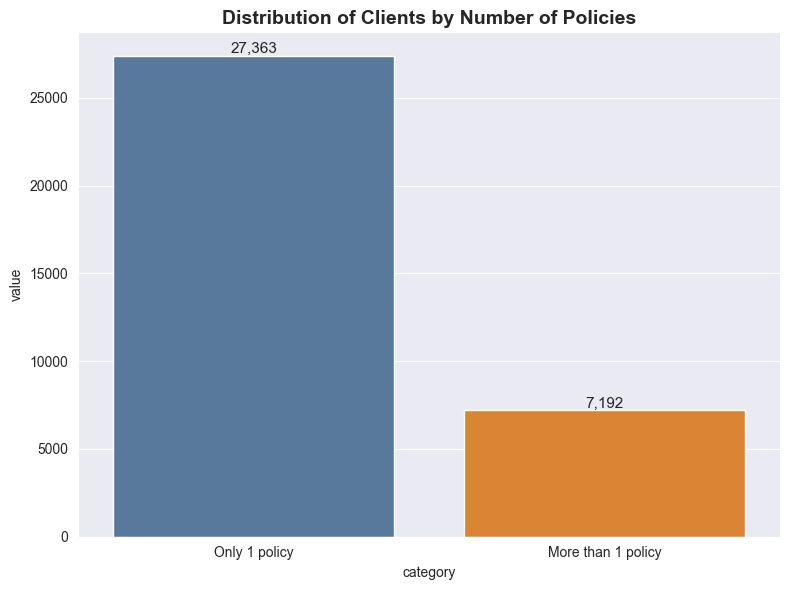

In [49]:
show_cli_policy_distribution(policy_client_data)

<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Feature normalization, query grouping and categorical alignment
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        This block contains utility functions for feature preprocessing, including group-wise normalization, query-level grouping, and consistent categorical encoding between train and validation sets.
    </p>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Group-wise normalization:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Applies min-max normalization within predefined groups</li>
        <li>Each group is normalized independently using its own min and max values</li>
        <li>If all values in a group are identical, outputs 0 for that group</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Query grouping logic:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>If <code>ponuda_id</code> exists, grouping is performed by offer ID</li>
        <li>Ensures no single-item groups exist (assertion check)</li>
        <li>Otherwise, grouping is done by <code>(klijent_id, dat_izdavanja)</code></li>
        <li>Returns group sizes as a NumPy array</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Categorical alignment between train and validation:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Ensures consistent encoding of categorical variables across train and validation sets</li>
        <li>Prevents mismatch issues caused by independent encoding</li>
        <li>Creates a unified category space from both datasets</li>
        <li>Encodes categories using shared mapping to maintain consistency</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 0 0; font-family: sans-serif;">
        These utilities are essential for stable ranking and learning-to-rank feature preparation pipelines.
    </p>

</div>

In [50]:
def normalize_by_group(values, group):
    values = np.asarray(values, dtype=float)
    out = np.zeros_like(values, dtype=float)

    start = 0
    for gsize in group:
        end = start + gsize
        x = values[start:end]

        x_min = np.min(x)
        x_max = np.max(x)

        if x_max > x_min:
            out[start:end] = (x - x_min) / (x_max - x_min)
        else:
            out[start:end] = 0.0

        start = end

    return out


def get_query_group(dataset: pd.DataFrame) -> np.ndarray:
    if "ponuda_id" in dataset.columns:
        counts = dataset.groupby("ponuda_id", sort=False).size()
        bad = (counts == 1).sum()
        assert bad == 0, (
            f"get_query_group: {bad} redova u grupama od 1 — "
            f"pozovi filter_single_candidate_groups prije ovoga"
        )
        return counts.to_numpy()
    return dataset.groupby(["klijent_id", "dat_izdavanja"], sort=False).size().to_numpy()


def align_categorical_columns(X_train, X_val, categorical_cols):
    """
    Ne kodirati train i val kategorije odvojeno.
    Odvojeni .cat.codes moze napraviti bug:
    ista sifra u trainu i valu ne mora dobiti isti integer kod.
    """
    for col in categorical_cols:
        if col not in X_train.columns or col not in X_val.columns:
            continue


        train_vals = X_train[col].astype("object")
        val_vals = X_val[col].astype("object")

        categories = pd.Index(train_vals.dropna().unique()).union(
            pd.Index(val_vals.dropna().unique())
        )

        X_train[col] = pd.Categorical(train_vals, categories=categories).codes
        X_val[col] = pd.Categorical(val_vals, categories=categories).codes

    return X_train, X_val

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Rank Aggregation umjesto stackinga - Reciprocal Rank Fusion (RRF)


</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p>Pokusacu ovo da dobijem bolji score od obicnog blend-a</p>
</div>

In [51]:
def softmax_calibrate(scores: np.ndarray, group: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    """
    Per-group softmax kalibracija — normalizuje sirove score-ove modela
    na vjerojatnosnu distribuciju unutar svake ranking grupe.
    
    temperature > 1.0 → ravnomjernija distribucija (manje sigurna)
    temperature < 1.0 → oštrija distribucija (više sigurna)
    temperature = 1.0 → standardni softmax
    """
    out = np.empty_like(scores, dtype=float)
    start = 0
    for g in group:
        end = start + g
        x = scores[start:end] / temperature
        x = x - x.max()  # numerička stabilnost
        exp_x = np.exp(x)
        out[start:end] = exp_x / exp_x.sum()
        start = end
    return out

In [52]:
def rrf_blend(scores_dict, group, weights, k=60, calibrate=False, temperature=1.0):
    """
    Reciprocal Rank Fusion — vektorizovana implementacija.
    
    calibrate=True → primijeni softmax per-group prije rangiranja.
    Korisno kada modeli imaju drastično različite score skale.
    """
    n = len(next(iter(scores_dict.values())))
    final_scores = np.zeros(n)
    group_ids = np.repeat(np.arange(len(group)), group)

    for name, scores in scores_dict.items():
        w = weights.get(name, 0.0)
        if w == 0.0:
            continue

        if calibrate:
            scores = softmax_calibrate(scores, group, temperature=temperature)

        sort_key = np.lexsort((-scores, group_ids))
        sorted_gids = group_ids[sort_key]
        within_rank = np.arange(n) - np.searchsorted(sorted_gids, sorted_gids, side='left') + 1

        ranks = np.empty(n, dtype=np.int32)
        ranks[sort_key] = within_rank

        final_scores += w / (k + ranks)

    return final_scores

<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Main Training Pipeline and Fold Dataset Construction
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0 0 10px 0; font-family: sans-serif;">
        This section prepares all training and validation datasets used throughout the ranking pipeline. 
        Feature engineering, temporal validation splits, client clustering, candidate generation, and final dataset preparation are performed within each fold.
    </p>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Global feature preparation:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Generate renewal-related features when enabled</li>
        <li>Generate seasonal features when enabled</li>
        <li>Assign default placeholder values when optional feature groups are disabled</li>
        <li>Extract all unique policy types used as ranking candidates</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Fold dataset construction:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Create train and validation subsets according to temporal fold definitions</li>
        <li>Verify temporal boundaries and dataset sizes</li>
        <li>Monitor distribution differences between train and validation periods</li>
        <li>Ensure all validation samples occur strictly after training samples</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Leakage prevention:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Lookup tables are built exclusively from training data</li>
        <li>The most recent policy of each client is removed before cluster generation</li>
        <li>Future policy information is never exposed to feature engineering procedures</li>
        <li>Validation data uses only knowledge available at the corresponding training cutoff date</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Behavioral and transition features:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Build Markov transition probabilities between policy types</li>
        <li>Generate global and regional popularity statistics</li>
        <li>Generate segment-specific transition patterns when enabled</li>
        <li>Create future policy pairs used for ranking dataset generation</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Client clustering:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Build client portfolio representations</li>
        <li>Train K-Means clustering model on training clients</li>
        <li>Assign validation clients to the learned cluster structure</li>
        <li>Use cluster membership and distance information as additional predictive features</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Association rule mining:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Generate Apriori association rules from training data when enabled</li>
        <li>Create efficient rule lookup structures</li>
        <li>Use discovered associations as ranking features or blending signals</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Client history construction:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Build historical policy ownership matrices</li>
        <li>Generate cumulative client-level behavioral features</li>
        <li>Maintain temporal consistency using shifted historical information only</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Ranking dataset generation:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Create candidate-policy ranking examples</li>
        <li>Generate chunked datasets for memory-efficient processing</li>
        <li>Merge generated chunks into final train and validation datasets</li>
        <li>Sort records chronologically for stable query grouping</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 5px 0; font-family: sans-serif; font-weight: bold;">
        Final preprocessing:
    </p>
    <ul style="color: #222; font-size: 14px; font-family: sans-serif; margin-top: 0;">
        <li>Apply negative sampling on training data when enabled</li>
        <li>Remove groups containing only a single candidate</li>
        <li>Select available modeling features</li>
        <li>Align categorical encodings between train and validation datasets</li>
        <li>Create feature matrices, labels, and query groups required by learning-to-rank models</li>
    </ul>
    <p style="color: #222; font-size: 14px; margin: 10px 0 0 0; font-family: sans-serif;">
        The resulting output contains fully prepared train and validation datasets, feature matrices, labels, query groups, and optional association rules required          for model training, evaluation, and hyperparameter optimization.
    </p>

</div>

In [53]:
# ============================================================
# GLAVNI PIPELINE
# ============================================================

if INCLUDE_RENEWAL_FEATURES:
    df = add_renewal_features(df)
else:
    df['days_since_same_type'] = -1
    df['likely_annual_renewal'] = -1
    df['likely_semi_renewal'] = -1
    df['days_since_same_type_missing'] = -1
    
if INCLUDE_SEASONAL_FEATURES:
    df = add_seasonal_features(df)
else:
    df['month']   = -1
    df['quarter'] = -1
    df['month_sin'] = -1
    df['month_cos'] = -1

num_of_kmeans_clusters = NUM_KMEANS_CLUSTERS

# Kandidati
all_types  = df['sif_vrsta'].unique()
candidates = pd.DataFrame({'candidate_type': all_types})
print(f"\nUnique policy types: {len(all_types)}")
print(f"Distribucija tipova polisa:\n{df['sif_vrsta'].value_counts(normalize=True).round(3)}")


DATE_COL = "dat_izdavanja"
CLIENT_COL = "klijent_id"

def build_fold_dataset(df_sorted, fold_spec, fold_name):
    
    cutoff = fold_spec["cutoff"]
    val_end = fold_spec["val_end"]

    train_df = df_sorted.loc[fold_spec["train_idx"]].copy()
    val_df = df_sorted.loc[fold_spec["val_idx"]].copy()

    print(f"\n--- BUILD {fold_name} ---")
    print(
        f"Train: {train_df[DATE_COL].min().date()} -> "
        f"{train_df[DATE_COL].max().date()} ({len(train_df):,})"
    )
    
    print(
        f"Val:   {val_df[DATE_COL].min().date()} -> "
        f"{val_df[DATE_COL].max().date()} ({len(val_df):,})"
    )

    train_dist = train_df["sif_vrsta"].value_counts(normalize=True)
    val_dist = val_df["sif_vrsta"].value_counts(normalize=True)
    dist_diff = (train_dist - val_dist).abs().mean()

    print(f"Distribucija train/val diff: {dist_diff:.4f}")

    # Lookup tablice se grade ISKLJUCIVO na train dijelu folda.
    markov_transitions = _build_markov_with_decay(train_df)
    mt_dict = markov_transitions.set_index(["from_type", "to_type"])["prob"].to_dict()

    global_pop, reg_pop = build_popularity_features(train_df)
    seg_markov_dict = build_segment_markov(train_df) if INCLUDE_SEGMENT_MARKOV else {}


    # Client clusters
    # NOVO — trimuj PRIJE nego gradimo cluster input features
    # Razlog: _build_cluster_input_data() pravi portfolio od sif_vrsta.
    # Zadnja polisa po klijentu je TARGET (ono što model treba predvidjeti).
    # Ako je ostavimo, portfolio uključuje "buduću" vrstu polise →
    # client_cluster feature u modelu indirektno nosi label informaciju.
    train_df_trimmed = train_df[train_df.groupby(CLIENT_COL).cumcount(ascending=False) != 0].copy()
    val_df_trimmed   = val_df[val_df.groupby(CLIENT_COL).cumcount(ascending=False) != 0].copy()
    
    if len(train_df_trimmed) < 100 or len(val_df_trimmed) < 20:
        raise ValueError(f"{fold_name}: premalo podataka nakon uklanjanja zadnje polise")

    cluster_type_pop_dict = {}
    
    if INCLUDE_CLIENT_CLUSTERS:
        cluster_map_train, dist_map_train, kmeans_model, cluster_scaler, cluster_columns, pca_model = build_client_train_clusters(
            train_df_trimmed, n_clusters=num_of_kmeans_clusters
        )
        cluster_type_pop_dict = build_cluster_type_pop(train_df_trimmed, cluster_map_train)
        cluster_map_val, dist_map_val = apply_cluster_map_to_val(
            val_df_trimmed, kmeans_model, cluster_scaler, cluster_columns, pca_model
        )
    else:
        cluster_map_train     = {}
        cluster_map_val       = {}
        dist_map_train        = {}
        dist_map_val          = {}
        cluster_type_pop_dict = {}
    
    # Uvijek računaj — ne ovise o klasterima
    cooccurrence_cf     = build_cooccurrence_cf(train_df_trimmed)
    business_value_dict = build_business_value_score(train_df_trimmed)

    
    if USE_APRIORI_AS_FEATURE or BLEND_APRIORI:
        apriori_rules_for_chunks = build_apriori_rules(
            train_df_trimmed,
            min_support=APRIORI_MIN_SUPP,
            min_confidence=APRIORI_MIN_CONFIDENCE
        )
        rule_lookup_for_chunks = build_rule_lookup(apriori_rules_for_chunks)
        
        # DEBUG — provjeri koliko pravila i kakva su
        print(f"Broj pravila: {len(apriori_rules_for_chunks)}")
        if len(apriori_rules_for_chunks) > 0:
            print(apriori_rules_for_chunks[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))
    else:
        apriori_rules_for_chunks = None
        rule_lookup_for_chunks = {}
    

    if INCLUDE_CLIENT_CLUSTERS:
        for k in range(num_of_kmeans_clusters):   # ← num_of_kmeans_clusters iz outer scope
            col = f'cluster_dist_{k}'
            if col not in training_features:
                training_features.append(col)
    
    # Ovo sada postaje samo assignment (trim je već urađen iznad)
    train_df = train_df_trimmed
    val_df   = val_df_trimmed

    train_df = train_df.sort_values([CLIENT_COL, DATE_COL, 'ponuda_id']).copy()
    val_df   = val_df.sort_values([CLIENT_COL, DATE_COL, 'ponuda_id']).copy()

    train_df_full_for_history = train_df.copy()
    val_df_full_for_history = val_df.copy()
    
    train_df = train_df[
        train_df.groupby([CLIENT_COL, DATE_COL]).cumcount() == 0
    ].copy()
    
    val_df = val_df[
        val_df.groupby([CLIENT_COL, DATE_COL]).cumcount() == 0
    ].copy()

    # ============================================================
    # NOVI KOD — zamjena za gornja dva reda, ide NAKON:
    #   train_df_full_for_history = train_df.copy()
    #   val_df_full_for_history   = val_df.copy()
    #   train_df = train_df[cumcount() == 0].copy()
    #   val_df   = val_df[cumcount() == 0].copy()
    # ============================================================
    
    # _build_future_pairs treba FULL podatke sesije (sve police po datumu),
    # ali labele moraju odgovarati ponuda_id koji ide u chunk builder (cumcount==0).
    # Oboje su garantovani jer _build_future_pairs interno uzima iloc[0] po sesiji,
    # što se poklapa sa cumcount()==0.
    future_pairs_train = _build_future_pairs(train_df_full_for_history)
    future_pairs_val   = _build_future_pairs(val_df_full_for_history)
    
    # Izbaci iz chunk buildera ponude koje nemaju nijedan label —
    # to su sesije bez sljedećeg datuma (zadnja sesija klijenta u periodu).
    # filter_no_positive_groups ostaje kao sanity check ali ne bi trebao ništa ukloniti.
    valid_train_ponude = set(future_pairs_train['ponuda_id'])
    valid_val_ponude   = set(future_pairs_val['ponuda_id'])
    train_df = train_df[train_df['ponuda_id'].isin(valid_train_ponude)].copy()
    val_df   = val_df[val_df['ponuda_id'].isin(valid_val_ponude)].copy()

    client_hist_train_all = _build_client_history_matrix(train_df_full_for_history)
    
    train_ponude = set(train_df['ponuda_id'].unique())  # ← ovo nedostaje
    client_hist_train = client_hist_train_all[
        client_hist_train_all['ponuda_id'].isin(train_ponude)
    ]
    
    # Za val — current state (cumsum bez shift) zadnje train polise po klijentu
    client_hist_train_current = _build_client_history_matrix_current(train_df_full_for_history)
    
    train_last_ponuda = (
        train_df_full_for_history
        .sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id'])
        .groupby('klijent_id').last()[['ponuda_id']]
        .reset_index()
        .rename(columns={'ponuda_id': 'train_ponuda_id'})
    )
    
    val_client_map = val_df[['klijent_id', 'ponuda_id']].copy()
    val_hist_bridge = val_client_map.merge(train_last_ponuda, on='klijent_id', how='left')
    
    train_hist_lookup = client_hist_train_current.rename(columns={'ponuda_id': 'train_ponuda_id'})
    val_hist_with_train = val_hist_bridge.merge(train_hist_lookup, on='train_ponuda_id', how='left')
    
    type_cols = [c for c in val_hist_with_train.columns if c.startswith('type_')]
    client_hist_val = val_hist_with_train[['ponuda_id'] + type_cols].fillna(0)

    # Sanity check — val klijenti bez ikakvog train historija
    new_clients = val_df[~val_df['klijent_id'].isin(train_df_full_for_history['klijent_id'])]['klijent_id'].nunique()
    print(f"Val klijenti bez train historija (sve nule): {new_clients}")

        
    history_type_cols = [c for c in client_hist_train.columns if c != "ponuda_id"]
    features = BASE_FEATURES + history_type_cols
    training_features = TRAINING_FEATURES + history_type_cols

    embedding_map, emb_svd, emb_type_idx = build_policy_type_embeddings(
        train_df_full_for_history, n_components=EMB_COMPONENTS
    )
    
    emb_cols = [f'cand_emb_{i}' for i in range(EMB_COMPONENTS)]
    
    # Dodaj u OBA:
    for col in emb_cols:
        if col not in features:           # features = BASE_FEATURES + history_type_cols
            features.append(col)
        if col not in training_features:
            training_features.append(col)

    if len(train_df) < 100 or len(val_df) < 20:
        raise ValueError(f"{fold_name}: premalo podataka nakon uklanjanja zadnje polise")

    gc.collect()
    
    sc_train, td = _build_training_chunks(
        train_df, future_pairs_train, mt_dict, candidates,
        client_hist_train, global_pop, reg_pop, seg_markov_dict,
        cluster_map_train, features,
        chunks_dir=f"chunks_train_{fold_name}",
        rule_lookup=rule_lookup_for_chunks,
        dist_map=dist_map_train if INCLUDE_CLIENT_CLUSTERS else {},
        embedding_map = embedding_map, cluster_type_pop_dict=cluster_type_pop_dict,
        cooccurrence_cf=cooccurrence_cf,
        business_value_dict=business_value_dict
    )
    
    sc_val, vd = _build_training_chunks(
        val_df, future_pairs_val, mt_dict, candidates,
        client_hist_val, global_pop, reg_pop, seg_markov_dict,
        cluster_map_val, features,
        chunks_dir=f"chunks_val_{fold_name}",
        rule_lookup=rule_lookup_for_chunks,
        dist_map=dist_map_val if INCLUDE_CLIENT_CLUSTERS else {},
        embedding_map = embedding_map, cluster_type_pop_dict=cluster_type_pop_dict,
        cooccurrence_cf=cooccurrence_cf,
        business_value_dict=business_value_dict
    )

    train_dataset = merge_chunks(sc_train, td)
    val_dataset = merge_chunks(sc_val, vd)

    train_dataset = train_dataset.sort_values(
        [CLIENT_COL, DATE_COL]
    ).reset_index(drop=True)

    val_dataset = val_dataset.sort_values(
        [CLIENT_COL, DATE_COL]
    ).reset_index(drop=True)

    def debug_no_positive_groups(dataset, name):
        label_sum = dataset.groupby('ponuda_id')['label'].sum()
        no_pos_ids = label_sum[label_sum == 0].index
    
        print(f"\n{name}: grupe bez label=1: {len(no_pos_ids)}")
    
        if len(no_pos_ids) > 0:
            sample_id = no_pos_ids[0]
            sample = dataset[dataset['ponuda_id'] == sample_id]
    
            print(f"Primjer ponuda_id bez label=1: {sample_id}")
            print(sample[[
                'ponuda_id', 'klijent_id', 'dat_izdavanja',
                'sif_vrsta', 'candidate_type', 'label'
            ]].head(20).to_string(index=False))
    
            klijent = sample['klijent_id'].iloc[0]
            print("\nHistorija klijenta u fold df:")
            print(
                df_sorted[df_sorted['klijent_id'] == klijent][[
                    'ponuda_id', 'klijent_id', 'dat_izdavanja', 'sif_vrsta'
                ]]
                .sort_values(['dat_izdavanja', 'ponuda_id'])
                .to_string(index=False)
            )
    
    debug_no_positive_groups(train_dataset, "TRAIN")
    debug_no_positive_groups(val_dataset, "VAL")

    if DO_NEGATIVE_SAMPLING:
        # Negative sampling samo na trainu.
        train_dataset = sample_negatives(train_dataset)
        train_dataset = train_dataset.sort_values(
            [CLIENT_COL, DATE_COL]
        ).reset_index(drop=True)

    train_dataset = filter_single_candidate_groups(train_dataset)
    val_dataset   = filter_single_candidate_groups(val_dataset)

    train_dataset = filter_no_positive_groups(train_dataset)
    val_dataset   = filter_no_positive_groups(val_dataset)

    assert train_dataset.groupby('ponuda_id')['label'].sum().min() > 0
    assert val_dataset.groupby('ponuda_id')['label'].sum().min() > 0

    # drop_debug_features = ["target_is_renewal", "client_cluster"]
    drop_debug_features = ["target_is_renewal"]
    

    available_features = [
        c for c in training_features
        if c in train_dataset.columns and c in val_dataset.columns
        and c not in drop_debug_features
    ]
    
    print('\n\n')
    
    # Garancija — puca glasno ako debug feature uđe u model
    assert not any(f in available_features for f in DEBUG_FEATURES), \
        f"DEBUG_FEATURES su ušli u available_features: {set(DEBUG_FEATURES) & set(available_features)}"

    # ============================================================
    # RENEWAL DOWNSAMPLING — smanji dominaciju renewal signala
    # Na svakoj renewal grupi (label=1 i same_as_current=1),
    # zadrži samo 40% → forsira model da uči CS signal
    # ============================================================
    RENEWAL_KEEP_RATE = 0.4  # ← tuniraj, počni s 0.4
    
    renewal_train_pids = (
        train_dataset[
            (train_dataset['label'] == 1) &
            (train_dataset['candidate_same_as_current'] == 1)
        ]['ponuda_id'].unique()
    )
    cs_train_pids = (
        train_dataset[~train_dataset['ponuda_id'].isin(renewal_train_pids)]['ponuda_id'].unique()
    )
    
    renewal_sample = (
        train_dataset[train_dataset['ponuda_id'].isin(renewal_train_pids)]
        .groupby('ponuda_id', group_keys=False)
        .apply(lambda x: x)  # zadrži sve redove grupe
    )
    # Sampliraj grupe, ne redove
    rng = np.random.default_rng(42)
    keep_pids = rng.choice(
        renewal_train_pids,
        size=int(len(renewal_train_pids) * RENEWAL_KEEP_RATE),
        replace=False
    )
    train_dataset = pd.concat([
        train_dataset[train_dataset['ponuda_id'].isin(keep_pids)],
        train_dataset[train_dataset['ponuda_id'].isin(cs_train_pids)]
    ]).sort_values([CLIENT_COL, DATE_COL]).reset_index(drop=True)
    
    print(f"Nakon renewal downsampling: {len(train_dataset):,} redova "
          f"({len(keep_pids)} renewal + {len(cs_train_pids)} CS grupa)")
    
    X_train = train_dataset[available_features].copy()
    X_val   = val_dataset[available_features].copy()


    
    X_train, X_val = align_categorical_columns(
        X_train,
        X_val,
        CATEGORICAL_FEATURES,
    )

    y_train = train_dataset["label"].astype(int).to_numpy()
    y_val = val_dataset["label"].astype(int).to_numpy()

    group_train = get_query_group(train_dataset)
    group_val = get_query_group(val_dataset)

    assert group_train.sum() == len(X_train)
    assert group_val.sum() == len(X_val)

    # ============================================================
    # LEAKAGE DIJAGNOZA — pokreće se unutar svakog folda
    # ============================================================
    _diag_fp = future_pairs_val.merge(
        val_df_full_for_history[['ponuda_id', 'sif_vrsta']].drop_duplicates('ponuda_id'),
        on='ponuda_id', how='left'
    )
    _same_type_mask = _diag_fp['candidate_type'] == _diag_fp['sif_vrsta']
    _cs_renewal_rate = _diag_fp.loc[~_same_type_mask, 'target_is_renewal'].mean()
    
    print(f"\n[LEAKAGE CHECK] {fold_name}")
    print(f"  future_pairs — label=1 parova: {len(future_pairs_val):,}")
    print(f"  Grupe sa 2+ labela (same-day): {(future_pairs_val.groupby('ponuda_id')['label'].sum() > 1).sum()}")
    print(f"  CS kandidati s target_is_renewal=1: {_cs_renewal_rate:.1%}  "
          f"{'⚠️  BUG u _build_future_pairs!' if _cs_renewal_rate > 0.05 else '✅ OK'}")
    
    # Candidate_same_as_current vs label overlap
    _csc_label = val_dataset[val_dataset['label'] == 1].copy()
    _overlap = (
        (_csc_label['candidate_same_as_current'] == 1).sum() / len(_csc_label)
    )
    print(f"  label=1 redovi gdje same_as_current=1: {_overlap:.1%}  "
          f"{'⚠️  Gotovo sve renewale!' if _overlap > 0.85 else ''}")
    
    # Feature-label korelacije — top 5
    _num_cols = ['had_type_before', 'cnt_type_before', 'candidate_same_as_current',
                 'n_policies_before', 'markov_prob', 'days_since_same_type']
    _corrs = {c: val_dataset[c].astype(float).corr(val_dataset['label'].astype(float))
              for c in _num_cols if c in val_dataset.columns}
    _corr_s = pd.Series(_corrs).abs().sort_values(ascending=False)
    print(f"  Feature-label korelacije:\n{_corr_s.to_string()}")

    return {
        "fold": fold_spec["fold"],
        "fold_name": fold_name,
        "is_holdout": fold_spec["is_holdout"],
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "group_train": group_train,
        "group_val": group_val,
        "features": available_features,
        # APRIORI — ulazi u dict samo ako je uključen
        **( {"apriori_rules": apriori_rules_for_chunks} 
            if (BLEND_APRIORI or USE_APRIORI_AS_FEATURE) else {} )
    }



Unique policy types: 14
Distribucija tipova polisa:
sif_vrsta
1     0.349
6     0.204
7     0.161
8     0.074
5     0.071
9     0.048
15    0.038
13    0.018
22    0.018
17    0.007
23    0.004
12    0.003
4     0.003
11    0.002
Name: proportion, dtype: float64


<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Defining Optuna trial variable scopes for optimization
</h2>

In [54]:
def suggest_lgbm_params(trial):
    return {
        "objective": "lambdarank",
        "n_estimators": trial.suggest_int("n_estimators", 300, 1800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 96),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 120),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

In [55]:
def suggest_xgb_params(trial):
    return {
        'objective':        'rank:ndcg',
        'n_estimators':     trial.suggest_int('xgb_n_estimators', 200, 800),
        'learning_rate':    trial.suggest_float('xgb_learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('xgb_max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('xgb_min_child_weight', 5, 50),
        'subsample':        trial.suggest_float('xgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('xgb_reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda':       trial.suggest_float('xgb_reg_lambda', 1e-4, 5.0, log=True),
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0,
    }

In [56]:
def suggest_cat_params(trial, cat_features_in_model):
    
    if not USE_CATBOOST:
        return {}
        
    return {
        'loss_function':  'YetiRank',
        'iterations':     trial.suggest_int('cat_iterations', 200, 800),
        'learning_rate':  trial.suggest_float('cat_learning_rate', 0.01, 0.15, log=True),
        'depth':          trial.suggest_int('cat_depth', 4, 10),
        'l2_leaf_reg':    trial.suggest_float('cat_l2', 1.0, 10.0),
        'random_seed':    42,
        'verbose':        False,
        'cat_features':   cat_features_in_model  # <-- proslijedi iz contexta
    }

In [57]:
def suggest_blend_weights(trial):
    """
    Garantovano sum-to-1 uz Optuna-friendly sequential remaining pattern.
    Redoslijed sugestija: lgbm → xgb → (cat) → markov → apriori → ostatak se ne gubi.
    """
    w_lgbm = trial.suggest_float('w_lgbm', 0.1, 0.8)
    remaining = 1.0 - w_lgbm

    w_xgb = trial.suggest_float('w_xgb', 0.1, min(0.7, remaining - 0.0))
    remaining -= w_xgb

    if USE_CATBOOST:
        w_cat = trial.suggest_float('w_cat', 0.0, remaining)
        remaining -= w_cat
    else:
        w_cat = 0.0

    if BLEND_MARKOV_PROBS:
        w_markov = trial.suggest_float('w_markov', 0.0, remaining)
        remaining -= w_markov
    else:
        w_markov = 0.0

    if BLEND_APRIORI:
        w_apriori = trial.suggest_float('w_apriori', 0.0, remaining)
        remaining -= w_apriori
    else:
        w_apriori = 0.0

    # Ostatak ide na lgbm — ne gubi se ni jedan procenat
    w_lgbm += remaining

    assert abs(w_lgbm + w_xgb + w_cat + w_markov + w_apriori - 1.0) < 1e-9, \
        f"Weightovi ne zbrajaju na 1.0: {w_lgbm + w_xgb + w_cat + w_markov + w_apriori}"

    return w_lgbm, w_xgb, w_cat, w_markov, w_apriori

<h2 style="color: #2D5A27; font-size: 25px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Ranker evaluation
</h2>

In [58]:
def evaluate_ranker_scores(scores, y, group):
    return {
        "hr1": hit_rate_at_k(scores, y, group, k=1),
        "hr3": hit_rate_at_k(scores, y, group, k=3),
        "hr5": hit_rate_at_k(scores, y, group, k=5),
        "mrr3": mrr_at_k(scores, y, group, k=3),
        "mrr5": mrr_at_k(scores, y, group, k=5),
        "ndcg3": ndcg_at_k(scores, y, group, k = 3),
        "ndcg5": ndcg_at_k(scores, y, group, k = 5)
    }

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Optuna Objective Function (Hyperparameter Optimization)
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
<p>
This function defines the optimization objective used by Optuna to search for the best
combination of model hyperparameters and blending weights. For each trial, new
hyperparameters are generated for the LightGBM and XGBoost rankers, while optional
CatBoost parameters and ensemble weights are optimized simultaneously.
</p>

<p>
The optimization process is evaluated across all precomputed cross-validation folds:
</p>

<ul>
<li>LightGBM and XGBoost hyperparameters are sampled.</li>
<li>Blending weights for each model are optimized.</li>
<li>CatBoost hyperparameters are sampled when CatBoost is enabled.</li>
<li>Additional weights can be assigned to Markov probabilities and Apriori scores.</li>
</ul>

<p>
For each fold:
</p>

<ol>
<li>LightGBM and XGBoost ranking models are trained.</li>
<li>CatBoost is trained when enabled using grouped ranking data.</li>
<li>Predictions from all available models are normalized within each ranking group.</li>
<li>A weighted ensemble score is calculated by combining all normalized predictions.</li>
<li>Ranking metrics are computed from the blended scores.</li>
<li>A fold score is generated using a weighted combination of HR@3 and NDCG@5.</li>
</ol>

<p>
After each fold, the intermediate score is reported to Optuna, allowing poor-performing
trials to be pruned early and reducing overall optimization time. Once all folds have
been evaluated, the function returns the average score across folds, representing the
overall quality of the current hyperparameter and blending configuration.
</p>

<p>
<b>Optimized Components:</b>
</p>

<ul>
<li>LightGBM hyperparameters</li>
<li>XGBoost hyperparameters</li>
<li>CatBoost hyperparameters (optional)</li>
<li>Model blending weights</li>
<li>Markov probability weight</li>
<li>Apriori score weight</li>
</ul>

<p>
<b>Optimization Goal:</b> identify the combination of hyperparameters and ensemble
weights that maximizes recommendation quality, measured through a weighted combination
of HR@3 and NDCG@5 ranking metrics.
</p>
</div>

In [59]:
def optuna_objective(trial, fold_cache):
 
    lgbm_params = suggest_lgbm_params(trial)
    xgb_params  = suggest_xgb_params(trial)
    lgbm_params['n_jobs'] = 1
    xgb_params['nthread'] = 1

    w_lgbm, w_xgb, w_cat, w_markov, w_apriori = suggest_blend_weights(trial)

    if USE_CATBOOST:
        cat_feats  = [f for f in CATEGORICAL_FEATURES if f in fold_cache[0]['features']]
        cat_params = suggest_cat_params(trial, cat_feats)
        cat_params['thread_count'] = 1
    else:
        cat_params = {}

    temperature    = trial.suggest_float('temperature', 0.3, 3.0, log=True)
    rrf_k          = trial.suggest_int('rrf_k', 20, 100)
    renewal_weight = trial.suggest_float('renewal_weight', 0.1, 0.7)  # ← NOVO

    fold_scores = []

    for i, fd in enumerate(fold_cache):

        # ── Renewal downweighting ─────────────────────────────────
        _rw = trial.suggest_float('renewal_weight', 0.1, 0.7)  # u optuna_objective
        # _rw = best_params.get('renewal_weight', 0.3)          # u train_and_evaluate_best
        
        _train_ds = fd['train_dataset']
        _ren_pids = (
            _train_ds[
                (_train_ds['label'] == 1) &
                (_train_ds['candidate_same_as_current'] == 1)
            ]['ponuda_id'].unique()
        )
        _ren_pid_set = set(_ren_pids)
        
        # Per-row weights — za LGBM (prima row-level)
        _row_weights = np.where(
            _train_ds['ponuda_id'].isin(_ren_pid_set).values,
            _rw, 1.0
        )
        
        # Per-group weights — za XGBoost (prima group-level, jedan po ponuda_id)
        _group_order = _train_ds.groupby('ponuda_id', sort=False).ngroup()
        _group_pids  = _train_ds.groupby('ponuda_id', sort=False)['ponuda_id'].first()
        _group_weights = np.where(
            _group_pids.isin(_ren_pid_set).values,
            _rw, 1.0
        )
        # ─────────────────────────────────────────────────────────
        
        lgbm = LGBMRanker(**lgbm_params)
        lgbm.fit(
            fd['X_train'], fd['y_train'], group=fd['group_train'],
            sample_weight=_row_weights,           # ← row-level
            eval_set=[(fd['X_val'], fd['y_val'])],
            eval_group=[fd['group_val']], eval_at=[1],
            callbacks=[early_stopping(80, verbose=False, first_metric_only=True)]
        )
        
        xgb = XGBRanker(**xgb_params, early_stopping_rounds=50)
        xgb.fit(
            fd['X_train'], fd['y_train'], group=fd['group_train'],
            sample_weight=_group_weights,         # ← group-level
            eval_set=[(fd['X_val'], fd['y_val'])],
            eval_group=[fd['group_val']], verbose=False
        )

        if USE_CATBOOST:
            train_group_id = np.repeat(np.arange(len(fd['group_train'])), fd['group_train'])
            val_group_id   = np.repeat(np.arange(len(fd['group_val'])),   fd['group_val'])
            cat_feats      = [f for f in CATEGORICAL_FEATURES if f in fd['X_train'].columns]
            train_pool     = Pool(fd['X_train'], fd['y_train'],
                                  group_id=train_group_id, cat_features=cat_feats,
                                  weight=sample_weights)               # ← NOVO
            val_pool       = Pool(fd['X_val'], fd['y_val'],
                                  group_id=val_group_id, cat_features=cat_feats)
            cat = CatBoostRanker(**cat_params)
            cat.fit(train_pool, eval_set=val_pool,
                    early_stopping_rounds=50, verbose=0, use_best_model=True)
            cat_scores = cat.predict(fd['X_val'])
        else:
            cat        = None
            cat_scores = np.zeros(len(fd['y_val']))

        apriori_scores = (
            fd['val_dataset']['candidate_apriori_score'].values
            if BLEND_APRIORI else np.zeros(len(fd['y_val']))
        )
        markov_scores = (
            fd['val_dataset']['markov_prob'].values
            if BLEND_MARKOV_PROBS else np.zeros(len(fd['y_val']))
        )

        scores_dict = {
            'lgbm'   : lgbm.predict(fd['X_val']),
            'xgb'    : xgb.predict(fd['X_val']),
            'cat'    : cat_scores,
            'markov' : markov_scores,
            'apriori': apriori_scores,
        }
        weights_dict = {
            'lgbm'   : w_lgbm,
            'xgb'    : w_xgb,
            'cat'    : w_cat,
            'markov' : w_markov,
            'apriori': w_apriori,
        }

        blended = rrf_blend(scores_dict, fd['group_val'], weights_dict,
                            k=rrf_k, calibrate=True, temperature=temperature)

        overall_metrics = evaluate_ranker_scores(blended, fd['y_val'], fd['group_val'])

        # ── CS / Renewal split ────────────────────────────────
        val_df = fd['val_dataset'].copy()
        val_df['pred'] = blended

        group_labels = (
            val_df[val_df['label'] == 1]
            .groupby('ponuda_id')['candidate_same_as_current'].max()
        )
        renewal_ponude     = group_labels[group_labels == 1].index
        non_renewal_ponude = group_labels[group_labels == 0].index

        if len(non_renewal_ponude) > 10:
            nr_val    = val_df[val_df['ponuda_id'].isin(non_renewal_ponude)].copy()
            nr_group  = get_query_group(nr_val)
            cs_metrics = evaluate_ranker_scores(
                nr_val['pred'].values, nr_val['label'].values, nr_group
            )

            r_val     = val_df[val_df['ponuda_id'].isin(renewal_ponude)].copy()
            r_group   = get_query_group(r_val)
            r_metrics = evaluate_ranker_scores(
                r_val['pred'].values, r_val['label'].values, r_group
            )

            imbalance_penalty = max(0, r_metrics['hr1'] - cs_metrics['hr1'] - 0.3) * 0.2

            # score = (
            #     0.50 * cs_metrics['ndcg3'] +
            #     0.35 * cs_metrics['hr1']   +
            #     0.10 * cs_metrics['hr3']   +
            #     0.05 * overall_metrics['ndcg3']
            #     - imbalance_penalty
            # )

            score = (
                0.40 * cs_metrics['ndcg3'] +
                0.20 * cs_metrics['hr1'] +
                0.20 * r_metrics['hr1'] +
                0.20 * overall_metrics['ndcg3']
            )
        else:
            cs_metrics = overall_metrics
            score = overall_metrics['ndcg3']

        fold_scores.append(score)

        trial.report(float(np.mean(fold_scores)), step=i)
        if trial.should_prune():
            raise optuna.TrialPruned()

        del lgbm, xgb, cat
        gc.collect()

    return float(np.mean(fold_scores))

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Final Model Training and Evaluation
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">

<p>
This function trains the final ensemble using the best hyperparameters and blending
weights obtained during the Optuna optimization process. Its purpose is to evaluate
the selected configuration on a validation fold and generate the final ranking metrics.
</p>

<p>
The training pipeline consists of multiple ranking models whose predictions are later
combined into a weighted ensemble:
</p>

<ul>
<li>LightGBM Ranker</li>
<li>XGBoost Ranker</li>
<li>CatBoost Ranker (optional)</li>
<li>Markov transition probabilities (optional)</li>
<li>Apriori association rule scores (optional)</li>
</ul>

<p>
For each evaluation run:
</p>

<ol>
<li>LightGBM is trained using the optimized hyperparameters and early stopping.</li>
<li>XGBoost is trained using the optimized hyperparameters and validation monitoring.</li>
<li>CatBoost is trained when enabled using ranking pools with grouped observations.</li>
<li>Predictions from all available models are generated for the validation dataset.</li>
<li>Each prediction source is normalized within its ranking group.</li>
<li>A weighted ensemble score is calculated using the optimized blending weights.</li>
<li>Ranking metrics are computed from the final blended predictions.</li>
</ol>

<p>
The resulting ensemble combines the strengths of multiple ranking approaches while
optionally incorporating sequential behavior information through Markov probabilities
and association patterns through Apriori rules.
</p>

<p>
<b>Evaluation Metrics:</b>
</p>

<ul>
<li>HR@1 (Hit Rate at 1)</li>
<li>HR@3 (Hit Rate at 3)</li>
<li>HR@5 (Hit Rate at 5)</li>
<li>MRR@5 (Mean Reciprocal Rank at 5)</li>
<li>NDCG@5 (Normalized Discounted Cumulative Gain at 5)</li>
</ul>

<p>
<b>Output:</b> the function returns the trained LightGBM, XGBoost, and CatBoost models,
along with the blended prediction scores and the complete set of ranking evaluation
metrics for further analysis.
</p>

</div>

In [60]:
def train_and_evaluate_best(lgbm_params, xgb_params, cat_params, weights, fd, label):
    w_lgbm, w_xgb, w_cat, w_markov, w_apriori, rrf_k, temperature = weights

    # ── Renewal downweighting ─────────────────────────────────
    _rw = best_params.get('renewal_weight', 0.3)
    
    _train_ds = fd['train_dataset']
    
    _ren_pids = (
        _train_ds[
            (_train_ds['label'] == 1) &
            (_train_ds['candidate_same_as_current'] == 1)
        ]['ponuda_id']
        .unique()
    )
    
    _ren_pid_set = set(_ren_pids)
    
    # --------------------------------------------------
    # LGBM / CatBoost -> row level weights
    # --------------------------------------------------
    _row_weights = np.where(
        _train_ds['ponuda_id'].isin(_ren_pid_set).values,
        _rw,
        1.0
    )
    
    # --------------------------------------------------
    # XGBoost -> group level weights
    # --------------------------------------------------
    _group_pids = (
        _train_ds
        .groupby('ponuda_id', sort=False)['ponuda_id']
        .first()
    )
    
    _group_weights = np.where(
        _group_pids.isin(_ren_pid_set).values,
        _rw,
        1.0
    )
    # ─────────────────────────────────────────────────────────

    lgbm = LGBMRanker(**lgbm_params)
    lgbm.fit(
        fd['X_train'], fd['y_train'],
        group=fd['group_train'],
        sample_weight=_row_weights,
        eval_set=[(fd['X_val'], fd['y_val'])],
        eval_group=[fd['group_val']],
        eval_at=[1, 3],
        callbacks=[log_evaluation(50), early_stopping(100, verbose=False)]
    )

    xgb = XGBRanker(**xgb_params, eval_metric="ndcg@1", early_stopping_rounds=50)
    xgb.fit(
        fd['X_train'], fd['y_train'],
        group=fd['group_train'],
        sample_weight=_group_weights,
        eval_set=[(fd['X_val'], fd['y_val'])],
        eval_group=[fd['group_val']],
        verbose=50,
    )

    if USE_CATBOOST:
        train_group_id  = np.repeat(np.arange(len(fd['group_train'])), fd['group_train'])
        val_group_id    = np.repeat(np.arange(len(fd['group_val'])),   fd['group_val'])
        cat_feats       = [f for f in CATEGORICAL_FEATURES if f in fd['X_train'].columns]
        train_pool = Pool(
            fd['X_train'],
            fd['y_train'],
            group_id=train_group_id,
            cat_features=cat_feats,
            weight=_row_weights
        )
        val_pool        = Pool(fd['X_val'], fd['y_val'],
                               group_id=val_group_id, cat_features=cat_feats)
        cat = CatBoostRanker(**cat_params)
        cat.fit(train_pool, eval_set=val_pool,
                early_stopping_rounds=50, verbose=0, use_best_model=True)
        cat_scores = cat.predict(fd['X_val'])
    else:
        cat        = None
        cat_scores = np.zeros(len(fd['y_val']))

    apriori_scores = (
        fd['val_dataset']['candidate_apriori_score'].values
        if BLEND_APRIORI else np.zeros(len(fd['y_val']))
    )
    markov_scores = (
        fd['val_dataset']['markov_prob'].values
        if BLEND_MARKOV_PROBS else np.zeros(len(fd['y_val']))
    )

    scores_dict = {
        'lgbm'   : lgbm.predict(fd['X_val']),
        'xgb'    : xgb.predict(fd['X_val']),
        'cat'    : cat_scores,
        'markov' : markov_scores,
        'apriori': apriori_scores,
    }
    weights_dict = {
        'lgbm'   : w_lgbm,
        'xgb'    : w_xgb,
        'cat'    : w_cat,
        'markov' : w_markov,
        'apriori': w_apriori,
    }

    blended = rrf_blend(scores_dict, fd['group_val'], weights_dict,
                        k=rrf_k, calibrate=True, temperature=temperature)

    metrics = evaluate_ranker_scores(blended, fd['y_val'], fd['group_val'])
    print(f"\n--- {label} ---")
    print(f"HR@1: {metrics['hr1']:.4f} | HR@3: {metrics['hr3']:.4f} | "
          f"HR@5: {metrics['hr5']:.4f} | MRR@5: {metrics['mrr5']:.4f} | NDCG@5: {metrics['ndcg5']:.4f}")
    print(f"Weights: LGBM={w_lgbm:.3f} XGB={w_xgb:.3f} CAT={w_cat:.3f} "
          f"Markov={w_markov:.3f} Apriori={w_apriori:.3f} | RRF_k={rrf_k} | renewal_w={_rw:.2f}")

    val_df = fd['val_dataset'].copy()
    val_df['pred'] = blended

    group_labels = (
        val_df[val_df['label'] == 1]
        .groupby('ponuda_id')['candidate_same_as_current'].max()
    )
    renewal_ponude     = group_labels[group_labels == 1].index
    non_renewal_ponude = group_labels[group_labels == 0].index

    r_val   = val_df[val_df['ponuda_id'].isin(renewal_ponude)].copy()
    r_group = get_query_group(r_val)
    r_m     = evaluate_ranker_scores(r_val['pred'].values, r_val['label'].values, r_group)

    nr_val   = val_df[val_df['ponuda_id'].isin(non_renewal_ponude)].copy()
    nr_group = get_query_group(nr_val)
    cs_m     = evaluate_ranker_scores(nr_val['pred'].values, nr_val['label'].values, nr_group)

    print(f"Renewal   HR@1: {r_m['hr1']:.4f} | HR@3: {r_m['hr3']:.4f}")
    print(f"CrossSell HR@1: {cs_m['hr1']:.4f} | HR@3: {cs_m['hr3']:.4f} | NDCG@3: {cs_m['ndcg3']:.4f}")

    return lgbm, xgb, cat, blended, metrics, cs_m, r_m

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   END-TO-END SYSTEM FOR TEMPORAL RECOMMANDATION MODEL
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <ol>
        <h3 style="color: #008080;"><li>Making temporal folds</li></h3>
        <h3 style="color: #008080;"><li>Dividing folds</li></h3>
        <h3 style="color: #008080;"><li>Picking optimal number of kMeans clusters</li></h3>
        <ul>
            <h4><li>Then testing K of 4 until 34:</li></h4>
            <h4><li>silhouette score (Bigger better)</li></h4>
            <h4><li>Davies-Bouldin (Less better)</li></h4>
            <h4><li>inertia / elbow</li></h4>
         </ul>
        <h3 style="color: #008080;"><li>Building fold datasets</li></h3>
        <h3 style="color: #008080;"><li>Filtering bad folds</li></h3>
        <h3 style="color: #008080;"><li>Optuna tuning</li></h3>
        <h3 style="color: #008080;"><li>Final evaluation (CV)</li></h3>
        <h3 style="color: #008080;"><li>Holdout test</li></h3>
    </ol>
</div>

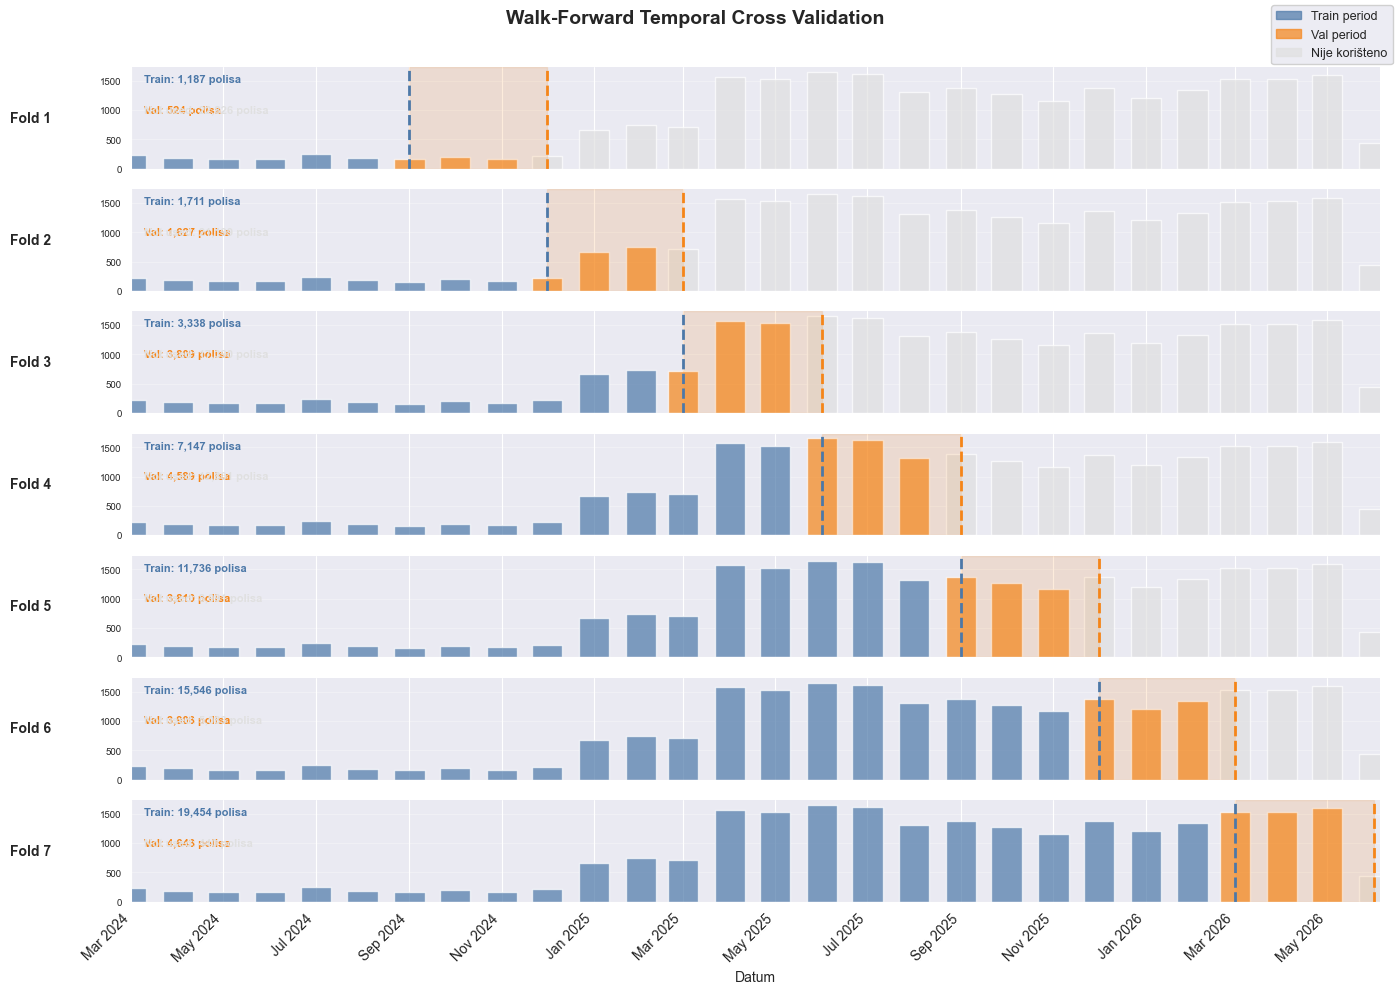


Fold   Train od     Train do     Val od       Val do         Train N    Val N  Dist diff
-------------------------------------------------------------------------------------
1      2024-03-01   2024-09-01   2024-09-01   2024-12-01       1,187      524     0.0064
2      2024-03-01   2024-12-01   2024-12-01   2025-03-01       1,711    1,627     0.3144
3      2024-03-01   2025-03-01   2025-03-01   2025-06-01       3,338    3,809     0.0632
4      2024-03-01   2025-06-01   2025-06-01   2025-09-01       7,147    4,589     0.0514
5      2024-03-01   2025-09-01   2025-09-01   2025-12-01      11,736    3,810     0.0258
6      2024-03-01   2025-12-01   2025-12-01   2026-03-01      15,546    3,908     0.0278
7      2024-03-01   2026-03-01   2026-03-01   2026-06-01      19,454    4,643     0.0302

--- BUILD f1 ---
Train: 2024-03-01 -> 2024-08-30 (1,187)
Val:   2024-09-02 -> 2024-11-29 (524)
Distribucija train/val diff: 0.0064
Broj pravila: 0


C:\Users\Korisnik\Desktop\wienner ml client-polisa predictions\venv\lib\site-packages\sklearn\decomposition\_truncated_svd.py:273: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = exp_var / full_var


Val klijenti bez train historija (sve nule): 10
   Policy embeddings: 2 tipova → 1 dimenzija (nan% varijanse co-occurrence matrice)


chunks_val_f1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.82it/s]
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_24144\3072084977.py:334: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x)  # zadrži sve redove grupe


   Shape: (3682, 52)
   Shape: (1414, 52)

TRAIN: grupe bez label=1: 0

VAL: grupe bez label=1: 0



Nakon renewal downsampling: 1,470 redova (105 renewal + 0 CS grupa)

[LEAKAGE CHECK] f1
  future_pairs — label=1 parova: 190
  Grupe sa 2+ labela (same-day): 0
  CS kandidati s target_is_renewal=1: nan%  ✅ OK
  label=1 redovi gdje same_as_current=1: 100.0%  ⚠️  Gotovo sve renewale!
  Feature-label korelacije:
candidate_same_as_current    1.000000e+00
markov_prob                  9.999986e-01
had_type_before              9.003714e-01
cnt_type_before              6.280876e-01
n_policies_before            2.429535e-17
days_since_same_type         4.926662e-18

--- BUILD f2 ---
Train: 2024-03-01 -> 2024-11-29 (1,711)
Val:   2024-12-02 -> 2025-02-28 (1,627)
Distribucija train/val diff: 0.3144
Broj pravila: 0


...


BEST OPTUNA SCORE: 0.6326067994739907
BEST PARAMS:
{'n_estimators': 1664, 'learning_rate': 0.0691723965379393, 'num_leaves': 89, 'max_depth': 5, 'min_child_samples': 91, 'subsample': 0.748816451605009, 'colsample_bytree': 0.693324166395774, 'reg_alpha': 0.0008368481367232248, 'reg_lambda': 0.1555190935874711, 'min_split_gain': 0.7234492789220567, 'xgb_n_estimators': 496, 'xgb_learning_rate': 0.011334103896599827, 'xgb_max_depth': 8, 'xgb_min_child_weight': 16, 'xgb_subsample': 0.7360425834003576, 'xgb_colsample_bytree': 0.7270757927813242, 'xgb_reg_alpha': 1.587430533062769, 'xgb_reg_lambda': 0.0006078301411742416, 'w_lgbm': 0.5560361082798522, 'w_xgb': 0.34825490340304965, 'temperature': 1.4625217186756885, 'rrf_k': 73, 'renewal_weight': 0.4035918830399611}

Weights: LGBM=0.556 XGB=0.348 CAT=0.000 Markov=0.000 Apriori=0.000 | RRF_k=73
[50]	valid_0's ndcg@1: 1	valid_0's ndcg@3: 1
[100]	valid_0's ndcg@1: 1	valid_0's ndcg@3: 1
[0]	validation_0-ndcg@1:1.00000
[50]	validation_0-ndcg@1:1.0

chunks_val_holdout_f7: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.10it/s]


   Shape: (72352, 71)
   Shape: (7812, 71)

TRAIN: grupe bez label=1: 0

VAL: grupe bez label=1: 0





C:\Users\Korisnik\AppData\Local\Temp\ipykernel_24144\3072084977.py:334: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x)  # zadrži sve redove grupe


Nakon renewal downsampling: 43,344 redova (1380 renewal + 1716 CS grupa)

[LEAKAGE CHECK] holdout_f7
  future_pairs — label=1 parova: 1,208
  Grupe sa 2+ labela (same-day): 136
  CS kandidati s target_is_renewal=1: 0.0%  ✅ OK
  label=1 redovi gdje same_as_current=1: 64.2%  
  Feature-label korelacije:
markov_prob                  0.686256
candidate_same_as_current    0.638646
had_type_before              0.485929
cnt_type_before              0.342203
n_policies_before            0.006961
days_since_same_type         0.004790
[50]	valid_0's ndcg@1: 0.594982	valid_0's ndcg@3: 0.801668
[100]	valid_0's ndcg@1: 0.586022	valid_0's ndcg@3: 0.79131
[150]	valid_0's ndcg@1: 0.594982	valid_0's ndcg@3: 0.796014
[0]	validation_0-ndcg@1:0.42115
[50]	validation_0-ndcg@1:0.58423
[78]	validation_0-ndcg@1:0.58423

--- FINAL TEMPORAL HOLDOUT ---
HR@1: 0.6093 | HR@3: 0.9480 | HR@5: 0.9910 | MRR@5: 0.7722 | NDCG@5: 0.8256
Weights: LGBM=0.556 XGB=0.348 CAT=0.000 Markov=0.000 Apriori=0.000 | RRF_k=73 | renew

In [61]:
df_sorted, folds = make_temporal_folds(
    df,
    val_months=3,
    min_train_months=6,
    step_months=3,
    reserve_last_fold=True,
)

cv_folds      = [f for f in folds if not f['is_holdout']]
holdout_folds = [f for f in folds if f['is_holdout']]

# ============================================================
# OPTIMALNI BROJ KLASTERA — jednom, prije fold buildanja
# ============================================================
num_of_kmeans_clusters = NUM_KMEANS_CLUSTERS  # fallback

if INCLUDE_CLIENT_CLUSTERS:
    num_of_kmeans_clusters = find_optimal_cluster_number(cv_folds)

# ============================================================
# 1. Build CV foldova
# ============================================================
fold_cache = []

for f in cv_folds:
    fd = build_fold_dataset(df_sorted, f, f'f{f["fold"]}')
    fold_cache.append(fd)

# 2. Filtriraj premale foldove
# NOVO — dva filtera:
# 1. MIN_VAL_GROUPS >= 300: statički premali val setovi daju nestabilne metrike
#    (fold 1 ima 151 grupu → CI ±7%, nije pouzdan signal za Optunu)
# 2. MAX_DIST_DIFF <= 0.10: ako je distribucija tipova polisa drastično drugačija
#    u val periodu, metrika ne mjeri pravu generalizaciju
#    (fold 2 ima dist_diff=0.3144 → 5x veći od ostalih, outlier)
MIN_VAL_GROUPS = 300
MAX_DIST_DIFF  = 0.10

cv_folds_for_optuna = []

for fd in fold_cache:
    n_val_groups = fd['val_dataset'].groupby(
        ['klijent_id', 'dat_izdavanja']
    ).ngroups

    val_df_tmp   = fd['val_dataset']
    train_df_tmp = fd['train_dataset']
    td = train_df_tmp['sif_vrsta'].value_counts(normalize=True)
    vd = val_df_tmp['sif_vrsta'].value_counts(normalize=True)
    dist_diff = (td - vd).abs().mean()

    reason = []
    if n_val_groups < MIN_VAL_GROUPS:
        reason.append(f"premalo val grupa ({n_val_groups} < {MIN_VAL_GROUPS})")
    if dist_diff > MAX_DIST_DIFF:
        reason.append(f"dist_diff prevelik ({dist_diff:.4f} > {MAX_DIST_DIFF})")

    if reason:
        print(f"Fold {fd['fold']}: ISKLJUČEN — {', '.join(reason)}")
    else:
        print(f"Fold {fd['fold']}: {n_val_groups} val grupa, dist_diff={dist_diff:.4f} ✓")
        cv_folds_for_optuna.append(fd)


print(f"\nFoldovi za Optuna: {len(cv_folds_for_optuna)} "
      f"(isključeno {len(fold_cache) - len(cv_folds_for_optuna)})")

if _TRAIN_MODEL:

    # 3. Optuna - jedan poziv
    # Sampler odlučuje: koje hyperparametre ću probati sljedeće
    # TPESampler(multivariate=True, group=True)
    # TPE (Tree-structured Parzen Estimator) → ne random
    # uči iz prethodnih trialova
    # pokušava pogoditi “dobre regije parametara”
    # multivariate=True  | ne optimizira svaki parametar izolovano nego gleda kombinacije
    # group=True | gleda strukturu trialova kao grupu korisno za ranking / fold evaluacije
    # PRUNER = KADA PREKINUTI LOŠ TRIAL
    # pruner odlučuje: da li da ubijem ovaj trial prije nego što završi
    # n_startup_trials=10 prvih 10 trialova ne pruni (da se sakupi “baseline”)
    # n_warmup_steps=1 ne pruni odmah na početku jednog triala (da se model bar malo “razvije”) | u svakom trial-u, prve evaluacijske tačke se ne prunaju
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, group=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1),
    )
    
    study.optimize(
        lambda trial: optuna_objective(trial, cv_folds_for_optuna),
        n_trials=OPTUNA_NTRIALS,
        show_progress_bar=True,
    )
    
    print("\nBEST OPTUNA SCORE:", study.best_value)
    print("BEST PARAMS:")
    print(study.best_params)
    
    best_params = study.best_params
    
    lgbm_params = suggest_lgbm_params(optuna.trial.FixedTrial(best_params))
    xgb_params  = suggest_xgb_params(optuna.trial.FixedTrial(best_params))
    
    cat_feats  = [f for f in CATEGORICAL_FEATURES if f in fold_cache[0]['features']]
    cat_params = {
        'loss_function': 'YetiRank',
        'iterations':    int(best_params['cat_iterations']),
        'learning_rate': best_params['cat_learning_rate'],
        'depth':         int(best_params['cat_depth']),
        'l2_leaf_reg':   best_params['cat_l2'],
        'random_seed':   42,
        'verbose':       False,
        'cat_features':  cat_feats
    } if USE_CATBOOST else {}
    
    w_lgbm    = best_params['w_lgbm']
    w_xgb     = best_params['w_xgb']
    w_cat     = best_params.get('w_cat', 0.0)
    w_markov  = best_params.get('w_markov', 0.0)
    
    w_apriori = best_params.get('w_apriori', 0.0)
    rrf_k     = best_params.get('rrf_k', 60)
    
    # Nema normalizacije — weightovi su već tačni iz Optune
    temperature = best_params.get('temperature', 1.0)
    weights = (w_lgbm, w_xgb, w_cat, w_markov, w_apriori, rrf_k, temperature)
    
    print(f"\nWeights: LGBM={w_lgbm:.3f} XGB={w_xgb:.3f} CAT={w_cat:.3f} "
          f"Markov={w_markov:.3f} Apriori={w_apriori:.3f} | RRF_k={rrf_k}")
else:
    print("\n🟢 Učitavam pre-trenirirane modele...")
    print("   Preskačem Optuna optimizaciju.")
    
    # Provjeri da li postoje modeli
    try:
        model_files = {
            'lgbm': 'model/lgbm_ranker_v11.pkl',
            'xgb': 'model/xgb_ranker_v11.pkl',
            'catb': 'model/cat_ranker_v11.pkl'
        }
        
        missing = [f for f in model_files.values() if not os.path.exists(f)]
        
        if missing:
            raise FileNotFoundError(
                f"Modeli nisu pronađeni: {missing}\n"
                f"Prosljeđi _TRAIN_MODEL=True ili prvi put pokreni sa treniranjem."
            )
        
        print("   Modeli pronađeni, učitavam...")
        lgbm_model = joblib.load(model_files['lgbm'])
        xgb_model = joblib.load(model_files['xgb'])
        print("   ✓ Modeli uspješno učitani!")
        
        # Koristi best weights iz holdout evaluacije (ili default)
        # Ovo su težine iz zadnje Optuna studije

        best_params = {
            'w_lgbm':      0.700,
            'w_xgb':       0.300,
            'w_cat':       0.0,
            'w_markov':    0.0,
            'w_apriori':   0.0,
            'rrf_k':       60,
            'temperature': 1.0,   # ← dodaj
        }
        print(f"   Korišteni weights: {best_params}")
        
    except FileNotFoundError as e:
        print(f"\n❌ GREŠKA: {e}")
        print("   Pokrenite sa _TRAIN_MODEL=True")
        raise

# 4. Evaluacija na svim CV foldovima
cv_results = []

for fd in fold_cache:
    
    lgbm_model, xgb_model, cat_model, holdout_preds, holdout_metrics, cs_metrics, r_metrics = train_and_evaluate_best(
        lgbm_params, xgb_params, cat_params, weights,
        fd, label=f"BEST MODEL CV Fold {fd['fold']}"
    )
    
    cv_results.append({"fold": fd["fold"], **holdout_metrics})


cv_df = pd.DataFrame(cv_results)
print("\nCV SUMMARY")
print(cv_df.round(4).to_string(index=False))

cv_df_clean = cv_df[cv_df['fold'] > 1]
print("Mean (bez Fold 1):"); print(cv_df_clean[["hr1","hr3","hr5","mrr5"]].mean().round(4))
print("Std (bez Fold 1):");  print(cv_df_clean[["hr1","hr3","hr5","mrr5"]].std().round(4))

optuna_fold_ids = {fd['fold'] for fd in cv_folds_for_optuna}
realistic_folds = cv_df[cv_df['fold'].isin(optuna_fold_ids)]
print(f"\nRealni CV (foldovi korišteni u Optuni: {sorted(optuna_fold_ids)}):")

print(f"HR@1: {realistic_folds['hr1'].mean():.4f} ± {realistic_folds['hr1'].std():.4f}")
print(f"HR@3: {realistic_folds['hr3'].mean():.4f} ± {realistic_folds['hr3'].std():.4f}")
print(f"HR@5: {realistic_folds['hr5'].mean():.4f} ± {realistic_folds['hr5'].std():.4f}")

# 5. Holdout
if holdout_folds:
    
    holdout_fd = build_fold_dataset(
        df_sorted, holdout_folds[0], f'holdout_f{holdout_folds[0]["fold"]}'
    )
    
    lgbm_model, xgb_model, cat_model, holdout_preds, holdout_metrics, cs_metrics, r_metrics = train_and_evaluate_best(
        lgbm_params, xgb_params, cat_params, weights,  # dodaj cat_params
        holdout_fd, label="FINAL TEMPORAL HOLDOUT"
    )

In [62]:
# ============================================================
# HOLDOUT LEAKAGE + SEGMENTNA DIJAGNOZA
# ============================================================
val = holdout_fd['val_dataset'].copy()
val['pred'] = holdout_preds

# --- 1. Renewal vs Cross-sell split ---
group_labels = (
    val[val['label'] == 1]
    .groupby('ponuda_id')['candidate_same_as_current'].max()
)

renewal_pids    = group_labels[group_labels == 1].index
non_renewal_pids = group_labels[group_labels == 0].index

r_val   = val[val['ponuda_id'].isin(renewal_pids)].copy()
r_group = get_query_group(r_val)
r_m     = evaluate_ranker_scores(r_val['pred'].values, r_val['label'].values, r_group)

nr_val   = val[val['ponuda_id'].isin(non_renewal_pids)].copy()
nr_group = get_query_group(nr_val)
cs_m     = evaluate_ranker_scores(nr_val['pred'].values, nr_val['label'].values, nr_group)

print(f"Renewal  ({len(renewal_pids):,}): HR@1={r_m['hr1']:.1%}  HR@3={r_m['hr3']:.1%}")
print(f"CrossSell({len(non_renewal_pids):,}): HR@1={cs_m['hr1']:.1%}  HR@3={cs_m['hr3']:.1%}  NDCG@3={cs_m['ndcg3']:.1%}")

# --- 2. Always-renew baseline direktno na val setu ---
def always_renew_hr1(val_ds):
    hits = total = 0
    for _, grp in val_ds.groupby('ponuda_id'):
        ren = grp[grp['candidate_same_as_current'] == 1]
        if len(ren) == 0: continue
        total += 1
        if ren['label'].max() == 1: hits += 1
    return hits / total if total > 0 else 0

ar_hr1 = always_renew_hr1(val)
print(f"\nAlways-renew HR@1 (trivijalni signal): {ar_hr1:.1%}")
print(f"Model HR@1 ukupno:                     {holdout_metrics['hr1']:.1%}")
print(f"Razlika (model - trivijal):            {holdout_metrics['hr1'] - ar_hr1:+.1%}")
if holdout_metrics['hr1'] - ar_hr1 < 0.05:
    print("⚠️  Model jedva biji always-renew baseline — vjerovatno uči samo renewal signal!")

# --- 3. _build_future_pairs bug check ---
_fp_full = _build_future_pairs(holdout_fd['val_dataset'][
    ['klijent_id', 'ponuda_id', 'dat_izdavanja', 'sif_vrsta']
].drop_duplicates('ponuda_id'))

_fp_check = _fp_full.merge(
    holdout_fd['val_dataset'][['ponuda_id', 'sif_vrsta']].drop_duplicates('ponuda_id'),
    on='ponuda_id', how='left'
)
_cs_ren_rate = _fp_check.loc[
    _fp_check['candidate_type'] != _fp_check['sif_vrsta'], 'target_is_renewal'
].mean()
print(f"\n_build_future_pairs bug check: CS kandidati s target_is_renewal=1 = {_cs_ren_rate:.1%}")
print("⚠️  BUG!" if _cs_ren_rate > 0.05 else "✅ OK")

Renewal  (385): HR@1=61.0%  HR@3=97.9%
CrossSell(173): HR@1=60.7%  HR@3=87.9%  NDCG@3=76.4%

Always-renew HR@1 (trivijalni signal): 69.0%
Model HR@1 ukupno:                     60.9%
Razlika (model - trivijal):            -8.1%
⚠️  Model jedva biji always-renew baseline — vjerovatno uči samo renewal signal!

_build_future_pairs bug check: CS kandidati s target_is_renewal=1 = 0.0%
✅ OK


In [63]:
# ============================================================
# REALNI BENCHMARK — šta model zapravo zna
# ============================================================
n_types = holdout_fd['val_dataset']['candidate_type'].nunique()
random_hr1 = 1 / n_types
random_hr3 = 3 / n_types

print(f"Tipova polisa: {n_types}")
print(f"Random baseline — HR@1: {random_hr1:.1%}  HR@3: {random_hr3:.1%}")
print()
print(f"Model UKUPNO    — HR@1: {holdout_metrics['hr1']:.1%}  HR@3: {holdout_metrics['hr3']:.1%}")
print(f"Model RENEWAL   — HR@1: {r_m['hr1']:.1%}  HR@3: {r_m['hr3']:.1%}  (trivijalan signal)")
print(f"Model CROSS-SELL— HR@1: {cs_m['hr1']:.1%}  HR@3: {cs_m['hr3']:.1%}  (pravi zadatak)")
print()
print(f"CS HR@1 lift nad random: {cs_m['hr1']/random_hr1:.1f}x")
print(f"CS HR@3 lift nad random: {cs_m['hr3']/random_hr3:.1f}x")

Tipova polisa: 14
Random baseline — HR@1: 7.1%  HR@3: 21.4%

Model UKUPNO    — HR@1: 60.9%  HR@3: 94.8%
Model RENEWAL   — HR@1: 61.0%  HR@3: 97.9%  (trivijalan signal)
Model CROSS-SELL— HR@1: 60.7%  HR@3: 87.9%  (pravi zadatak)

CS HR@1 lift nad random: 8.5x
CS HR@3 lift nad random: 4.1x


In [64]:
if _TRAIN_MODEL:
    print("\n💾 Čuvam treniranim modele...")
    joblib.dump(lgbm_model, 'model/lgbm_ranker_v11.pkl')
    joblib.dump(xgb_model, 'model/xgb_ranker_v11.pkl')
    joblib.dump(cat_model, 'model/cat_ranker_v11.pkl')
    print("   ✓ Modeli sačuvani (lgbm_ranker_v7.pkl, xgb_ranker_v7.pkl)")
else:
    print("\n⏭️  Preskačem čuvanje modela (mode: učitavanje, ne trening)")

if not _TRAIN_MODEL:
    print("\n📊 Korišteni su pre-trenirani modeli za evaluaciju holdout-a.")
    print("   Predikcije i metrike su iz učitanih modela, ne nove Optuna evaluacije.")


💾 Čuvam treniranim modele...
   ✓ Modeli sačuvani (lgbm_ranker_v7.pkl, xgb_ranker_v7.pkl)


<h2 style="color: #008080;">Analysis of the Position of the Actually Purchased Policy in the Ranking List</h2>

<p>
Visualization of the rank distribution for <b>label=1</b> and the cumulative
<b>Hit Rate@K</b> metrics across all queries.
</p>

In [65]:
def plot_rank_distribution(preds_all, y_all, group, title="Rank distribucija label=1"):
    
    ranks = []
    start = 0
    
    for g in group:
        
        end = start + g
        preds = preds_all[start:end]
        labels = y_all[start:end]
        
        # Sortiraj od najveće predikcije prema najmanjoj (rank 1 = najvjerovatnije)
        sorted_idx = np.argsort(-preds)
        label_ranks = [
            rank + 1
            for rank, idx in enumerate(sorted_idx)
            if labels[idx] == 1
        ]
        if label_ranks:
            ranks.append(min(label_ranks))   # ← best rank, konzistentno s HR metrikama
        
        start = end
    
    ranks = np.array(ranks)
    n_groups = len(ranks)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    
    # Histogram rangova
    max_rank = min(ranks.max(), 14)  # broj policy tipova

    max_rank = policy_client_data['sif_vrsta'].nunique()
    
    axes[0].hist(ranks, bins=range(1, max_rank + 2), align='left', 
                 color='#4C78A8', edgecolor='white', rwidth=0.85)
    axes[0].set_xlabel('Rank label=1')
    axes[0].set_ylabel('Broj query-a')
    axes[0].set_title('Distribucija ranka')
    axes[0].set_xticks(range(1, max_rank + 1))
    
    # Kumulativna kriva (= HR@K za svaki K)
    k_values = range(1, max_rank + 1)
    hr_at_k  = [np.mean(ranks <= k) for k in k_values]
    axes[1].plot(k_values, hr_at_k, 'o-', color='#F58518', linewidth=2, markersize=6)
    axes[1].axhline(y=hr_at_k[0], color='#4C78A8', linestyle='--', alpha=0.5, label=f'HR@1={hr_at_k[0]:.3f}')
    axes[1].axhline(y=hr_at_k[2], color='#1D9E75', linestyle='--', alpha=0.5, label=f'HR@3={hr_at_k[2]:.3f}')
    axes[1].axhline(y=hr_at_k[4], color='#E45756', linestyle='--', alpha=0.5, label=f'HR@5={hr_at_k[4]:.3f}')
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Hit Rate@K')
    axes[1].set_title('Kumulativni HR@K')
    axes[1].set_xticks(list(k_values))
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=9)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Statistike ispod
    print(f"\nRank statistike ({n_groups} query-a):")
    print(f"  Rank 1 (HR@1): {np.mean(ranks == 1):.3f} ({np.sum(ranks == 1)} query-a)")
    print(f"  Rank 2:        {np.mean(ranks == 2):.3f}")
    print(f"  Rank 3:        {np.mean(ranks == 3):.3f}")
    print(f"  Rank >5:       {np.mean(ranks > 5):.3f} ({np.sum(ranks > 5)} query-a)")
    print(f"  Median rank:   {np.median(ranks):.1f}")
    print(f"  Mean rank:     {np.mean(ranks):.2f}")
    
    plt.tight_layout()
    plt.show()
    
    return ranks


Rank statistike (558 query-a):
  Rank 1 (HR@1): 0.609 (340 query-a)
  Rank 2:        0.238
  Rank 3:        0.100
  Rank >5:       0.009 (5 query-a)
  Median rank:   1.0
  Mean rank:     1.64


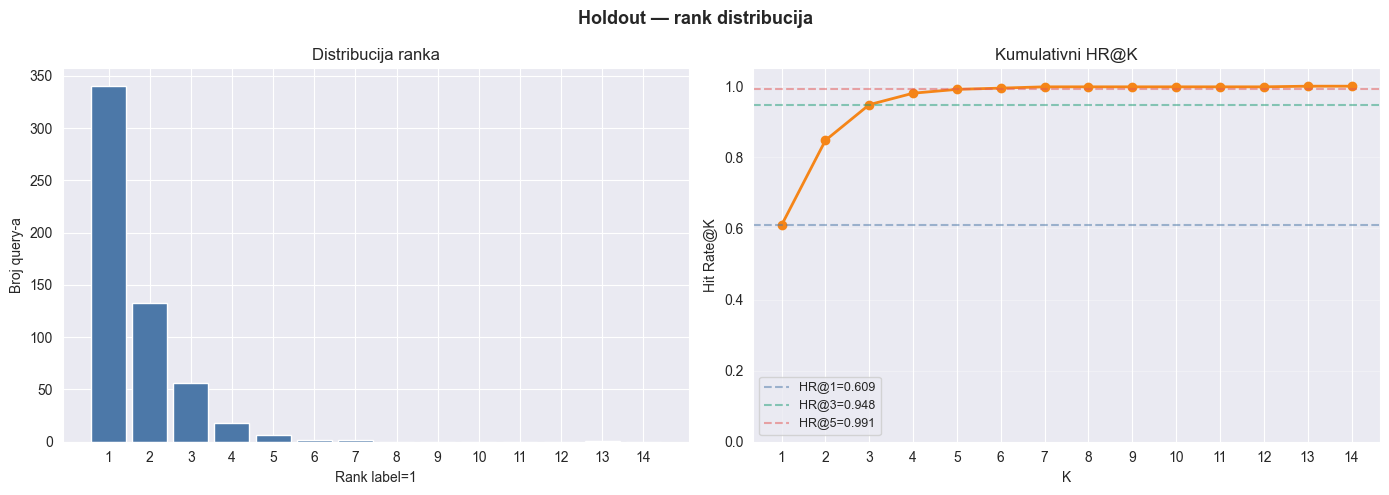

In [66]:
holdout_ranks = plot_rank_distribution(
    holdout_preds, 
    holdout_fd['y_val'], 
    holdout_fd['group_val'],
    title="Holdout — rank distribucija"
)

Skippovano (bez label=1): 0
is_predicted suma: 558
label suma:        600


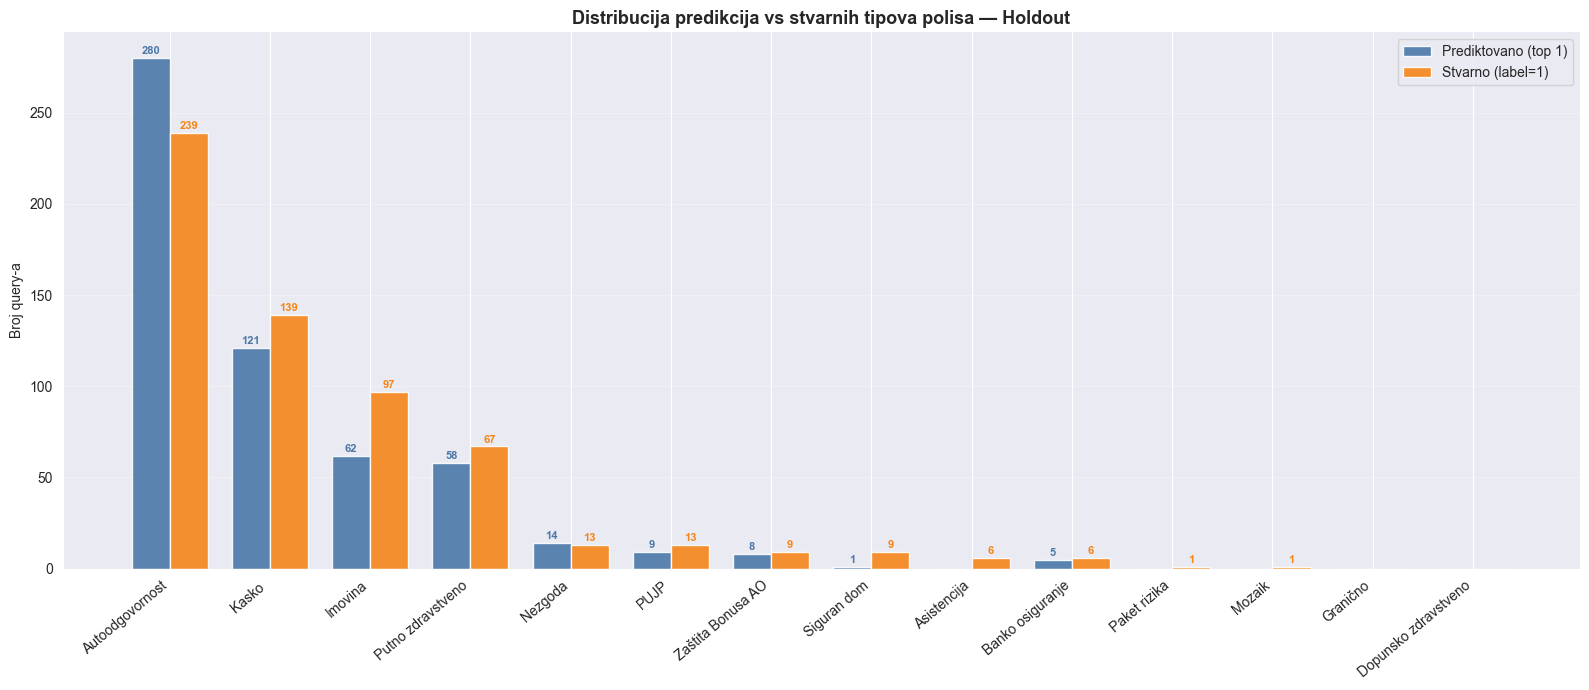

In [67]:
# ============================================================
# DISTRIBUCIJA PREDIKCIJA VS STVARNIH PO TIPU POLISE
# ============================================================

val_ds_predictions = holdout_fd['val_dataset'][['ponuda_id', 'candidate_type', 'label']].copy()
val_ds_predictions['model_predictions'] = holdout_preds
val_ds_predictions['is_predicted'] = 0

start = 0
skipped = 0
for g in holdout_fd['group_val']:
    end = start + g
    labels_slice = val_ds_predictions.iloc[start:end]['label'].values
    
    if labels_slice.sum() == 0:
        skipped += 1
        start = end
        continue
    
    top1_iloc = val_ds_predictions.iloc[start:end]['model_predictions'].values.argmax()
    val_ds_predictions.iloc[start + top1_iloc, val_ds_predictions.columns.get_loc('is_predicted')] = 1
    start = end

print(f"Skippovano (bez label=1): {skipped}")
print(f"is_predicted suma: {val_ds_predictions['is_predicted'].sum()}")  # sada 1575
print(f"label suma:        {val_ds_predictions['label'].sum()}")   

# Mapiranje sif_vrsta -> ime
policy_type_map = (
    policy_types[
        (policy_types['ind_polisa'] == 'D') &
        (policy_types['sif_vrsta'].isin(val_ds_predictions['candidate_type'].unique()))
    ]
    .set_index('sif_vrsta')['opis']
    .to_dict()
)

pred_label_dist = (
    val_ds_predictions
    .groupby('candidate_type')[['label', 'is_predicted']]
    .sum()
    .reset_index()
)
pred_label_dist['type'] = pred_label_dist['candidate_type'].map(policy_type_map).fillna(pred_label_dist['candidate_type'].astype(str))
pred_label_dist = pred_label_dist.sort_values('label', ascending=False)

# ============================================================
# PLOT — stacked bar
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(pred_label_dist))
width = 0.38

bars_pred   = ax.bar(x - width/2, pred_label_dist['is_predicted'], width,
                     label='Prediktovano (top 1)', color='#4C78A8', alpha=0.9)
bars_actual = ax.bar(x + width/2, pred_label_dist['label'],        width,
                     label='Stvarno (label=1)',    color='#F58518', alpha=0.9)

for bar in bars_pred:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=8, color='#4C78A8', fontweight='bold')

for bar in bars_actual:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=8, color='#F58518', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(pred_label_dist['type'], rotation=40, ha='right', fontsize=10)
ax.set_ylabel('Broj query-a')
ax.set_title('Distribucija predikcija vs stvarnih tipova polisa — Holdout', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

<h3>Apriori analiza</h3>

In [68]:
# Koliko redova ima nenulti apriori score
print(f"Nenulti apriori score: {(holdout_fd['val_dataset']['candidate_apriori_score'] > 0).sum()}")
print(f"Ukupno redova: {len(holdout_fd['val_dataset'])}")
print(f"Postotak nenultih: {(holdout_fd['val_dataset']['candidate_apriori_score'] > 0).mean():.3f}")

print(f"\nDistribucija apriori score-a:")
print(holdout_fd['val_dataset']['candidate_apriori_score'].describe())

print(f"\nKoliko unique vrijednosti:")
print(holdout_fd['val_dataset']['candidate_apriori_score'].nunique())

# Koliko klijenata ima ikakav apriori signal
has_signal = holdout_fd['val_dataset'].groupby('klijent_id')['candidate_apriori_score'].max()
print(f"\nKlijenata sa bar jednim nenultim score-om: {(has_signal > 0).sum()} od {len(has_signal)}")

Nenulti apriori score: 1089
Ukupno redova: 7812
Postotak nenultih: 0.139

Distribucija apriori score-a:
count    7812.000000
mean        1.755331
std         4.869405
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        28.738748
Name: candidate_apriori_score, dtype: float64

Koliko unique vrijednosti:
27

Klijenata sa bar jednim nenultim score-om: 139 od 223


<h3>Shap detekcija korisnih feature-a</h3>
<p>Pomaze da eventualno izbacim beskorisne feature i ubrzam trening</p>

In [69]:
# explainer = shap.TreeExplainer(lgbm_model)
# shap_values = explainer.shap_values(holdout_fd['X_val'])

# # global importance
# shap_importance = pd.DataFrame({
#     'feature': holdout_fd['X_val'].columns,
#     'importance': abs(shap_values).mean(axis=0)
# }).sort_values('importance', ascending=False)

# print(shap_importance.head(20))

In [70]:
# shap.summary_plot(shap_values, holdout_fd['X_val'], plot_type="bar")

In [71]:
# # Uzmi samo uzorak da ne traje 42 minute
# sample_size = 1000
# idx = np.random.choice(len(holdout_fd['X_val']), sample_size, replace=False)
# X_sample = holdout_fd['X_val'].iloc[idx]

# explainer   = shap.Explainer(xgb_model.predict, X_sample)
# shap_values = explainer(X_sample)

# shap_importance = pd.DataFrame({
#     'feature'   : holdout_fd['X_val'].columns,
#     'importance': np.abs(shap_values.values).mean(axis=0)
# }).sort_values('importance', ascending=False)

# print(shap_importance.head(20))

In [72]:
lgbm_model.feature_importances_

array([ 27,  40,  63,  53,  14,  11,  12,  10,   0,   0,   0,   0,   0,
         0,  83,  19,  31,  35,  49,  35,  40,  33,  73,   2,   0,   1,
         0,  15,  13,   3,   0,   2, 140,  26,  27, 138,  31,   0,   0,
         0,   2,   7,   5,   8,   0,   1,  27,   2,   0,   0,   0,   0,
         0,   1,   0,   0,   5,   7,  14,   6,  17,  18,  18,  15,  24],
      dtype=int32)

In [73]:
# shap.summary_plot(
#     shap_values,
#     holdout_fd['X_val'],
#     max_display=20
# )

In [74]:
ref_fold_spec = sorted(cv_folds, key=lambda f: len(f['train_idx']), reverse=True)[0]
ref_train     = df_sorted.loc[ref_fold_spec['train_idx']].copy()
ref_trimmed   = ref_train[
    ref_train.groupby(CLIENT_COL).cumcount(ascending=False) != 0
].copy()

print(f"Referentni fold: fold {ref_fold_spec['fold']} ({len(ref_trimmed):,} redova)")

cluster_input, _ = _build_cluster_input_data(ref_trimmed, fit_pca=None)
print(f"Shape: {cluster_input.shape}")
print(f"Kolone: {cluster_input.columns.tolist()}")
print(f"\nVarijansa po koloni (top 10):")
print(cluster_input.var().sort_values(ascending=False).head(10))
print(f"\nKorelacija između portfolio kolona:")
portfolio_cols = [c for c in cluster_input.columns if c.startswith('portfolio_')]
print(f"  Broj portfolio kolona: {len(portfolio_cols)}")
print(f"  Prosječna inter-korelacija: {cluster_input[portfolio_cols].corr().abs().mean().mean():.3f}")

Referentni fold: fold 6 (9,107 redova)
   Portfolio PCA: 14 → 5 komponenti (86.4% varijanse)
Shape: (3718, 18)
Kolone: ['portfolio_pc1', 'portfolio_pc2', 'portfolio_pc3', 'portfolio_pc4', 'portfolio_pc5', 'age', 'gender', 'is_foreign', 'osig_kanton_y', 'ownerType', 'merrige_status', 'total_policies', 'avg_premium', 'avg_ins_sum', 'total_detriments', 'has_debt', 'portfolio_diversity', 'years_active']

Varijansa po koloni (top 10):
avg_ins_sum            1000150399335.420776
avg_premium                   297565.343085
osig_kanton_y                   1784.005658
age                              594.243858
total_policies                   106.352971
merrige_status                     1.350719
portfolio_diversity                 0.28981
gender                             0.250065
total_detriments                   0.240652
portfolio_pc1                       0.23165
dtype: Float64

Korelacija između portfolio kolona:
  Broj portfolio kolona: 6
  Prosječna inter-korelacija: 0.186


In [75]:
val_ds_predictions

,ponuda_id,candidate_type,label,model_predictions,is_predicted
0,107741,6,0,0.012220,1
1,107741,1,1,0.012057,0
2,107741,8,0,0.011744,0
3,107741,5,0,0.011899,0
4,107741,22,0,0.011285,0
...,...,...,...,...,...
7807,129447,17,0,0.010488,0
7808,129447,23,0,0.010765,0
7809,129447,15,0,0.011304,0
7810,129447,4,0,0.010545,0


In [76]:
np_cli_data = pd.read_csv('../../data/new_polisa_klijent_202606051445.csv', dtype={
    'osig_jmbg': str, 'klijent_id': 'Int32', 'ponuda_id': 'Int32'
})

policy_data = pd.read_csv('../../data/new_polisa_202606051446.csv', dtype={
    'ponuda_id': 'Int32', 'ugo_jmbg': str
})

pol_cli_data = np_cli_data.merge(policy_data, on = "ponuda_id", how = "inner")

pol_cli_data = pol_cli_data.sort_values(['klijent_id', 'dat_izdavanja'])

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_24144\161354989.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  np_cli_data = pd.read_csv('../../data/new_polisa_klijent_202606051445.csv', dtype={
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_24144\161354989.py:5: DtypeWarning: Columns (61,65,80,82) have mixed types. Specify dtype option on import or set low_memory=False.
  policy_data = pd.read_csv('../../data/new_polisa_202606051446.csv', dtype={


In [77]:
policy_data['sif_vrsta'].unique()

array([ 0,  6,  1, 12,  5,  9,  7,  8, 11, 15, 13,  4, 17, 22, 23])

In [78]:
print("candidate_type unique u val_dataset:", 
      sorted(holdout_fd['val_dataset']['candidate_type'].unique()))
print("sif_vrsta unique u val_dataset:", 
      sorted(holdout_fd['val_dataset']['sif_vrsta'].unique()))

candidate_type unique u val_dataset: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(17), np.int64(22), np.int64(23)]
sif_vrsta unique u val_dataset: [np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(12), np.int64(13), np.int64(15), np.int64(22), np.int64(23)]


In [79]:
validation = holdout_fd['val_dataset']
X_val = holdout_fd['X_val']

In [80]:
random_idx = np.random.randint(0, len(validation))
random_row = validation.iloc[random_idx]

In [81]:
def predict(ponuda_id, klijent_id, sif_vrsta, holdout_fd, policy_type_map):
    
    val_sample = holdout_fd['val_dataset'][
        holdout_fd['val_dataset']['ponuda_id'] == ponuda_id
    ].copy()
    
    X_val_sample = holdout_fd['X_val'].loc[val_sample.index]
    
    n = len(val_sample)
    group = np.array([n])  # jedna grupa = cijeli val_sample

    w_lgbm, w_xgb, w_cat, w_markov, w_apriori, rrf_k, temperature = weights

    cat_scores = (
        cat_model.predict(X_val_sample)
        if USE_CATBOOST and cat_model is not None
        else np.zeros(n)
    )

    scores_dict = {
        'lgbm'    : lgbm_model.predict(X_val_sample),
        'xgb'     : xgb_model.predict(X_val_sample),
        'cat'     : cat_scores,
        'markov'  : val_sample['markov_prob'].values if BLEND_MARKOV_PROBS else np.zeros(n),
        'apriori' : val_sample['candidate_apriori_score'].values if BLEND_APRIORI else np.zeros(n),
    }
    weights_dict = {
        'lgbm'    : w_lgbm,
        'xgb'     : w_xgb,
        'cat'     : w_cat,
        'markov'  : w_markov,
        'apriori' : w_apriori,
    }

    blended = rrf_blend(scores_dict, group, weights_dict, k=rrf_k,
                        calibrate=True, temperature=temperature)

    val_sample['final_score'] = blended
    val_sample = val_sample.sort_values('final_score', ascending=False)
    val_sample['rank'] = np.arange(1, n + 1)

    result = val_sample[[
        'candidate_type', 'label', 'markov_prob',
        'segment_markov_prob', 'candidate_apriori_score',
        'final_score', 'rank'
    ]].copy()

    result['candidate_type'] = result['candidate_type'].map(
        lambda x: policy_type_map.get(x, str(x))
    )

    stvarna = val_sample[val_sample['label'] == 1]['candidate_type'].values
    print(f"Klijent:          {klijent_id}")
    print(f"Trenutna polisa:  tip {sif_vrsta}")
    print(f"Stvarna sljedeća: tip {stvarna}")
    print(f"Model predvidio:  tip {result.iloc[0]['candidate_type']} (rank 1)")
    print(f"Hit@1: {'✓' if result.iloc[0]['label'] == 1 else '✗'}")
    print("\nTop 5 preporuka:")
    print(result.head(5).to_string(index=False))

    return result

In [82]:
dat_izdavanja = pol_cli_data[pol_cli_data['ponuda_id'] == random_row['ponuda_id']]['dat_izdavanja']

pol_cli_data[pol_cli_data['ponuda_id'] == random_row['ponuda_id']]

,ponuda_id,redni_br,sif_uloga,osig_jmbg_x,osig_svojina_x,osig_naziv_x,osig_naziv1_x,osig_ulica_x,osig_kuc_br_x,osig_mesto_x,osig_posta_x,osig_kanton_x,osig_opstina_x,osig_mesto_id_x,osig_telefon1_x,osig_telefon2_x,osig_mail_x,klijent_id,king_id_x,drzava_id,br_pasosa,datum_rodjenja,pol_id,ind_info_ponuda,dat_vozacke,sif_delatnost,nedef_delatnost,sif_bracni_status,mesto_rodj,procenat,sif_mj,polisa_id,sif_vrsta,polisa_no,broker_id,sif_org_jed,zamena_polise_no,ind_zamena,sif_preuzmi,preuzmi_no,preuzmi_id,ugo_jmbg,ugo_svojina,ugo_naziv,ugo_naziv1,ugo_ulica,ugo_kuc_br,ugo_mesto,ugo_posta,ugo_kanton,ugo_opstina,ugo_mesto_id,ugo_telefon1,ugo_telefon2,ugo_mail,osig_jmbg_y,osig_svojina_y,osig_naziv_y,osig_naziv1_y,osig_ulica_y,osig_kuc_br_y,osig_mesto_y,osig_posta_y,osig_kanton_y,osig_opstina_y,osig_mesto_id_y,osig_telefon1_y,osig_telefon2_y,osig_mail_y,sif_trajanja,dat_od_ug,dat_do_ug,dat_od,dat_do,time_od,time_do,br_dana,mesto_izdavanja,dat_izdavanja,mjesto_izdavanja,napomena,napomena_auto,napomena1,p_oper,p_date,p_session_id,sif_nac_plac,br_rata,dat_prve_rate,sif_napomena,premija_ukupno,opis_osiguravac,ind_user_skadenca,ind_obracun,suma_osiguranja,polisa_tarifa,veza_polise_no,ind_lock_skadenca,miro_polisa_no,uw_indikator,ind_uw_kontrola,ugo_isprava,osig_isprava,sif_ikanton,sif_iopstina,ugo_del,king_id_y,sif_datum_dospeca,sif_bankovni_racun,ugo_br_pasosa,osig_br_pasosa,konacna_premija,ind_nepravilni_otp_plan,ind_dug,ind_steta,registarski_broj_polise,akcija_id
131921,113400,1,12,4600375230005,2,DMD COMPANY,NaN,UZUNOVICA,17,BRČKO DISTRIKT,76100.0,88.0,99.0,431.0,NaN,NaN,NaN,44344,744000.0,NaN,NaN,NaN,NaN,N,NaN,260.0,NaN,NaN,NaN,NaN,NaN,3598867,1,10117081,311,1670,0.0,N,NaN,NaN,0,4600375230005,2.0,DMD COMPANY,NaN,UZUNOVICA,17,BRČKO DISTRIKT,76100.0,88.0,99.0,431.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2026-03-19,2027-03-19,2026-03-19,2027-03-19,23:59,23:59,366.0,NaN,2026-03-19,NaN,NaN,NaN,NaN,9157,2026-03-19,NaN,0.0,0.0,NaN,NaN,20.7,NaN,N,NaN,2400000.0,10.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,2166186.0,0.0,1.0,NaN,NaN,0.0,NaN,N,N,5.600051e+11,NaN


In [83]:
dat_izdavanja = pol_cli_data[pol_cli_data['ponuda_id'] == random_row['ponuda_id']]['dat_izdavanja'].values[0]

klijent_polise = pol_cli_data[pol_cli_data['klijent_id'] == random_row['klijent_id']][
    ['ponuda_id', 'klijent_id', 'dat_izdavanja', 'sif_vrsta']
].sort_values('dat_izdavanja').reset_index(drop=True)

# Pronađi index reda sa tim datumom
target_pos = klijent_polise[klijent_polise['dat_izdavanja'] == dat_izdavanja].index[0]

# Uzmi 2 reda prije i 2 reda poslije
start = max(0, target_pos - 2)
end   = min(len(klijent_polise), target_pos + 3)

klijent_polise.iloc[start:end]

,ponuda_id,klijent_id,dat_izdavanja,sif_vrsta
12,101164,44344,2026-02-03,1
13,111593,44344,2026-03-13,1
14,113395,44344,2026-03-19,1
15,113384,44344,2026-03-19,1
16,113400,44344,2026-03-19,1


In [84]:
predict(random_row['ponuda_id'], random_row['klijent_id'], random_row['sif_vrsta'], holdout_fd, policy_type_map)

Klijent:          44344
Trenutna polisa:  tip 1
Stvarna sljedeća: tip [1]
Model predvidio:  tip Kasko  (rank 1)
Hit@1: ✗

Top 5 preporuka:
 candidate_type  label  markov_prob  segment_markov_prob  candidate_apriori_score  final_score  rank
         Kasko       0     0.138188                  0.0                 6.839520     0.012220     1
Autoodgovornost      1     0.700109                  0.0                11.903458     0.012057     2
        Nezgoda      0     0.021731                  0.0                 0.000000     0.011899     3
        Imovina      0     0.017989                  0.0                 0.000000     0.011744     4
    Asistencija      0     0.030868                  0.0                 0.000000     0.011593     5


,candidate_type,label,markov_prob,segment_markov_prob,candidate_apriori_score,final_score,rank
7308,Kasko,0,0.138188,0.0,6.839520,0.012220,1
7309,Autoodgovornost,1,0.700109,0.0,11.903458,0.012057,2
7311,Nezgoda,0,0.021731,0.0,0.000000,0.011899,3
7310,Imovina,0,0.017989,0.0,0.000000,0.011744,4
7312,Asistencija,0,0.030868,0.0,0.000000,0.011593,5
7316,Putno zdravstveno,0,0.039429,0.0,0.000000,0.011447,6
7317,Zaštita Bonusa AO,0,0.020164,0.0,0.000000,0.011250,7
7318,PUJP,0,0.004660,0.0,0.000000,0.011134,8
7315,Paket rizika,0,0.004226,0.0,0.000000,0.011060,9
7314,Siguran dom,0,0.014315,0.0,0.000000,0.010946,10


In [85]:
future_pairs_test = _build_future_pairs(
    pol_cli_data[pol_cli_data['klijent_id'] == 406]
)
print(future_pairs_test)

    ponuda_id  candidate_type  target_is_renewal  label
0         238               6                  1      1
1       11842               6                  1      1
2        7905               6                  0      1
3       33929               6                  1      1
5       34007               6                  1      1
7      125062               6                  1      1
9       34107               1                  0      1
10      62174               1                  1      1
11      95487               9                  0      1
12      91099               8                  0      1
13     112815               8                  1      1
17     112824               8                  1      1
21     112833               8                  1      1
25     112845               8                  1      1
29     112847               8                  1      1


In [86]:
future_pairs_full = _build_future_pairs(pol_cli_data)
label_dist = (
    future_pairs_full
    .groupby('ponuda_id')['label']
    .sum()
    .value_counts()
    .sort_index()
)
print("Distribucija label=1 po ponuda_id:")
print(label_dist)

Distribucija label=1 po ponuda_id:
label
1    72407
2    14779
3     1958
4      118
7        4
8        9
Name: count, dtype: int64


In [87]:
import inspect
print(inspect.getsource(evaluate_ranker_scores))

def evaluate_ranker_scores(scores, y, group):
    return {
        "hr1": hit_rate_at_k(scores, y, group, k=1),
        "hr3": hit_rate_at_k(scores, y, group, k=3),
        "hr5": hit_rate_at_k(scores, y, group, k=5),
        "mrr3": mrr_at_k(scores, y, group, k=3),
        "mrr5": mrr_at_k(scores, y, group, k=5),
        "ndcg3": ndcg_at_k(scores, y, group, k = 3),
        "ndcg5": ndcg_at_k(scores, y, group, k = 5)
    }



In [88]:
# Pronađi ponude sa više label=1
multi_label_ponude = (
    validation.groupby('ponuda_id')[['klijent_id', 'label']]
    .sum()
    .reset_index()
    .query('label >= 2')
    .sort_values('label', ascending=False)
)

print(f"Ponude sa 2+ labela: {len(multi_label_ponude)}")
print(multi_label_ponude.head(10))

# Uzmi prvu takvu ponudu
target_ponuda = multi_label_ponude.iloc[0]['ponuda_id']
print(f"\nUzimam ponuda_id: {target_ponuda}")

val_sample   = validation[validation['ponuda_id'] == target_ponuda].copy()
X_val_sample = X_val.loc[val_sample.index]

print(f"\nLabele po kandidatu:")
print(val_sample[['candidate_type', 'label', 'markov_prob', 'segment_markov_prob']].to_string(index=False))

Ponude sa 2+ labela: 40
     ponuda_id  klijent_id  label
312     115273        1708      3
366     117109        4032      3
0       101498        4032      2
27      101788        3444      2
33      101824         686      2
44      102185      114618      2
28      101790        3444      2
31      101808          56      2
88      108188        3402      2
57      106518         980      2

Uzimam ponuda_id: 115273

Labele po kandidatu:
 candidate_type  label  markov_prob  segment_markov_prob
              6      1     0.618066                  0.0
              1      1     0.253493                  0.0
              8      1     0.024710                  0.0
              5      0     0.028155                  0.0
             22      0     0.021358                  0.0
             12      0     0.001332                  0.0
              9      0     0.014138                  0.0
             13      0     0.003080                  0.0
              7      0     0.026867      

In [89]:
predict(115273, 1708, 3, holdout_fd, policy_type_map)

Klijent:          1708
Trenutna polisa:  tip 3
Stvarna sljedeća: tip [1 6 8]
Model predvidio:  tip Autoodgovornost (rank 1)
Hit@1: ✓

Top 5 preporuka:
   candidate_type  label  markov_prob  segment_markov_prob  candidate_apriori_score  final_score  rank
  Autoodgovornost      1     0.253493                  0.0                12.412377     0.012220     1
           Kasko       1     0.618066                  0.0                10.286291     0.012057     2
          Imovina      1     0.024710                  0.0                 0.000000     0.011899     3
          Nezgoda      0     0.028155                  0.0                19.606207     0.011744     4
Putno zdravstveno      0     0.026867                  0.0                 0.000000     0.011593     5


,candidate_type,label,markov_prob,segment_markov_prob,candidate_apriori_score,final_score,rank
1555,Autoodgovornost,1,0.253493,0.0,12.412377,0.012220,1
1554,Kasko,1,0.618066,0.0,10.286291,0.012057,2
1556,Imovina,1,0.024710,0.0,0.000000,0.011899,3
1557,Nezgoda,0,0.028155,0.0,19.606207,0.011744,4
1562,Putno zdravstveno,0,0.026867,0.0,0.000000,0.011593,5
1558,Asistencija,0,0.021358,0.0,0.000000,0.011392,6
1564,PUJP,0,0.002641,0.0,0.000000,0.011273,7
1560,Siguran dom,0,0.014138,0.0,0.000000,0.011146,8
1563,Zaštita Bonusa AO,0,0.004281,0.0,0.000000,0.010999,9
1561,Paket rizika,0,0.003080,0.0,0.000000,0.010866,10


In [90]:
# Popularity baseline — uvijek predloži top-3 najpopularnija tipa
top3_global = df['sif_vrsta'].value_counts().head(3).index.tolist()

hits = 0
for _, group in holdout_fd['val_dataset'].groupby('ponuda_id'):
    labels = group.set_index('candidate_type')['label']
    if any(t in labels.index and labels[t] == 1 for t in top3_global):
        hits += 1

baseline_hr3 = hits / holdout_fd['val_dataset']['ponuda_id'].nunique()
print(f"Popularity baseline HR@3: {baseline_hr3:.4f}")
print(f"Model HR@3:               {holdout_metrics['hr3']:.4f}")
print(f"Lift nad baselineom:      {holdout_metrics['hr3'] / baseline_hr3:.2f}x")

Popularity baseline HR@3: 0.7509
Model HR@3:               0.9480
Lift nad baselineom:      1.26x


In [91]:
policy_type_map

{22: 'Asistencija',
 17: 'Zaštita Bonusa AO',
 15: 'Banko osiguranje',
 13: 'Paket rizika',
 12: 'Dopunsko zdravstveno',
 7: 'Putno zdravstveno',
 6: 'Kasko ',
 5: 'Nezgoda',
 1: 'Autoodgovornost',
 23: 'PUJP',
 8: 'Imovina',
 4: 'Granično',
 9: 'Siguran dom',
 11: 'Mozaik'}

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Baseline calculation
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Baseline calculation and showup
    </p>
</div>

In [92]:
# ============================================================
# BASELINE USPOREDBA — Popularity, Random, Model
# ============================================================

def compute_popularity_baseline(train_dataset, val_dataset, y_val, group_val):
    pop_scores = train_dataset['sif_vrsta'].value_counts(normalize=True).to_dict()
    val_scores = val_dataset['candidate_type'].map(pop_scores).fillna(0).values
    metrics    = evaluate_ranker_scores(val_scores, y_val, group_val)  # ← fix
    return val_scores, metrics


def compute_random_baseline(y_val, group_val, n_runs=20, seed=42):
    """
    Random baseline: prosjek N random permutacija.
    """
    rng = np.random.default_rng(seed)
    all_metrics = []
    
    for _ in range(n_runs):
        scores = rng.random(len(y_val))
        all_metrics.append(evaluate_ranker_scores(scores, y_val, group_val))
    
    avg = {k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0]}
    return avg


def compute_renewal_baseline(val_dataset, group_val):
    """
    Renewal baseline: uvijek preporuči isti tip kao trenutna polisa.
    score = 1.0 za candidate_same_as_current, 0.0 za ostale.
    """
    scores = val_dataset['candidate_same_as_current'].values.astype(float)
    metrics = evaluate_ranker_scores(scores, holdout_fd['y_val'], group_val)
    return scores, metrics


# ============================================================
# IZRAČUNAJ SVE BASELINE-E
# ============================================================
print("Računam baseline-e na holdout setu...\n")

pop_scores, pop_metrics = compute_popularity_baseline(
    holdout_fd['train_dataset'], holdout_fd['val_dataset'],
    holdout_fd['y_val'],  # ← dodaj
    holdout_fd['group_val']
)

random_metrics                = compute_random_baseline(holdout_fd['y_val'], holdout_fd['group_val'])
renewal_scores, renewal_metrics = compute_renewal_baseline(holdout_fd['val_dataset'], holdout_fd['group_val'])

model_metrics = evaluate_ranker_scores(holdout_preds, holdout_fd['y_val'], holdout_fd['group_val'])

# ============================================================
# TABELA USPOREDBE
# ============================================================
comparison = pd.DataFrame({
    'Baseline': ['Random', 'Popularity', 'Always renew', 'Model (V11)'],
    'HR@1':     [random_metrics['hr1'],   pop_metrics['hr1'],     renewal_metrics['hr1'],  model_metrics['hr1']],
    'HR@3':     [random_metrics['hr3'],   pop_metrics['hr3'],     renewal_metrics['hr3'],  model_metrics['hr3']],
    'HR@5':     [random_metrics['hr5'],   pop_metrics['hr5'],     renewal_metrics['hr5'],  model_metrics['hr5']],
    'MRR@3':    [random_metrics['mrr3'],  pop_metrics['mrr3'],    renewal_metrics['mrr3'], model_metrics['mrr3']],
    'NDCG@3':   [random_metrics['ndcg3'], pop_metrics['ndcg3'],   renewal_metrics['ndcg3'],model_metrics['ndcg3']],
})

comparison_pct = comparison.copy()
for col in ['HR@1', 'HR@3', 'HR@5', 'MRR@3', 'NDCG@3']:
    comparison_pct[col] = comparison_pct[col].apply(lambda x: f"{x:.1%}")

print("=" * 65)
print("HOLDOUT — USPOREDBA S BASELINE-IMA")
print("=" * 65)
print(comparison_pct.to_string(index=False))
print("=" * 65)

# Lift nad popularity baselineom
print("\nLift modela nad popularity baseline-om:")
for col in ['HR@1', 'HR@3', 'HR@5', 'NDCG@3']:
    key = col.lower().replace('@', '')
    lift = model_metrics[key] / pop_metrics[key] if pop_metrics[key] > 0 else float('inf')
    print(f"  {col}: {lift:.2f}x  ({pop_metrics[key]:.1%} → {model_metrics[key]:.1%})")

# Lift nad renewal baselineom (često najjači competitor)
print("\nLift modela nad renewal baseline-om:")
for col in ['HR@1', 'HR@3', 'HR@5', 'NDCG@3']:
    key = col.lower().replace('@', '')
    lift = model_metrics[key] / renewal_metrics[key] if renewal_metrics[key] > 0 else float('inf')
    print(f"  {col}: {lift:.2f}x  ({renewal_metrics[key]:.1%} → {model_metrics[key]:.1%})")

Računam baseline-e na holdout setu...

HOLDOUT — USPOREDBA S BASELINE-IMA
    Baseline  HR@1  HR@3  HR@5 MRR@3 NDCG@3
      Random  7.5% 22.2% 37.4% 13.6%  15.1%
  Popularity 24.9% 75.1% 93.9% 48.1%  54.3%
Always renew 69.0% 90.1% 95.5% 78.6%  80.7%
 Model (V11) 60.9% 94.8% 99.1% 76.2%  80.6%

Lift modela nad popularity baseline-om:
  HR@1: 2.45x  (24.9% → 60.9%)
  HR@3: 1.26x  (75.1% → 94.8%)
  HR@5: 1.06x  (93.9% → 99.1%)
  NDCG@3: 1.48x  (54.3% → 80.6%)

Lift modela nad renewal baseline-om:
  HR@1: 0.88x  (69.0% → 60.9%)
  HR@3: 1.05x  (90.1% → 94.8%)
  HR@5: 1.04x  (95.5% → 99.1%)
  NDCG@3: 1.00x  (80.7% → 80.6%)


<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Stakeholder Visualization
</h2>

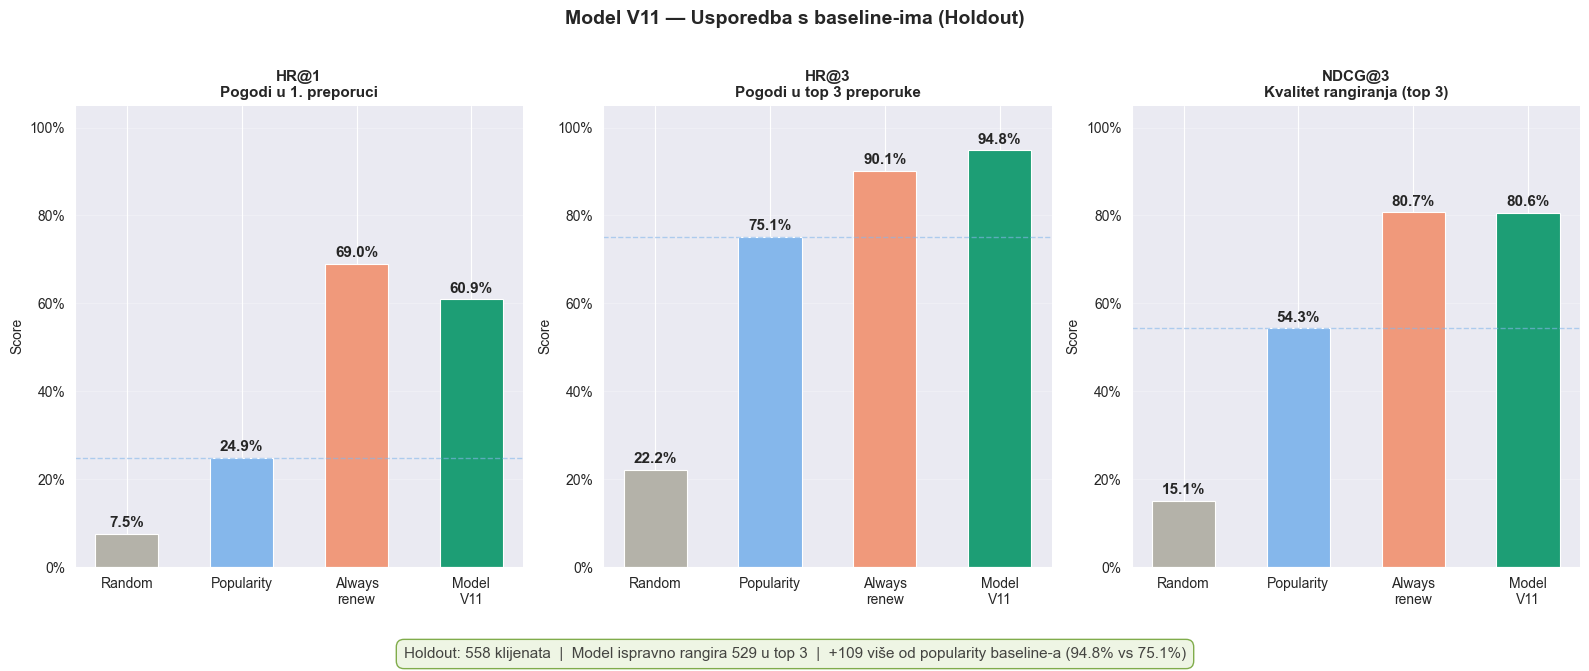


✅ Graf sačuvan kao baseline_comparison.png


In [93]:
# ============================================================
# VIZUALIZACIJA BASELINE USPOREDBE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Model V11 — Usporedba s baseline-ima (Holdout)', 
             fontsize=14, fontweight='bold', y=1.02)

metrics_to_plot = [
    ('HR@1',   'hr1',   'Pogodi u 1. preporuci'),
    ('HR@3',   'hr3',   'Pogodi u top 3 preporuke'),
    ('NDCG@3', 'ndcg3', 'Kvalitet rangiranja (top 3)'),
]

labels     = ['Random', 'Popularity', 'Always\nrenew', 'Model\nV11']
all_metric = [random_metrics, pop_metrics, renewal_metrics, model_metrics]
colors     = ['#B4B2A9', '#85B7EB', '#F0997B', '#1D9E75']

for ax, (title, key, subtitle) in zip(axes, metrics_to_plot):
    values = [m[key] for m in all_metric]
    bars   = ax.bar(labels, values, color=colors, width=0.55, edgecolor='white', linewidth=0.8)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Linija popularity baseline za referencu
    ax.axhline(pop_metrics[key], color='#85B7EB', linestyle='--', linewidth=1, alpha=0.6)
    
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{title}\n{subtitle}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

# Business interpretacija ispod grafa
n_holdout_groups = len(holdout_fd['group_val'])
hr3_model  = model_metrics['hr3']
hr3_pop    = pop_metrics['hr3']
extra_hits = int((hr3_model - hr3_pop) * n_holdout_groups)

fig.text(0.5, -0.06, 
    f"Holdout: {n_holdout_groups:,} klijenata  |  "
    f"Model ispravno rangira {int(hr3_model * n_holdout_groups):,} u top 3  |  "
    f"+{extra_hits:,} više od popularity baseline-a ({hr3_model:.1%} vs {hr3_pop:.1%})",
    ha='center', fontsize=11, color='#444441',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#EAF3DE', edgecolor='#639922', alpha=0.8)
)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graf sačuvan kao baseline_comparison.png")

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Business framing
</h2>

In [94]:
# ============================================================
# BUSINESS INTERPRETACIJA — za prezentaciju
# ============================================================
n_clients    = len(holdout_fd['group_val'])
hr1_m, hr3_m = model_metrics['hr1'], model_metrics['hr3']
hr1_p, hr3_p = pop_metrics['hr1'],   pop_metrics['hr3']

print("=" * 65)
print("BUSINESS INTERPRETACIJA — HOLDOUT REZULTATI")
print("=" * 65)
print(f"""
Testirano na {n_clients:,} klijenata koji NISU viđeni tokom treniranja.

📌 Scenario: Agent nudi top 3 preporuke za polisu.

   BEZ modela (popularity):
   → Tačna preporuka u top 3: {hr3_p:.0%} klijenata

   SA modelom (V11):
   → Tačna preporuka u top 3: {hr3_m:.0%} klijenata
   → Poboljšanje: +{(hr3_m - hr3_p):.0%} pp  ({hr3_m/hr3_p:.2f}x lift)

📌 Konkretno: od 100 klijenata kojima agent ponudi top 3,
   model ispravno identificira pravu sljedeću polisu za
   {hr3_m*100:.0f} od njih — umjesto {hr3_p*100:.0f} bez modela.

📌 Direktna preporuka (top 1):
   Model: {hr1_m:.0%} vs Popularity: {hr1_p:.0%}
   → Prostor za poboljšanje HR@1 postoji i planiran je.

📌 Cross-validation konzistentnost:
   Model je testiran na {len(fold_cache)} vremenskih perioda —
   HR@3 stabilan bez velikih oscilacija po foldovima.
""")
print("=" * 65)

BUSINESS INTERPRETACIJA — HOLDOUT REZULTATI

Testirano na 558 klijenata koji NISU viđeni tokom treniranja.

📌 Scenario: Agent nudi top 3 preporuke za polisu.

   BEZ modela (popularity):
   → Tačna preporuka u top 3: 75% klijenata

   SA modelom (V11):
   → Tačna preporuka u top 3: 95% klijenata
   → Poboljšanje: +20% pp  (1.26x lift)

📌 Konkretno: od 100 klijenata kojima agent ponudi top 3,
   model ispravno identificira pravu sljedeću polisu za
   95 od njih — umjesto 75 bez modela.

📌 Direktna preporuka (top 1):
   Model: 61% vs Popularity: 25%
   → Prostor za poboljšanje HR@1 postoji i planiran je.

📌 Cross-validation konzistentnost:
   Model je testiran na 6 vremenskih perioda —
   HR@3 stabilan bez velikih oscilacija po foldovima.



In [95]:
val = holdout_fd['val_dataset'].copy()
val['pred'] = holdout_preds

group_labels = (
    val[val['label'] == 1]
    .groupby('ponuda_id')['candidate_same_as_current']
    .max()
)
renewal_ponude     = group_labels[group_labels == 1].index
non_renewal_ponude = group_labels[group_labels == 0].index

# Cross-sell metrics
nr_val   = val[val['ponuda_id'].isin(non_renewal_ponude)].copy()
nr_group = get_query_group(nr_val)
cs_m     = evaluate_ranker_scores(
    nr_val['pred'].values, nr_val['label'].values, nr_group
)

# Renewal metrics
r_val   = val[val['ponuda_id'].isin(renewal_ponude)].copy()
r_group = get_query_group(r_val)
r_m     = evaluate_ranker_scores(
    r_val['pred'].values, r_val['label'].values, r_group
)

print(f"RENEWAL segment ({len(renewal_ponude):,} klijenata):")
print(f"  HR@1: {r_m['hr1']:.1%}  HR@3: {r_m['hr3']:.1%}  NDCG@3: {r_m['ndcg3']:.1%}")

print(f"\nCROSS-SELL segment ({len(non_renewal_ponude):,} klijenata):")
print(f"  HR@1: {cs_m['hr1']:.1%}  HR@3: {cs_m['hr3']:.1%}  NDCG@3: {cs_m['ndcg3']:.1%}")

RENEWAL segment (385 klijenata):
  HR@1: 61.0%  HR@3: 97.9%  NDCG@3: 82.5%

CROSS-SELL segment (173 klijenata):
  HR@1: 60.7%  HR@3: 87.9%  NDCG@3: 76.4%


In [96]:
val = holdout_fd['val_dataset'].copy()
val['pred'] = holdout_preds

# Za svaku grupu (ponuda_id), provjeri da li je label=1 renewal ili cross-sell
group_labels = (
    val[val['label'] == 1]
    .groupby('ponuda_id')['candidate_same_as_current']
    .max()  # 1 = renewal, 0 = cross-sell
)

renewal_ponude    = group_labels[group_labels == 1].index
non_renewal_ponude = group_labels[group_labels == 0].index

print(f"Renewal grupe   : {len(renewal_ponude):,}")
print(f"Cross-sell grupe: {len(non_renewal_ponude):,}")
print(f"Udio obnova     : {len(renewal_ponude) / (len(renewal_ponude) + len(non_renewal_ponude)):.1%}")

# HR@1 za renewal grupe
r_val    = val[val['ponuda_id'].isin(renewal_ponude)].copy()
r_group  = get_query_group(r_val)
renewal_hr1 = hit_rate_at_k(r_val['pred'].values, r_val['label'].values, r_group, k=1)

# HR@1 za cross-sell grupe
nr_val   = val[val['ponuda_id'].isin(non_renewal_ponude)].copy()
nr_group = get_query_group(nr_val)
non_renewal_hr1 = hit_rate_at_k(nr_val['pred'].values, nr_val['label'].values, nr_group, k=1)

print(f"\nHR@1 — renewal grupe  : {renewal_hr1:.1%}")
print(f"HR@1 — cross-sell grupe: {non_renewal_hr1:.1%}")

Renewal grupe   : 385
Cross-sell grupe: 173
Udio obnova     : 69.0%

HR@1 — renewal grupe  : 61.0%
HR@1 — cross-sell grupe: 60.7%


In [97]:
val_ds = holdout_fd['val_dataset']
train_ds = holdout_fd['train_dataset']

# val_df je subset train_dataset-a — trebamo sif_vrsta i ponuda_id
# Uzmi unique ponuda_id -> sif_vrsta mapping iz val_dataset
val_query = val_ds[['klijent_id', 'ponuda_id', 'sif_vrsta']].drop_duplicates('ponuda_id')

# type_ kolone iz val_dataseta — ovo je ono što je ušlo u model
type_cols = [c for c in val_ds.columns if c.startswith('type_')]

val_hist = val_ds[['ponuda_id'] + type_cols].drop_duplicates('ponuda_id')

diag = val_query.merge(val_hist, on='ponuda_id', how='left')

def get_hist_count(row):
    col = f"type_{int(row['sif_vrsta'])}"
    return row[col] if col in row.index else 0

diag['hist_count_for_current_type'] = diag.apply(get_hist_count, axis=1)

print("=== LEAKAGE DIAGNOSTIC ===")
print(f"Val query redova: {len(diag)}")
print(f"hist_count > 0 za trenutni tip: {(diag['hist_count_for_current_type'] > 0).sum()} ({(diag['hist_count_for_current_type'] > 0).mean():.1%})")

# Koliko je tih klijenata stvarno imalo taj tip u train periodu?
train_type_counts = (
    train_ds[['klijent_id', 'sif_vrsta']]
    .drop_duplicates()
    .assign(in_train=1)
)
diag2 = diag.merge(train_type_counts, on=['klijent_id', 'sif_vrsta'], how='left')
diag2['in_train'] = diag2['in_train'].fillna(0)

print(f"Tip stvarno postoji u train_ds:   {(diag2['in_train'] > 0).sum()}")
print(f"hist_count > 0 ali NIJE u trainu: {((diag2['hist_count_for_current_type'] > 0) & (diag2['in_train'] == 0)).sum()}")
print("=== END ===")

=== LEAKAGE DIAGNOSTIC ===
Val query redova: 558
hist_count > 0 za trenutni tip: 429 (76.9%)
Tip stvarno postoji u train_ds:   404
hist_count > 0 ali NIJE u trainu: 25
=== END ===


In [98]:
# Always renew baseline na holdout val setu — koliko query-a ima candidate_same_as_current=1?
renewal_possible = (
    holdout_fd['val_dataset']
    .groupby('ponuda_id')['candidate_same_as_current']
    .max()
    .sum()
)
print(f"Query-a gdje renewal kandidat postoji: {renewal_possible} / {holdout_fd['val_dataset']['ponuda_id'].nunique()}")

# HR@1 ako uvijek biramo candidate_same_as_current=1
def always_renew_hr1(val_ds):
    hits = 0
    total = 0
    for pid, grp in val_ds.groupby('ponuda_id'):
        renewal_rows = grp[grp['candidate_same_as_current'] == 1]
        if len(renewal_rows) == 0:
            continue
        total += 1
        if renewal_rows['label'].max() == 1:
            hits += 1
    return hits / total if total > 0 else 0

print(f"Always-renew HR@1: {always_renew_hr1(holdout_fd['val_dataset']):.1%}")

Query-a gdje renewal kandidat postoji: 558 / 558
Always-renew HR@1: 69.0%


In [99]:
val_ds = holdout_fd['val_dataset']

# Renewal grupe = grupe gdje label=1 AND candidate_same_as_current=1
renewal_pids = (
    val_ds[(val_ds['label'] == 1) & (val_ds['candidate_same_as_current'] == 1)]
    ['ponuda_id'].unique()
)

cs_pids = (
    val_ds[(val_ds['label'] == 1) & (val_ds['candidate_same_as_current'] == 0)]
    ['ponuda_id'].unique()
)

renewal_ds = val_ds[val_ds['ponuda_id'].isin(renewal_pids)]
cs_ds = val_ds[val_ds['ponuda_id'].isin(cs_pids)]

print(f"Renewal grupe: {len(renewal_pids)}")
print(f"Cross-sell grupe: {len(cs_pids)}")

# Koliko kandidata ima prosječna renewal grupa?
print(f"\nRenewal — prosječan broj kandidata: {renewal_ds.groupby('ponuda_id').size().mean():.1f}")
print(f"Cross-sell — prosječan broj kandidata: {cs_ds.groupby('ponuda_id').size().mean():.1f}")

# Ključno — had_type_before distribucija za label=1 redove
r_labels = renewal_ds[renewal_ds['label'] == 1]
print(f"\nRenewal label=1 redovi: {len(r_labels)}")
print(f"had_type_before=1: {(r_labels['had_type_before'] == 1).sum()} ({(r_labels['had_type_before'] == 1).mean():.1%})")
print(f"candidate_same_as_current=1: {(r_labels['candidate_same_as_current'] == 1).sum()} ({(r_labels['candidate_same_as_current'] == 1).mean():.1%})")
print(f"likely_annual_renewal srednja: {r_labels['likely_annual_renewal'].mean():.3f}")

Renewal grupe: 385
Cross-sell grupe: 205

Renewal — prosječan broj kandidata: 14.0
Cross-sell — prosječan broj kandidata: 14.0

Renewal label=1 redovi: 419
had_type_before=1: 334 (79.7%)
candidate_same_as_current=1: 385 (91.9%)
likely_annual_renewal srednja: 0.036


In [100]:
nr_val   = val[val['ponuda_id'].isin(non_renewal_ponude)].copy()
nr_group = get_query_group(nr_val)

cs_metrics = evaluate_ranker_scores(
    nr_val['pred'].values, nr_val['label'].values, nr_group
)

print("CROSS-SELL SEGMENT — HOLDOUT")
print(f"HR@1  : {cs_metrics['hr1']:.1%}")
print(f"HR@3  : {cs_metrics['hr3']:.1%}")
print(f"HR@5  : {cs_metrics['hr5']:.1%}")
print(f"NDCG@3: {cs_metrics['ndcg3']:.1%}")
print(f"\nBroj klijenata: {len(non_renewal_ponude):,}")

CROSS-SELL SEGMENT — HOLDOUT
HR@1  : 60.7%
HR@3  : 87.9%
HR@5  : 97.1%
NDCG@3: 76.4%

Broj klijenata: 173


In [101]:
# Na kojoj poziciji se nalazi tačan cross-sell kandidat?
cs_ranks = []
start = 0

for g in nr_group:
    end    = start + g
    preds  = nr_val['pred'].values[start:end]
    labels = nr_val['label'].values[start:end]
    
    sorted_idx = np.argsort(-preds)
    for rank, idx in enumerate(sorted_idx, 1):
        if labels[idx] == 1:
            cs_ranks.append(rank)
            break
    start = end

cs_ranks = np.array(cs_ranks)

print("Cross-sell — gdje se nalazi tačan kandidat:")
print(f"  Rank 1: {(cs_ranks == 1).mean():.1%} ({(cs_ranks == 1).sum()} klijenata)")
print(f"  Rank 2: {(cs_ranks == 2).mean():.1%}")
print(f"  Rank 3: {(cs_ranks == 3).mean():.1%}")
print(f"  Rank 4: {(cs_ranks == 4).mean():.1%}")
print(f"  Rank 5: {(cs_ranks == 5).mean():.1%}")
print(f"  Rank >5: {(cs_ranks > 5).mean():.1%}")
print(f"\n  Median rank: {np.median(cs_ranks):.1f}")
print(f"  Mean rank  : {np.mean(cs_ranks):.2f}")

# Koji tipovi se najčešće propuštaju na rank 1?
nr_val_copy = nr_val.copy()
nr_val_copy['pred_rank'] = 0

start = 0
for g in nr_group:
    end = start + g
    ranks = np.argsort(-nr_val_copy['pred'].values[start:end])
    nr_val_copy.iloc[start:end, nr_val_copy.columns.get_loc('pred_rank')] = \
        np.argsort(ranks) + 1
    start = end

missed = nr_val_copy[
    (nr_val_copy['label'] == 1) & (nr_val_copy['pred_rank'] > 1)
]
print("\nNajčešće propušteni cross-sell tipovi (nisu na rank 1):")
print(
    missed['candidate_type']
    .map(lambda x: f"{x} — {policy_type_map.get(x, str(x))}")
    .value_counts()
    .head(8)
    .to_string()
)

print("\nŠta model stavlja na rank 1 umjesto tačnog cross-sell tipa:")
wrong_top1 = nr_val_copy[
    (nr_val_copy['pred_rank'] == 1) & (nr_val_copy['label'] == 0)
]
print(
    wrong_top1['candidate_type']
    .map(lambda x: f"{x} — {policy_type_map.get(x, str(x))}")
    .value_counts()
    .head(8)
    .to_string()
)

Cross-sell — gdje se nalazi tačan kandidat:
  Rank 1: 60.7% (105 klijenata)
  Rank 2: 17.9%
  Rank 3: 9.2%
  Rank 4: 5.8%
  Rank 5: 3.5%
  Rank >5: 2.9%

  Median rank: 1.0
  Mean rank  : 1.87

Najčešće propušteni cross-sell tipovi (nisu na rank 1):
candidate_type
8 — Imovina               23
6 — Kasko                 19
5 — Nezgoda                9
7 — Putno zdravstveno      8
22 — Asistencija           6
1 — Autoodgovornost        3
23 — PUJP                  3
17 — Zaštita Bonusa AO     2

Šta model stavlja na rank 1 umjesto tačnog cross-sell tipa:
candidate_type
1 — Autoodgovornost       37
6 — Kasko                 15
7 — Putno zdravstveno      7
8 — Imovina                6
17 — Zaštita Bonusa AO     2
5 — Nezgoda                1


<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Prediction Pipeline
</h2>

In [102]:
# ============================================================
# PRODUCTION PREDICT — prima live klijenta, vraća top-N
# ============================================================

def predict_for_client(klijent_id, top_n=5, verbose=True):
    """
    Production-ready predikcija za jednog klijenta.
    
    Radi na live podacima iz pol_cli_data (ne iz holdout_fd).
    Gradi feature set online, vraća DataFrame s top-N preporukama.
    
    Parameters
    ----------
    klijent_id : int
        ID klijenta iz baze.
    top_n : int
        Broj preporuka koje se vraćaju.
    verbose : bool
        Ako True, ispisuje detalje za demo.
        
    Returns
    -------
    pd.DataFrame s kolonama: rank, policy_type, policy_name,
                              score, confidence, reason
    """
    
    # ── 1. Provjeri da klijent postoji ──────────────────────
    client_history = pol_cli_data[pol_cli_data['klijent_id'] == klijent_id].copy()
    
    if len(client_history) == 0:
        print(f"❌ Klijent {klijent_id} nije pronađen u bazi.")
        return None
    
    if len(client_history) < 2:
        print(f"⚠️  Klijent {klijent_id} ima samo 1 polisu — nedovoljno historije za predikciju.")
        return None
    
    client_history = client_history.sort_values('dat_izdavanja').reset_index(drop=True)
    
    # ── 2. Uzmi zadnju polisu kao "trenutnu" ────────────────
    current_policy  = client_history.iloc[-1]
    history_so_far  = client_history.iloc[:-1]
    
    current_type    = current_policy['sif_vrsta']
    current_date = pd.to_datetime(current_policy['dat_izdavanja'])

    
    # ── 3. Kandidati — svi poznati tipovi polisa ────────────
    all_candidate_types = sorted(pol_cli_data['sif_vrsta'].unique())
    
    # ── 4. Gradi feature red za svakog kandidata ────────────
    rows = []
    
    client_types_so_far = set(history_so_far['sif_vrsta'].tolist())
    n_policies_before   = len(history_so_far)
    portfolio_diversity = len(client_types_so_far)
    
    # Premium statistike
    avg_premium_past = (
        history_so_far['premija_ukupno'].tail(3).mean()
        if len(history_so_far) > 0 else 0.0
    )
    avg_premium_now = client_history['premija_ukupno'].tail(3).mean()
    
    avg_ins_sum_past = (
        history_so_far['suma_osiguranja'].tail(3).mean()
        if len(history_so_far) > 0 else 0.0
    )
    avg_ins_sum_now = client_history['suma_osiguranja'].tail(3).mean()
    
    days_since_last = (
        (current_date - pd.to_datetime(history_so_far.iloc[-1]['dat_izdavanja'])).days
        if len(history_so_far) > 0 else 0
    )
    
    crosssell_ratio = portfolio_diversity / (n_policies_before + 1)
    
    # Markov lookup (iz holdout_fd koji je zadnji buildan fold)
    markov_transitions = _build_markov_with_decay(
        df_sorted[df_sorted['dat_izdavanja'] < current_date]
    )
    mt_dict_live = markov_transitions.set_index(['from_type', 'to_type'])['prob'].to_dict()
    
    # Popularity (iz cijelog trening perioda)
    global_pop_live = (
        df_sorted[df_sorted['dat_izdavanja'] < current_date]['sif_vrsta']
        .value_counts(normalize=True)
        .to_dict()
    )
    
    # SVD embeddings (iz zadnjeg builtanog folda — holdout)
    # Rebuildi embedding_map iz cijelog df_sorted (ili samo train dijela)
    embedding_map, emb_svd, emb_type_idx = build_policy_type_embeddings(
        df_sorted[df_sorted['dat_izdavanja'] < current_date],
        n_components=EMB_COMPONENTS
    )
    emb_map = embedding_map

    print(f"Embedding map kreiran: {len(embedding_map)} tipova")
    print(f"Embedding map kreiran: {len(embedding_map)} tipova, dim={EMB_COMPONENTS}")
    
    for ctype in all_candidate_types:
        
        cnt_type_before  = history_so_far['sif_vrsta'].tolist().count(ctype)
        had_type_before  = int(cnt_type_before > 0)
        
        # Days since candidate type
        past_same = history_so_far[history_so_far['sif_vrsta'] == ctype]
        if len(past_same) > 0:
            days_since_ctype = (current_date - pd.Timestamp(past_same.iloc[-1]['dat_izdavanja'])).days
            candidate_never_had = 0
        else:
            days_since_ctype    = 0
            candidate_never_had = 1
        
        markov_prob      = mt_dict_live.get((current_type, ctype), 0.0)
        global_pop_score = global_pop_live.get(ctype, 0.0)
        same_as_current  = int(ctype == current_type)

        same_type_hist = client_history[client_history['sif_vrsta'] == ctype].copy()
        if len(same_type_hist) >= 2:
            last_gap = (
                pd.to_datetime(same_type_hist['dat_izdavanja'])
                .diff().dt.days.dropna().iloc[-1]
            )

            likely_annual = int(330 <= last_gap <= 400)
            likely_semi   = int(150 <= last_gap <= 200)
            days_since_same_type = int(last_gap)
            dsst_missing  = 0
        else:
            likely_annual        = 0
            likely_semi          = 0
            days_since_same_type = 9999
            dsst_missing         = 1
        
        # Seasonal
        month     = current_date.month
        quarter   = current_date.quarter
        month_sin = np.sin(2 * np.pi * month / 12)
        month_cos = np.cos(2 * np.pi * month / 12)
        
        # Embeddings
        zero_vec = np.zeros(EMB_COMPONENTS)
        emb_vec  = emb_map.get(ctype, zero_vec)
        
        def safe_int(val, default=0):
            try:
                if pd.isna(val):
                    return default
                return int(float(val))
            except (ValueError, TypeError):
                return default
        
        row = {
            'candidate_type':               ctype,
            'n_policies_before':            n_policies_before,
            'had_type_before':              had_type_before,
            'cnt_type_before':              cnt_type_before,
            'days_since_last_policy':       days_since_last,
            'portfolio_diversity_before':   portfolio_diversity,
            'crosssell_ratio':              crosssell_ratio,
            'days_since_candidate_type':    days_since_ctype,
            'candidate_never_had':          candidate_never_had,
            'candidate_same_as_current':    same_as_current,
            'markov_prob':                  markov_prob,
            'segment_markov_prob':          0.0,
            'candidate_global_pop':         global_pop_score,
            'candidate_regional_pop':       global_pop_score,
            'likely_annual_renewal':        likely_annual,
            'likely_semi_renewal':          likely_semi,
            'days_since_same_type':         days_since_same_type,
            'days_since_same_type_missing': dsst_missing,
            'month':                        month,
            'quarter':                      quarter,
            'month_sin':                    month_sin,
            'month_cos':                    month_cos,
            'ind_dug':                      safe_int(current_policy.get('ind_dug',    0)),
            'ind_steta':                    safe_int(current_policy.get('ind_steta',  0)),
            'uw_indikator':                 safe_int(current_policy.get('uw_indikator', 0)),
            'has_prev_policy':              safe_int(current_policy.get('has_prev_policy', 1), default=1),
            'avg_premium_past':             avg_premium_past,
            'avg_insurance_sum_past':       avg_ins_sum_past,
            'avg_premium_since_now':        avg_premium_now,
            'avg_insurance_sum_since_now':  avg_ins_sum_now,
            'age':                          safe_int(current_policy.get('age',          0)),
            'gender':                       safe_int(current_policy.get('gender',       0)),
            'ownerType':                    safe_int(current_policy.get('ownerType',    1), default=1),
            'merrige_status':               safe_int(current_policy.get('merrige_status', 0)),
            'is_foreign':                   safe_int(current_policy.get('is_foreign',   0)),
            'birth_place':                  safe_int(current_policy.get('birth_place',  0)),
            'osig_opstina_y':               safe_int(current_policy.get('osig_opstina_y', 0)),
            'osig_kanton_y':                safe_int(current_policy.get('osig_kanton_y',  0)),
            'sif_uloga':                    safe_int(current_policy.get('sif_uloga',    1), default=1),
            'age_bucket':                   safe_int(current_policy.get('age_bucket',   2), default=2),
            'client_cluster':               -1,
            'candidate_apriori_score':      0.0,
        }
        
        # Dodaj embeddings
        for i, v in enumerate(emb_vec):
            row[f'cand_emb_{i}'] = v
        
        rows.append(row)
    
    # ── 5. Napravi DataFrame i align s training featurima ───
    X_live = pd.DataFrame(rows)
    
    # Uzmi feature listu iz zadnjeg foldai provjeri da sve postoji
    live_features = holdout_fd['features']
    
    # Dodaj history type kolone kao 0 ako nedostaju
    for col in live_features:
        if col not in X_live.columns:
            X_live[col] = 0
    
    X_live = X_live[live_features].copy()
    
    # Align categorical encoding s training setom
    ref_X = holdout_fd['X_val']
    for col in CATEGORICAL_FEATURES:
        if col not in X_live.columns or col not in ref_X.columns:
            continue
        train_cats = ref_X[col].astype('category').cat.categories
        X_live[col] = pd.Categorical(
            X_live[col].astype('object'), categories=train_cats
        ).codes
    
    # ── 6. Predikcija ───────────────────────────────────────
    n = len(X_live)
    group = np.array([n])
    
    w_lgbm, w_xgb, w_cat, w_markov, w_apriori, rrf_k, temperature = weights
    
    scores_dict = {
        'lgbm'   : lgbm_model.predict(X_live),
        'xgb'    : xgb_model.predict(X_live),
        'cat'    : np.zeros(n),
        'markov' : X_live['markov_prob'].values if 'markov_prob' in X_live.columns else np.zeros(n),
        'apriori': np.zeros(n),
    }
    weights_dict = {
        'lgbm': w_lgbm, 'xgb': w_xgb, 'cat': 0.0,
        'markov': w_markov, 'apriori': 0.0,
    }
    
    blended = rrf_blend(scores_dict, group, weights_dict, k=rrf_k,
                        calibrate=True, temperature=temperature)
    
    # ── 7. Formatiraj rezultat ──────────────────────────────
    result_df = pd.DataFrame({
        'candidate_type': all_candidate_types,
        'score':          blended,
    })
    result_df['policy_name'] = result_df['candidate_type'].map(
        lambda x: policy_type_map.get(x, str(x))
    )
    result_df['markov_prob'] = X_live['markov_prob'].values
    result_df['had_before']  = X_live['had_type_before'].values
    result_df['is_renewal']  = X_live['candidate_same_as_current'].values
    
    result_df = result_df.sort_values('score', ascending=False).reset_index(drop=True)
    result_df['rank'] = range(1, len(result_df) + 1)
    
    # Razlog preporuke — human readable
    def _reason(row):
        if row['is_renewal']:
            return "Renewal — same policy type"
        if row['had_before'] and row['markov_prob'] > 0.15:
            return "Previously held + strong transition signal"
        if row['had_before']:
            return "Previously held by this client"
        if row['markov_prob'] > 0.20:
            return "Strong market transition pattern"
        if row['markov_prob'] > 0.08:
            return "Moderate transition pattern"
        return "Portfolio diversification signal"
    
    result_df['reason'] = result_df.apply(_reason, axis=1)
    
    top_result = result_df.head(top_n)[
        ['rank', 'candidate_type', 'policy_name', 'reason']
    ].reset_index(drop=True)
    
    if verbose:
        print(f"\nClient ID:       {klijent_id}")
        print(f"Current policy:  {current_type} — {policy_type_map.get(current_type, current_type)}")
        print(f"Policy history:  {n_policies_before} policies | "
              f"{portfolio_diversity} unique types | "
              f"since {client_history['dat_izdavanja'].min()[:10]}")
        print(f"Portfolio:       {sorted(client_types_so_far)}")
        print(f"\nTop {top_n} recommendations:")
        print(top_result.to_string(index=False))
    
    return result_df

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   Demo prezentacijski sloj (stakeholder bira klijenta):
</h2>

In [103]:
# ============================================================
# DEMO — Stakeholder bira klijenta
# ============================================================

def run_demo(klijent_id=None, top_n=3):
    """
    Demo ćelija za prezentaciju.
    Ako klijent_id nije zadan, bira random klijenta iz holdout seta.
    """
    
    # ── Odabir klijenta ─────────────────────────────────────
    if klijent_id is None:
        # Random klijent iz holdout seta s barem 3 polise
        holdout_clients = holdout_fd['val_dataset']['klijent_id'].unique()
        multi_policy    = pol_cli_data[
            pol_cli_data['klijent_id'].isin(holdout_clients)
        ].groupby('klijent_id').filter(lambda x: len(x) >= 3)
        
        klijent_id = int(np.random.choice(multi_policy['klijent_id'].unique()))
    
    # ── Historija klijenta ───────────────────────────────────
    history = pol_cli_data[
        pol_cli_data['klijent_id'] == klijent_id
    ].sort_values('dat_izdavanja').reset_index(drop=True)
    
    # ── Separator ───────────────────────────────────────────
    sep = "─" * 65
    
    print(f"\n{'═' * 65}")
    print(f"  INSURANCE CROSS-SELL RECOMMENDATION SYSTEM — DEMO")
    print(f"{'═' * 65}")
    
    # ── Client profile ───────────────────────────────────────
    latest = history.iloc[-1]
    age    = int(latest.get('age', 0) or 0)
    gender = "Male" if latest.get('gender', 0) == 1 else "Female"
    region = latest.get('osig_opstina_y', 'N/A')
    
    print(f"\n  CLIENT PROFILE")
    print(sep)
    print(f"  Client ID   : {klijent_id}")
    print(f"  Age         : {age if age > 0 else 'N/A'}")
    print(f"  Gender      : {gender}")
    print(f"  Region      : {region}")
    print(f"  Total policies: {len(history)}")
    
    # ── Policy history ───────────────────────────────────────
    print(f"\n  POLICY HISTORY  (chronological)")
    print(sep)
    
    history_display = history[['dat_izdavanja', 'sif_vrsta', 'premija_ukupno']].copy()
    history_display['policy_name'] = history_display['sif_vrsta'].map(
        lambda x: policy_type_map.get(x, str(x))
    )
    history_display['date']    = history_display['dat_izdavanja'].astype(str).str[:10]
    history_display['premium'] = history_display['premija_ukupno'].apply(
        lambda x: f"{x:,.0f} BAM" if pd.notna(x) and x > 0 else "N/A"
    )
    
    for i, row in history_display.iterrows():
        marker = "  ►" if i == len(history) - 1 else "   "
        print(f"{marker} {row['date']}  |  Type {row['sif_vrsta']:>3}  "
              f"|  {row['policy_name']:<35}  |  {row['premium']}")
    
    print(f"\n       ► = current policy (prediction basis)")
    
    # ── Model predictions ────────────────────────────────────
    print(f"\n  TOP {top_n} RECOMMENDATIONS")
    print(sep)
    
    result_df = predict_for_client(klijent_id, top_n=top_n, verbose=False)
    
    if result_df is None:
        print("  ⚠️  Unable to generate recommendations for this client.")
        return
    
    top = result_df.head(top_n)
    
    rank_icons = {1: "🥇", 2: "🥈", 3: "🥉", 4: "4.", 5: "5."}
    
    for _, row in top.iterrows():
        icon = rank_icons.get(int(row['rank']), f"{int(row['rank'])}.")
        print(f"\n  {icon}  Type {row['candidate_type']:>3}  —  "
              f"{policy_type_map.get(row['candidate_type'], str(row['candidate_type']))}")
        print(f"       Reason: {row['reason']}")
    
    # ── Provjeri da li je stvarna sljedeća polisa u top N ───
    # (samo ako klijent postoji u holdout_fd)
    val_sample = holdout_fd['val_dataset'][
        holdout_fd['val_dataset']['klijent_id'] == klijent_id
    ]
    
    if len(val_sample) > 0:
        actual_next = val_sample[val_sample['label'] == 1]['candidate_type'].values
        top_types   = result_df.head(top_n)['candidate_type'].values
        hit         = any(t in top_types for t in actual_next)
        
        actual_names = [policy_type_map.get(t, str(t)) for t in actual_next]
        
        print(f"\n{sep}")
        print(f"  GROUND TRUTH  (what client actually bought next)")
        print(sep)
        for t, name in zip(actual_next, actual_names):
            in_top = "✓ IN TOP 3" if t in top_types else "✗ NOT IN TOP 3"
            print(f"  Type {t:>3}  —  {name:<35}  {in_top}")
        
        result_icon = "✅ HIT" if hit else "❌ MISS"
        print(f"\n  Model result: {result_icon}")
    
    print(f"\n{'═' * 65}\n")
    
    return result_df


# ── POKRETANJE DEMO-A ────────────────────────────────────────
# Stakeholder unosi klijent_id ili ostavlja None za random

DEMO_CLIENT_ID = None   # ← stakeholder mijenja ovo

run_demo(klijent_id=DEMO_CLIENT_ID, top_n=3)


═════════════════════════════════════════════════════════════════
  INSURANCE CROSS-SELL RECOMMENDATION SYSTEM — DEMO
═════════════════════════════════════════════════════════════════

  CLIENT PROFILE
─────────────────────────────────────────────────────────────────
  Client ID   : 1546
  Age         : N/A
  Gender      : Female
  Region      : nan
  Total policies: 13

  POLICY HISTORY  (chronological)
─────────────────────────────────────────────────────────────────
    2024-07-08  |  Type   6  |  Kasko                                |  1,323 BAM
    2024-07-08  |  Type   6  |  Kasko                                |  1,323 BAM
    2024-11-14  |  Type   0  |  0                                    |  3,506 BAM
    2025-02-11  |  Type   6  |  Kasko                                |  3,156 BAM
    2025-03-26  |  Type   5  |  Nezgoda                              |  763 BAM
    2025-09-11  |  Type   8  |  Imovina                              |  132 BAM
    2026-03-26  |  Type   5  |  Nezgo

,candidate_type,score,policy_name,markov_prob,had_before,is_renewal,rank,reason
0,8,0.012157,Imovina,0.680045,1,1,1,Renewal — same policy type
1,5,0.011839,Nezgoda,0.088542,1,0,2,Previously held by this client
2,1,0.011822,Autoodgovornost,0.064718,0,0,3,Portfolio diversification signal
3,11,0.011571,Mozaik,0.004792,0,0,4,Portfolio diversification signal
4,7,0.011415,Putno zdravstveno,0.011547,0,0,5,Portfolio diversification signal
5,13,0.011325,Paket rizika,0.042739,0,0,6,Portfolio diversification signal
6,6,0.011271,Kasko,0.064958,1,0,7,Previously held by this client
7,12,0.011202,Dopunsko zdravstveno,0.002629,0,0,8,Portfolio diversification signal
8,9,0.011136,Siguran dom,0.034101,0,0,9,Portfolio diversification signal
9,22,0.010845,Asistencija,0.003453,0,0,10,Portfolio diversification signal


In [104]:
val = holdout_fd['val_dataset'].copy()
val['pred'] = holdout_preds

group_labels = (
    val[val['label'] == 1]
    .groupby('ponuda_id')['candidate_same_as_current']
    .max()
)
renewal_ponude     = group_labels[group_labels == 1].index
non_renewal_ponude = group_labels[group_labels == 0].index

r_val    = val[val['ponuda_id'].isin(renewal_ponude)].copy()
r_group  = get_query_group(r_val)
r_m      = evaluate_ranker_scores(r_val['pred'].values, r_val['label'].values, r_group)

nr_val   = val[val['ponuda_id'].isin(non_renewal_ponude)].copy()
nr_group = get_query_group(nr_val)
cs_m     = evaluate_ranker_scores(nr_val['pred'].values, nr_val['label'].values, nr_group)

print(f"RENEWAL  HR@1: {r_m['hr1']:.1%}  HR@3: {r_m['hr3']:.1%}")
print(f"CROSSELL HR@1: {cs_m['hr1']:.1%}  HR@3: {cs_m['hr3']:.1%}")

RENEWAL  HR@1: 61.0%  HR@3: 97.9%
CROSSELL HR@1: 60.7%  HR@3: 87.9%


In [105]:
print(holdout_fd.keys())

dict_keys(['fold', 'fold_name', 'is_holdout', 'train_dataset', 'val_dataset', 'X_train', 'X_val', 'y_train', 'y_val', 'group_train', 'group_val', 'features', 'apriori_rules'])


In [106]:
print(holdout_fd['val_dataset']['had_type_before'].value_counts())
print(holdout_fd['val_dataset']['had_type_before'].dtype)

had_type_before
0    6565
1    1247
Name: count, dtype: int64
int64


In [107]:
# Uzmi prvu cross-sell ponudu i ispitaj je
sample_ponuda = non_renewal_ponude[0]
sample = val[val['ponuda_id'] == sample_ponuda].copy()

print(f"Ponuda ID: {sample_ponuda}")
print(f"Broj kandidata: {len(sample)}")
print(f"\nKandidati:")
print(sample[['candidate_type', 'label', 'had_type_before', 'candidate_same_as_current', 'pred']].sort_values('pred', ascending=False).to_string())

Ponuda ID: 101498
Broj kandidata: 14

Kandidati:
      candidate_type  label  had_type_before  candidate_same_as_current      pred
3011               1      1                1                          0  0.012220
3010               6      1                1                          0  0.012057
3020              23      0                1                          1  0.011899
3018               7      0                0                          0  0.011686
3013               5      0                0                          0  0.011651
3012               8      0                0                          0  0.011447
3016               9      0                0                          0  0.011250
3014              22      0                0                          0  0.011218
3021              15      0                0                          0  0.011028
3015              12      0                0                          0  0.010765
3019              17      0                0     

In [108]:
print(sample[['candidate_type', 'label', 'had_type_before', 'markov_prob', 
              'candidate_global_pop', 'pred']].sort_values('pred', ascending=False).to_string())

      candidate_type  label  had_type_before  markov_prob  candidate_global_pop      pred
3011               1      1                1     0.467725              0.319986  0.012220
3010               6      1                1     0.213564              0.227922  0.012057
3020              23      0                1     0.221969              0.003033  0.011899
3018               7      0                0     0.079373              0.168397  0.011686
3013               5      0                0     0.017369              0.072993  0.011651
3012               8      0                0     0.000000              0.060296  0.011447
3016               9      0                0     0.000000              0.049656  0.011250
3014              22      0                0     0.000000              0.018659  0.011218
3021              15      0                0     0.000000              0.044310  0.011028
3015              12      0                0     0.000000              0.003341  0.010765
3019      

In [109]:
# Koliko cross-sell grupa ima had_type_before=1 za sve kandidate
all_owned_groups = 0
partial_owned    = 0
no_owned         = 0

for ponuda in non_renewal_ponude:
    sample = val[val['ponuda_id'] == ponuda]
    owned  = sample['had_type_before'].mean()
    if owned == 1.0:
        all_owned_groups += 1
    elif owned == 0.0:
        no_owned += 1
    else:
        partial_owned += 1

print(f"Cross-sell grupe gdje klijent ima SVE tipove : {all_owned_groups} ({all_owned_groups/len(non_renewal_ponude):.1%})")
print(f"Cross-sell grupe gdje klijent ima NEKE tipove: {partial_owned} ({partial_owned/len(non_renewal_ponude):.1%})")
print(f"Cross-sell grupe gdje klijent nema nijedan   : {no_owned} ({no_owned/len(non_renewal_ponude):.1%})")

# I provjeri distribuciju score-ova — da li je model zaista konfuzan
score_std_per_group = []
for ponuda in non_renewal_ponude:
    sample = val[val['ponuda_id'] == ponuda]
    score_std_per_group.append(sample['pred'].std())

print(f"\nSrednja std score-ova po cross-sell grupi: {np.mean(score_std_per_group):.6f}")
print(f"Median std                               : {np.median(score_std_per_group):.6f}")
print(f"Grupe s gotovo jednakim score-ovima (std<0.00001): {(np.array(score_std_per_group) < 0.00001).sum()}")

Cross-sell grupe gdje klijent ima SVE tipove : 0 (0.0%)
Cross-sell grupe gdje klijent ima NEKE tipove: 151 (87.3%)
Cross-sell grupe gdje klijent nema nijedan   : 22 (12.7%)

Srednja std score-ova po cross-sell grupi: 0.000582
Median std                               : 0.000583
Grupe s gotovo jednakim score-ovima (std<0.00001): 0


In [110]:
mixed_ponude = []
for ponuda in non_renewal_ponude:
    sample = val[val['ponuda_id'] == ponuda]
    mean_had = sample['had_type_before'].mean()
    if 0.0 < mean_had < 1.0:
        mixed_ponude.append(ponuda)

mixed_val   = val[val['ponuda_id'].isin(mixed_ponude)].copy()
mixed_group = get_query_group(mixed_val)
mixed_m     = evaluate_ranker_scores(
    mixed_val['pred'].values, mixed_val['label'].values, mixed_group
)

print(f"Miješane grupe ({len(mixed_ponude)}):")
print(f"  HR@1  : {mixed_m['hr1']:.1%}")
print(f"  HR@3  : {mixed_m['hr3']:.1%}")
print(f"  NDCG@3: {mixed_m['ndcg3']:.1%}")

Miješane grupe (151):
  HR@1  : 64.2%
  HR@3  : 90.1%
  NDCG@3: 78.8%


In [111]:
# Koliko unique tipova polisa postoji ukupno?
print(f"Unique tipovi polisa: {df_sorted['sif_vrsta'].nunique()}")

# I za klijente koji "imaju sve" — koliko tipova stvarno imaju?
all_owned_sample = val[val['ponuda_id'] == non_renewal_ponude[0]]
print(f"Kandidata u grupi: {len(all_owned_sample)}")
print(f"had_type_before=1: {all_owned_sample['had_type_before'].sum()}")

Unique tipovi polisa: 14
Kandidata u grupi: 14
had_type_before=1: 3


In [112]:
# Koliko unique tipova ima prosječan klijent u all_owned grupama?
all_owned_ponude = []
for ponuda in non_renewal_ponude:
    sample = val[val['ponuda_id'] == ponuda]
    if sample['had_type_before'].mean() == 1.0:
        all_owned_ponude.append(ponuda)

klijenti_all_owned = val[val['ponuda_id'].isin(all_owned_ponude)]['klijent_id'].unique()

historija_all_owned = df_sorted[df_sorted['klijent_id'].isin(klijenti_all_owned)]

stats = historija_all_owned.groupby('klijent_id')['sif_vrsta'].nunique()
print(f"Prosječan broj unique tipova po klijentu: {stats.mean():.1f}")
print(f"Minimum: {stats.min()}")
print(f"Maximum: {stats.max()}")
print(f"Distribucija:\n{stats.value_counts().sort_index()}")

Prosječan broj unique tipova po klijentu: nan
Minimum: nan
Maximum: nan
Distribucija:
Series([], Name: count, dtype: int64)


In [113]:
sample_ponuda  = all_owned_ponude[0]
sample         = val[val['ponuda_id'] == sample_ponuda].copy()
klijent        = sample['klijent_id'].iloc[0]

print(f"Klijent {klijent} — ponuda {sample_ponuda}")
print(f"\nKandidati i had_type_before:")
print(sample[['candidate_type', 'had_type_before', 'cnt_type_before', 'label']].to_string())

print(f"\nStvarni tipovi koje klijent ima u historiji:")
stvarni = df_sorted[df_sorted['klijent_id'] == klijent]['sif_vrsta'].unique()
print(sorted(stvarni))
print(f"Ukupno: {len(stvarni)} tipova")

IndexError: list index out of range

In [ ]:
sample_ponuda = all_owned_ponude[0]
sample = holdout_fd['val_dataset'][
    holdout_fd['val_dataset']['ponuda_id'] == sample_ponuda
].copy()

type_cols = [c for c in holdout_fd['val_dataset'].columns if c.startswith('type_')]
print(f"type_ kolone: {type_cols}")
print(f"\nKlijent stvarno ima tipove: [1, 6, 23]")
print(f"\ntype_ vrijednosti po kandidatu:")
print(sample[['candidate_type'] + type_cols].to_string())

In [ ]:
# Brza provjera bez retraininga — simuliraj fix na holdout val_datasetu
sample_ponuda = all_owned_ponude[0]
sample = holdout_fd['val_dataset'][
    holdout_fd['val_dataset']['ponuda_id'] == sample_ponuda
].copy()

sample_fixed = fix_had_type_before_fast(sample)

print("PRIJE fixa:")
print(sample[['candidate_type', 'had_type_before', 'cnt_type_before']].to_string())
print("\nNAKON fixa:")
print(sample_fixed[['candidate_type', 'had_type_before', 'cnt_type_before']].to_string())

In [ ]:
# Korelacija featuri s labelom
print("Korelacija featuri s labelom:")
corr_cols = [
    'candidate_same_as_current', 'had_type_before',
    'cluster_type_pop', 'portfolio_gap_score',
    'cooccurrence_score', 'had_but_not_current', 'had_and_current',
    'markov_prob', 'candidate_global_pop'
]

for col in corr_cols:
    if col in holdout_fd['val_dataset'].columns:
        corr = holdout_fd['val_dataset'][col].corr(holdout_fd['val_dataset']['label'])
        print(f"  {col:35s}: {corr:.4f}")
    else:
        print(f"  {col:35s}: NEMA U DATASETU")

# had_and_current vs label crosstab
print("\nhad_and_current vs label:")
if 'had_and_current' in holdout_fd['val_dataset'].columns:
    print(pd.crosstab(
        holdout_fd['val_dataset']['had_and_current'],
        holdout_fd['val_dataset']['label']
    ))

# Provjeri kolone koje postoje
print("\nSve kolone u val_dataset:")
print(sorted(holdout_fd['val_dataset'].columns.tolist()))

In [ ]:
print(holdout_fd['val_dataset'][['cluster_type_pop', 'portfolio_gap_score', 'cooccurrence_score']].describe())
print(holdout_fd['val_dataset']['cluster_type_pop'].isna().sum(), "NaN vrijednosti")

In [ ]:
sample_ponuda = holdout_fd['val_dataset'][
    holdout_fd['val_dataset']['label'] == 1
]['ponuda_id'].iloc[0]

sample = holdout_fd['val_dataset'][
    holdout_fd['val_dataset']['ponuda_id'] == sample_ponuda
]
print(sample[['candidate_type', 'label', 'had_type_before', 
              'cluster_type_pop', 'portfolio_gap_score', 
              'cooccurrence_score']].to_string())

In [ ]:
print(f"INCLUDE_CLIENT_CLUSTERS: {INCLUDE_CLIENT_CLUSTERS}")
print(f"cluster_type_pop_dict u holdout_fd: {'cluster_type_pop_dict' in holdout_fd}")

# Provjeri da li chunk builder prima dictove
# Dodaj print na početku _build_training_chunks:
# print(f"cluster_type_pop_dict size: {len(cluster_type_pop_dict) if cluster_type_pop_dict else 0}")
# print(f"cooccurrence_cf size: {len(cooccurrence_cf) if cooccurrence_cf else 0}")

In [ ]:
# 1. Koliko renewal grupa ima savršen HR@1?
val = holdout_fd['val_dataset'].copy()
val['pred'] = holdout_preds

group_labels = (
    val[val['label'] == 1]
    .groupby('ponuda_id')['candidate_same_as_current']
    .max()
)
renewal_ponude = group_labels[group_labels == 1].index

r_val   = val[val['ponuda_id'].isin(renewal_ponude)].copy()
r_group = get_query_group(r_val)

# Provjeri rank tačnog kandidata za svaku renewal grupu
renewal_ranks = []
start = 0
for g in r_group:
    end    = start + g
    preds  = r_val['pred'].values[start:end]
    labels = r_val['label'].values[start:end]
    order  = np.argsort(-preds)
    for rank, idx in enumerate(order, 1):
        if labels[idx] == 1:
            renewal_ranks.append(rank)
            break
    start = end

renewal_ranks = np.array(renewal_ranks)
print(f"Renewal grupe: {len(renewal_ranks)}")
print(f"Rank 1: {(renewal_ranks == 1).mean():.1%}")
print(f"Rank 2: {(renewal_ranks == 2).mean():.1%}")
print(f"Rank 3: {(renewal_ranks == 3).mean():.1%}")
print(f">Rank 3: {(renewal_ranks > 3).mean():.1%}")

# 2. Pogledaj konkretnu renewal grupu
sample_renewal = renewal_ponude[0]
sample = val[val['ponuda_id'] == sample_renewal].copy()
print(f"\nSample renewal ponuda: {sample_renewal}")
print(sample[['candidate_type', 'label', 'had_type_before', 
              'candidate_same_as_current', 'likely_annual_renewal',
              'markov_prob', 'pred']].sort_values('pred', ascending=False).to_string())

In [ ]:
# Je li Optuna objective promijenjen na cross-sell fokus?
# Ako je score = 0.50*cs_ndcg3 + 0.35*cs_hr1 + ...
# Model optimizira cross-sell ali ga ima malo (32% dataseta)
# Pa može naučiti pogrešne patterne

# Provjeri koji featurii su najvažniji
import shap
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(holdout_fd['X_val'])

shap_df = pd.DataFrame({
    'feature':    holdout_fd['features'],
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print(shap_df.head(20).to_string())

In [ ]:
print("candidate_same_as_current u features?", 
      'candidate_same_as_current' in holdout_fd['features'])
print("cluster_type_pop u features?",
      'cluster_type_pop' in holdout_fd['features'])
print("cooccurrence_score u features?",
      'cooccurrence_score' in holdout_fd['features'])
print("portfolio_gap_score u features?",
      'portfolio_gap_score' in holdout_fd['features'])

# Vrijednosti novih featura
print("\nNovi featurii — statistike:")
for col in ['cluster_type_pop', 'cooccurrence_score', 
            'portfolio_gap_score', 'business_value_score']:
    if col in holdout_fd['val_dataset'].columns:
        vals = holdout_fd['val_dataset'][col]
        print(f"  {col}: mean={vals.mean():.4f}, max={vals.max():.4f}, "
              f"nonzero={( vals > 0).sum()}")

In [ ]:
val = holdout_fd['val_dataset'].copy()
val['pred'] = holdout_preds

group_labels = (
    val[val['label'] == 1]
    .groupby('ponuda_id')['candidate_same_as_current']
    .max()
)
renewal_ponude     = group_labels[group_labels == 1].index
non_renewal_ponude = group_labels[group_labels == 0].index

r_val    = val[val['ponuda_id'].isin(renewal_ponude)].copy()
r_group  = get_query_group(r_val)
r_m      = evaluate_ranker_scores(r_val['pred'].values, r_val['label'].values, r_group)

nr_val   = val[val['ponuda_id'].isin(non_renewal_ponude)].copy()
nr_group = get_query_group(nr_val)
cs_m     = evaluate_ranker_scores(nr_val['pred'].values, nr_val['label'].values, nr_group)

print(f"Renewal  ({len(renewal_ponude):,} klijenata):")
print(f"  HR@1  : {r_m['hr1']:.1%}")
print(f"  HR@3  : {r_m['hr3']:.1%}")
print(f"  NDCG@3: {r_m['ndcg3']:.1%}")

print(f"\nCross-sell ({len(non_renewal_ponude):,} klijenata):")
print(f"  HR@1  : {cs_m['hr1']:.1%}")
print(f"  HR@3  : {cs_m['hr3']:.1%}")
print(f"  NDCG@3: {cs_m['ndcg3']:.1%}")

In [ ]:
print(f"Holdout val_dataset size: {len(holdout_fd['val_dataset'])}")
print(f"Ukupno ponuda_id u val: {holdout_fd['val_dataset']['ponuda_id'].nunique()}")
print(f"Je li holdout: {holdout_fd.get('is_holdout', 'NEMA KLJUČA')}")
print(f"Fold: {holdout_fd.get('fold', 'NEMA KLJUČA')}")